# Caregiver acceptability profiles, REDCap trust tiers, and held-out outcomes

**Early Social Development Lab · Infant Autism Screening caregiver survey**

This notebook is the reader-facing, reproducible analysis. It keeps the original
cluster-validation and held-out-outcome rigor, adds hashed REDCap API provenance,
evaluates all 1,956 records with auditable trust rules, and tests whether the
two-profile conclusion changes under five pre-specified inclusion definitions.

Direct identifiers never enter displayed or committed aggregate outputs. Raw API
caches and the record-level audit artifact remain git-ignored.

## tl;dr

- The status-quo 4797 analysis reproduces every locked regression target: 135
  selected records, 131 clusterable, profile sizes 84/47, silhouette 0.180,
  mean 80% subsample ARI 0.704, and 56/80 (70.0%) versus 13/47 (27.7%)
  Definitely-yes responses.
- Within the verified-clean project, the Definitely-yes gap remains
  **42.3–48.5 percentage points** across trust definitions 1–3. The
  Firth-adjusted profile odds ratio remains **7.39–11.09**, with every
  profile-likelihood interval above 1. The main association is robust to the
  pre-specified trust screen.
- Project 4581 is not promoted into the primary analysis. Only 71/1,779 records
  pass every tier-defining rule and 49 are clusterable; its replication is
  directionally consistent but very imprecise (Firth OR 9.74, 95% CI 1.96–96.77).
- The PU/source classifier implies a 94.4% separation fraction in 4581, but this
  is **not an identifiable bot prevalence** because recruitment period and
  instrument differences violate the required exchangeability/SCAR assumption.
- Probabilistic modeling is divergent evidence: BIC prefers a three-component
  diagonal Gaussian mixture rather than k=2. The two k-means profiles remain a
  useful exploratory gradient, not a definitive taxonomy.

| Decision | Notebook default | Status |
|---|---|---|
| D1. Does 4581 enter the primary analysis? | No; replication only | Implemented |
| D2. Binary flag or graded tier? | Four graded tiers | Implemented |
| D3. Assumed contamination rate? | None | Not identifiable; model separation is caveated |
| D4. Primary knowledge score? | Binary verified correct-count | Pre-specified; graded subset is sensitivity |
| D5. Four cluster-excluded records? | Full tipping-point analysis | Implemented; gap remains 39.0–44.5 pp |

## Context & Methods

### Research question

Do caregiver acceptability responses support a reproducible two-profile summary,
and does the held-out Definitely-yes screening difference survive defensible
record-trust decisions?

### Key assumptions and pre-specifications

- Project 4797 is the verified-clean reference and primary analytic cohort.
  Project 4581 is an ungated, lower-quality replication/methods cohort.
- `uid = project_id + "_" + record_id` is the only join key; numeric REDCap IDs
  overlap across projects.
- Four decimal-minute `get_time_*` fields define timing. Ambiguous
  `survey_time_*` strings are never parsed.
- R1–R10 and the tier definitions are fixed in `config.yaml` before inspecting
  held-out outcomes. R10 is retained as validation-only because its observed
  false-positive rate exceeds the prompt's usability bar and the API does not
  expose email values under current permissions.
- Screening, autism knowledge, values, demographics, and family context never
  enter composites, trust rules, embeddings, profile fitting, or profile naming.
- The binary verified knowledge correct-count is primary. The locally documented
  graded mapping is incomplete and was noted after statistical significance, so
  it is sensitivity evidence only.
- Model separation from the clean human envelope is not a bot probability.
  Causal language is not supported by this observational design.

### 1. Reproducible setup

In [1]:
from pathlib import Path
import hashlib
import platform
import importlib.metadata
import re
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import sklearn
from IPython.display import Image, Markdown, display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

from caregiver_analysis_pipeline import (
    load_config as load_upgrade_config,
    load_redcap_sources,
    run_upgrade,
)

SEED = 20260725
RNG = np.random.default_rng(SEED)
N_STABILITY_REPEATS = 100
N_GAP_REFERENCES = 100

cwd = Path.cwd().resolve()
PROJECT_DIR = cwd if (cwd / "caregiver_cluster_analysis.ipynb").exists() else cwd / "Caregiver Project"
assert (PROJECT_DIR / "caregiver_cluster_analysis.ipynb").exists(), (
    "Run this notebook from the Caregiver Project directory or the repository root."
)
OUTPUT_DIR = PROJECT_DIR / "Caregiver Outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "raw": PROJECT_DIR / "InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv",
    "labeled": PROJECT_DIR / "InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv",
    "selected_ids": PROJECT_DIR / "cleaned_autism_study_data.csv",
    "tracker": PROJECT_DIR / "Analysis questions - Sheet3.csv",
}
missing_files = [str(path) for path in FILES.values() if not path.exists()]
assert not missing_files, f"Missing required files: {missing_files}"

CLUSTER_ORDER = ["Higher acceptability", "Conditional acceptability"]
COLORS = {
    "Higher acceptability": "#1F5A7A",
    "Conditional acceptability": "#C67C2D",
    "neutral": "#6B7280",
    "light_neutral": "#D1D5DB",
    "ink": "#1F2937",
    "grid": "#E5E7EB",
}

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "text.color": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_rows", 60)

package_versions = pd.DataFrame({
    "component": [
        "Python", "pandas", "NumPy", "SciPy", "scikit-learn", "Matplotlib",
        "seaborn", "statsmodels", "requests", "PyYAML", "pyarrow",
        "python-dotenv", "umap-learn", "shap",
    ],
    "version": [
        platform.python_version(), pd.__version__, np.__version__, scipy.__version__,
        sklearn.__version__, mpl.__version__,
        *[importlib.metadata.version(name) for name in [
            "seaborn", "statsmodels", "requests", "PyYAML", "pyarrow",
            "python-dotenv", "umap-learn", "shap",
        ]],
    ],
})
display(package_versions)

,component,version
0,Python,3.9.6
1,pandas,2.2.3
2,NumPy,2.0.2
3,SciPy,1.13.1
4,scikit-learn,1.6.1
5,Matplotlib,3.9.4
6,seaborn,0.13.2
7,statsmodels,0.14.4
8,requests,2.32.3
9,PyYAML,6.0.2


## Data

### 2. Load hashed REDCap API caches and validate the local fallback

The primary analysis frame now comes from `content='record'` API data with survey
fields, while metadata and instrument definitions are persisted alongside it.
Daily Parquet caches have SHA-256 sidecars, and the pipeline halts if project
counts differ from 177 and 1,779. The January CSV remains a lineage-checked
fallback/reference for the locked 4797 regression.

In [2]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def csv_shape_from_header_and_ids(path: Path) -> tuple[int, int]:
    header = pd.read_csv(path, nrows=0)
    first_column = header.columns[0]
    row_count = len(pd.read_csv(path, usecols=[first_column]))
    return row_count, len(header.columns)

upgrade_config = load_upgrade_config(PROJECT_DIR)
redcap_bundle = load_redcap_sources(PROJECT_DIR, upgrade_config)

raw_header = pd.read_csv(FILES["raw"], nrows=0)
labeled_header = pd.read_csv(FILES["labeled"], nrows=0)
selected_header = pd.read_csv(FILES["selected_ids"], nrows=0)
tracker_df = pd.read_csv(FILES["tracker"], low_memory=False)

# Read only the selected cohort key from the sensitive labeled subset.
selected_id_col = selected_header.columns[0]
selected_ids = (
    pd.read_csv(FILES["selected_ids"], usecols=[selected_id_col])[selected_id_col]
    .pipe(pd.to_numeric, errors="coerce")
    .dropna()
    .astype(int)
)

value_vars = [
    "conformity_val", "tradition_val", "benevolence_val", "universalism_val",
    "self_direction_val", "stimulation_val", "hedonism_val", "achievement_val",
    "power_val", "security_val",
]
cluster_item_vars = [
    "tfa_happy", "tfa_trusting", "tfa_comfortable",
    "tfa_disgusted", "tfa_scared", "tfa_angry", "tfa_sad",
    "tfa_difficult", "tfa_doable",
    "tfa_separate_difficult", "tfa_separate_doable",
    "tfa_series_difficult", "tfa_series_doable",
    "tfa_video", "tfa_saliva", "tfa_heart", "tfa_observe",
    "tfa_mri", "tfa_eeg", "tfa_blood",
    "tfa_screen_accuracy", "tfa_overall_help", "tfa_scan_any", "tfa_scan_mine",
]
knowledge_vars = [
    "tfa_genetics", "tfa_vaccines", "tfa_tylenol", "tfa_medications",
    "tfa_rate", "tfa_behavior_age", "tfa_autistic_us", "tfa_mult_kids_odds",
]
demographic_vars = [
    "age_check_demo", "demo_cg1education", "demo_cg1employment", "demo_income",
    "demo_num_home", "demo_area", "demo_hcare_access",
]
family_context_vars = [
    "fif_num_children", "fif_num_autistic", "fif_autism_yn",
    "fif_work_autistic", "fif_child_needs", "fif_premature", "fif_knowledge",
]
validation_vars = [
    "record_id", "family_information_form_complete", "tfa_complete",
    "demographics_complete", "tfa_free_screen",
]
required_raw_vars = list(dict.fromkeys(
    validation_vars + cluster_item_vars + value_vars + knowledge_vars
    + demographic_vars + family_context_vars
))
missing_columns = sorted(set(required_raw_vars) - set(raw_header.columns))
assert not missing_columns, f"Required raw columns are missing: {missing_columns}"

raw_df = redcap_bundle.records["clean_4797"][required_raw_vars].copy()
raw_df = raw_df.apply(pd.to_numeric, errors="coerce")
analysis_df = (
    raw_df.loc[raw_df["record_id"].isin(selected_ids)]
    .sort_values("record_id")
    .reset_index(drop=True)
    .copy()
)

# Load only the respondent ID and screening response label from the labeled export.
labeled_id_col = labeled_header.columns[0]
target_position = raw_header.columns.get_loc("tfa_free_screen")
target_labeled_col = labeled_header.columns[target_position]
labeled_target_df = pd.read_csv(
    FILES["labeled"],
    usecols=[labeled_id_col, target_labeled_col],
    low_memory=False,
)

inventory_rows = []
for key, path in FILES.items():
    rows, columns = csv_shape_from_header_and_ids(path)
    inventory_rows.append({
        "file": path.name,
        "rows": rows,
        "columns": columns,
        "size_kb": round(path.stat().st_size / 1024, 1),
        "sha256_12": sha256(path)[:12],
        "role": {
            "raw": "Authoritative raw-code export",
            "labeled": "Question/response labels; sensitive fields not loaded",
            "selected_ids": "135-ID analytic cohort definition; selection rule undocumented",
            "tracker": "Local analysis definitions and prior-result tracker",
        }[key],
    })
inventory_df = pd.DataFrame(inventory_rows)
notebook_inventory_row = pd.DataFrame([{
    "file": "caregiver_cluster_analysis.ipynb",
    "rows": np.nan,
    "columns": np.nan,
    "size_kb": round((PROJECT_DIR / "caregiver_cluster_analysis.ipynb").stat().st_size / 1024, 1),
    "sha256_12": "changes on execution",
    "role": "This reproducible analysis artifact",
}])
display(pd.concat([inventory_df, notebook_inventory_row], ignore_index=True))

,file,rows,columns,size_kb,sha256_12,role
0,InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv,177.0,183.0,186.2,a6d189a7ae64,Authoritative raw-code export
1,InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv,177.0,186.0,440.5,ba6be9f8628a,Question/response labels; sensitive fields not loaded
2,cleaned_autism_study_data.csv,135.0,186.0,427.0,10a5fe5aa90a,135-ID analytic cohort definition; selection rule undocumented
3,Analysis questions - Sheet3.csv,43.0,5.0,8.7,0cc7ef113532,Local analysis definitions and prior-result tracker
4,caregiver_cluster_analysis.ipynb,NaN,NaN,4040.7,changes on execution,This reproducible analysis artifact


### 3. Validate lineage, cohort, and analytical safety

In [3]:
raw_ids = pd.read_csv(FILES["raw"], usecols=["record_id"])["record_id"]
labeled_ids = pd.read_csv(FILES["labeled"], usecols=[labeled_id_col])[labeled_id_col]
api_raw_ids = pd.to_numeric(
    redcap_bundle.records["clean_4797"]["record_id"], errors="raise"
).astype(int)
assert set(api_raw_ids) == set(pd.to_numeric(raw_ids, errors="raise").astype(int))
assert raw_ids.is_unique and labeled_ids.is_unique and selected_ids.is_unique
assert raw_ids.tolist() == labeled_ids.tolist(), "Raw and labeled IDs are not aligned."
assert set(selected_ids).issubset(set(raw_ids))
assert len(analysis_df) == len(selected_ids) == 135

# Positional question alignment is verified only through tfa_complete.
tfa_complete_position = raw_header.columns.get_loc("tfa_complete")
assert tfa_complete_position == 151
assert len(raw_header.columns) == 183 and len(labeled_header.columns) == 186

tracker_blob = " ".join(
    tracker_df.fillna("").astype(str).to_numpy().ravel().tolist()
).lower()
for required_phrase in ["definitely yes", "tfa_genetics", "tfa_mult_kids_odds"]:
    assert required_phrase in tracker_blob, f"Tracker definition missing: {required_phrase}"

fully_complete = (
    analysis_df[[
        "family_information_form_complete", "tfa_complete", "demographics_complete"
    ]].eq(2).all(axis=1)
)
valid_screen = analysis_df["tfa_free_screen"].notna()
valid_age = analysis_df["age_check_demo"].between(18, 100)

quality_summary_df = pd.DataFrame([
    ["Raw REDCap records", len(raw_ids), "Source population in export"],
    ["Selected analytic IDs", len(analysis_df), "Exact IDs in cleaned labeled subset"],
    ["All three forms complete", int(fully_complete.sum()), "4 selected records are partial"],
    ["Valid primary screen outcome", int(valid_screen.sum()), "4 missing remain missing"],
    ["Valid calculated caregiver age", int(valid_age.sum()), "Zeros and missing excluded"],
    ["Raw/labeled schema difference", 3, "Demographic labels cannot be position-zipped"],
], columns=["check", "n_or_difference", "interpretation"])
display(quality_summary_df)

data_quality_findings_df = pd.DataFrame([
    ["High", "The 135-ID selection rule is absent.", "Treat cohort as supplied; do not call it complete-case."],
    ["High", "Birth date and ZIP exist in labeled/cleaned sources.", "Never load, display, or export them."],
    ["Medium", "Four selected records are partial.", "Keep them for clustering inputs; use outcome-specific denominators."],
    ["Medium", "Four calculated ages equal zero and are invalid.", "Set invalid age to missing."],
    ["Medium", "Behavior-age knowledge key is unresolved.", "Use the 7 verified items as primary; show two 8-item sensitivities."],
    ["Medium", "Slider anchors/orientation are missing locally for some 1–7 items.", "State the assumption; cluster distances are unchanged by a complete sign flip."],
    ["Low", "Sparse demographic categories could disclose small cells.", "Use aggregate variables; omit detailed race/ethnicity/gender/free text."],
], columns=["severity", "finding", "treatment"])
display(data_quality_findings_df)

,check,n_or_difference,interpretation
0,Raw REDCap records,177,Source population in export
1,Selected analytic IDs,135,Exact IDs in cleaned labeled subset
2,All three forms complete,131,4 selected records are partial
3,Valid primary screen outcome,131,4 missing remain missing
4,Valid calculated caregiver age,126,Zeros and missing excluded
5,Raw/labeled schema difference,3,Demographic labels cannot be position-zipped


,severity,finding,treatment
0,High,The 135-ID selection rule is absent.,Treat cohort as supplied; do not call it complete-case.
1,High,Birth date and ZIP exist in labeled/cleaned sources.,"Never load, display, or export them."
2,Medium,Four selected records are partial.,Keep them for clustering inputs; use outcome-specific denominators.
3,Medium,Four calculated ages equal zero and are invalid.,Set invalid age to missing.
4,Medium,Behavior-age knowledge key is unresolved.,Use the 7 verified items as primary; show two 8-item sensitivities.
5,Medium,Slider anchors/orientation are missing locally for some 1–7 items.,State the assumption; cluster distances are unchanged by a complete sign flip.
6,Low,Sparse demographic categories could disclose small cells.,Use aggregate variables; omit detailed race/ethnicity/gender/free text.


### 4. Lock variable roles before modeling

In [4]:
role_table = pd.DataFrame([
    ["TFA acceptability constructs", "Cluster inputs", "10 directionally aligned 0–100 composites", "Defines response profiles"],
    ["Demographics / family context", "Held-out characterization", "Aggregate, privacy-conscious measures", "Prevents demographic targeting from defining clusters"],
    ["Schwartz Values", "Held-out characterization", "10 separate 1–6 scores", "Avoids circular value-based profiles"],
    ["Autism Knowledge", "Held-out characterization", "7 verified items; 8-item sensitivities", "Avoids circular knowledge differences"],
    ["Screen vs Not", "Held-out primary outcome", "Definitely yes vs all other valid responses", "Matches local analysis tracker"],
], columns=["family", "role", "construction", "reason"])
display(role_table)

feature_manifest = pd.DataFrame([
    ["Positive affect / clinical trust", "tfa_happy, tfa_trusting, tfa_comfortable", "1–5", "At least 2/3; higher = more positive/trusting"],
    ["Low distress", "tfa_scared, tfa_sad", "1–5", "Both required; reverse so higher = less distress"],
    ["Low aversive affect", "tfa_disgusted, tfa_angry", "1–5", "Both required; reverse so higher = less aversion"],
    ["Feasibility across pathways", "quick test, one visit, and visit series pairs", "1–4", "At least 2/3 subdomains; easy/doable aligned"],
    ["Low-burden modality openness", "tfa_video, tfa_saliva, tfa_heart, tfa_observe", "1–7", "At least 3/4; higher assumed more open"],
    ["Equipment-intensive openness", "tfa_mri, tfa_eeg", "1–7", "Both required; higher assumed more open"],
    ["Blood-test openness", "tfa_blood", "1–7", "Single item; higher assumed more open"],
    ["Accuracy tolerance", "tfa_screen_accuracy", "1–5", "Higher = accepts lower accuracy threshold"],
    ["Perceived screening utility", "tfa_overall_help", "1–4", "Reverse; higher = more helpful"],
    ["Ethical / moral support", "tfa_scan_any, tfa_scan_mine", "1–5 / 1–6", "Both required; reverse so higher = more supportive"],
], columns=["cluster_domain", "source_items", "raw_range", "alignment"])
display(feature_manifest)

exclusion_manifest = pd.DataFrame([
    ["tfa_surprised", "Unvalenced emotion; not clearly supportive or hesitant"],
    ["tfa_future", "Highest code includes not wanting prognostic information; monotonic support is ambiguous"],
    ["Hypothetical positive/negative-result consequences", "Scenario-specific, downstream, and several slider anchors are absent locally"],
    ["All four requested outcome families", "Reserved for independent post-cluster characterization"],
], columns=["excluded_from_clustering", "reason"])
display(exclusion_manifest)

,family,role,construction,reason
0,TFA acceptability constructs,Cluster inputs,10 directionally aligned 0–100 composites,Defines response profiles
1,Demographics / family context,Held-out characterization,"Aggregate, privacy-conscious measures",Prevents demographic targeting from defining clusters
2,Schwartz Values,Held-out characterization,10 separate 1–6 scores,Avoids circular value-based profiles
3,Autism Knowledge,Held-out characterization,7 verified items; 8-item sensitivities,Avoids circular knowledge differences
4,Screen vs Not,Held-out primary outcome,Definitely yes vs all other valid responses,Matches local analysis tracker


,cluster_domain,source_items,raw_range,alignment
0,Positive affect / clinical trust,"tfa_happy, tfa_trusting, tfa_comfortable",1–5,At least 2/3; higher = more positive/trusting
1,Low distress,"tfa_scared, tfa_sad",1–5,Both required; reverse so higher = less distress
2,Low aversive affect,"tfa_disgusted, tfa_angry",1–5,Both required; reverse so higher = less aversion
3,Feasibility across pathways,"quick test, one visit, and visit series pairs",1–4,At least 2/3 subdomains; easy/doable aligned
4,Low-burden modality openness,"tfa_video, tfa_saliva, tfa_heart, tfa_observe",1–7,At least 3/4; higher assumed more open
5,Equipment-intensive openness,"tfa_mri, tfa_eeg",1–7,Both required; higher assumed more open
6,Blood-test openness,tfa_blood,1–7,Single item; higher assumed more open
7,Accuracy tolerance,tfa_screen_accuracy,1–5,Higher = accepts lower accuracy threshold
8,Perceived screening utility,tfa_overall_help,1–4,Reverse; higher = more helpful
9,Ethical / moral support,"tfa_scan_any, tfa_scan_mine",1–5 / 1–6,Both required; reverse so higher = more supportive


,excluded_from_clustering,reason
0,tfa_surprised,Unvalenced emotion; not clearly supportive or hesitant
1,tfa_future,Highest code includes not wanting prognostic information; monotonic support is ambiguous
2,Hypothetical positive/negative-result consequences,"Scenario-specific, downstream, and several slider anchors are absent locally"
3,All four requested outcome families,Reserved for independent post-cluster characterization


## Results

### 5. Construct directionally aligned cluster inputs

Each item is mapped to 0–100 before averaging within a theory-guided domain. Respondents must have at least 8 of 10 domains observed; composite-level median imputation is then limited to sparse domain nonresponse. Outcomes are never imputed. Standardization gives each domain equal weight in K-means and therefore assumes ordinal steps are approximately equally spaced.

In [5]:
def scale_to_100(series, low, high, reverse=False):
    numeric = pd.to_numeric(series, errors="coerce")
    if reverse:
        numeric = low + high - numeric
    return (numeric - low) / (high - low) * 100

def row_mean(series_list, minimum_count):
    frame = pd.concat(series_list, axis=1)
    return frame.mean(axis=1).where(frame.notna().sum(axis=1) >= minimum_count)

cluster_domains = pd.DataFrame(index=analysis_df.index)
cluster_domains["Positive affect / clinical trust"] = row_mean([
    scale_to_100(analysis_df[c], 1, 5)
    for c in ["tfa_happy", "tfa_trusting", "tfa_comfortable"]
], 2)
cluster_domains["Low distress"] = row_mean([
    scale_to_100(analysis_df[c], 1, 5, reverse=True)
    for c in ["tfa_scared", "tfa_sad"]
], 2)
cluster_domains["Low aversive affect"] = row_mean([
    scale_to_100(analysis_df[c], 1, 5, reverse=True)
    for c in ["tfa_disgusted", "tfa_angry"]
], 2)
quick_feasibility = row_mean([
    scale_to_100(analysis_df["tfa_difficult"], 1, 4),
    scale_to_100(analysis_df["tfa_doable"], 1, 4, reverse=True),
], 2)
one_visit_feasibility = row_mean([
    scale_to_100(analysis_df["tfa_separate_difficult"], 1, 4),
    scale_to_100(analysis_df["tfa_separate_doable"], 1, 4, reverse=True),
], 2)
series_feasibility = row_mean([
    scale_to_100(analysis_df["tfa_series_difficult"], 1, 4),
    scale_to_100(analysis_df["tfa_series_doable"], 1, 4, reverse=True),
], 2)
cluster_domains["Feasibility across pathways"] = row_mean(
    [quick_feasibility, one_visit_feasibility, series_feasibility], 2
)
cluster_domains["Low-burden modality openness"] = row_mean([
    scale_to_100(analysis_df[c], 1, 7)
    for c in ["tfa_video", "tfa_saliva", "tfa_heart", "tfa_observe"]
], 3)
cluster_domains["Equipment-intensive openness"] = row_mean([
    scale_to_100(analysis_df[c], 1, 7)
    for c in ["tfa_mri", "tfa_eeg"]
], 2)
cluster_domains["Blood-test openness"] = scale_to_100(
    analysis_df["tfa_blood"], 1, 7
)
cluster_domains["Accuracy tolerance"] = scale_to_100(
    analysis_df["tfa_screen_accuracy"], 1, 5
)
cluster_domains["Perceived screening utility"] = scale_to_100(
    analysis_df["tfa_overall_help"], 1, 4, reverse=True
)
cluster_domains["Ethical / moral support"] = row_mean([
    scale_to_100(analysis_df["tfa_scan_any"], 1, 5, reverse=True),
    scale_to_100(analysis_df["tfa_scan_mine"], 1, 6, reverse=True),
], 2)

domain_quality_df = pd.DataFrame({
    "domain": cluster_domains.columns,
    "n_observed": cluster_domains.notna().sum().values,
    "missing_n": cluster_domains.isna().sum().values,
    "mean_0_100": cluster_domains.mean().round(1).values,
    "sd": cluster_domains.std().round(1).values,
    "minimum": cluster_domains.min().round(1).values,
    "maximum": cluster_domains.max().round(1).values,
})
display(domain_quality_df)

observed_domain_count = cluster_domains.notna().sum(axis=1)
cluster_eligible_mask = observed_domain_count.ge(8)
cluster_exclusion_df = pd.DataFrame({
    "cohort_status": np.where(cluster_eligible_mask, "Cluster-assigned", "Excluded: <8/10 domains"),
    "n": 1,
}).groupby("cohort_status", as_index=False)["n"].sum()
display(cluster_exclusion_df)

cluster_model_df = cluster_domains.loc[cluster_eligible_mask].copy()
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
cluster_imputed = imputer.fit_transform(cluster_model_df)
X_cluster = scaler.fit_transform(cluster_imputed)
assert X_cluster.shape == (131, 10)
assert np.isfinite(X_cluster).all()

,domain,n_observed,missing_n,mean_0_100,sd,minimum,maximum
0,Positive affect / clinical trust,129,6,64.1,22.4,0.0,100.0
1,Low distress,129,6,74.6,26.0,0.0,100.0
2,Low aversive affect,130,5,96.1,10.1,50.0,100.0
3,Feasibility across pathways,135,0,66.7,19.0,16.7,100.0
4,Low-burden modality openness,132,3,85.1,15.4,12.5,100.0
5,Equipment-intensive openness,133,2,41.0,24.5,0.0,100.0
6,Blood-test openness,128,7,60.3,32.1,0.0,100.0
7,Accuracy tolerance,135,0,37.8,25.3,0.0,100.0
8,Perceived screening utility,135,0,76.8,22.0,0.0,100.0
9,Ethical / moral support,135,0,78.1,22.0,0.0,100.0


,cohort_status,n
0,Cluster-assigned,131
1,Excluded: <8/10 domains,4


### 6. Compare candidate cluster counts and stability

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,mean_subsample_ARI,p10_subsample_ARI,smallest_cluster_n,smallest_cluster_pct
0,2,1067.386,0.180,29.321,1.970,0.704,0.435,47,35.878
1,3,949.226,0.143,24.325,1.954,0.806,0.534,9,6.870
2,4,869.340,0.118,21.458,1.954,0.742,0.454,9,6.870
3,5,811.154,0.122,19.372,1.877,0.576,0.412,9,6.870
4,6,765.447,0.127,17.785,1.786,0.555,0.398,5,3.817


,criterion,preferred_k
0,Highest silhouette,2
1,Highest Calinski–Harabasz,2
2,Lowest Davies–Bouldin,6
3,Highest mean subsample stability,3
4,Gap statistic 1-SE choice,2


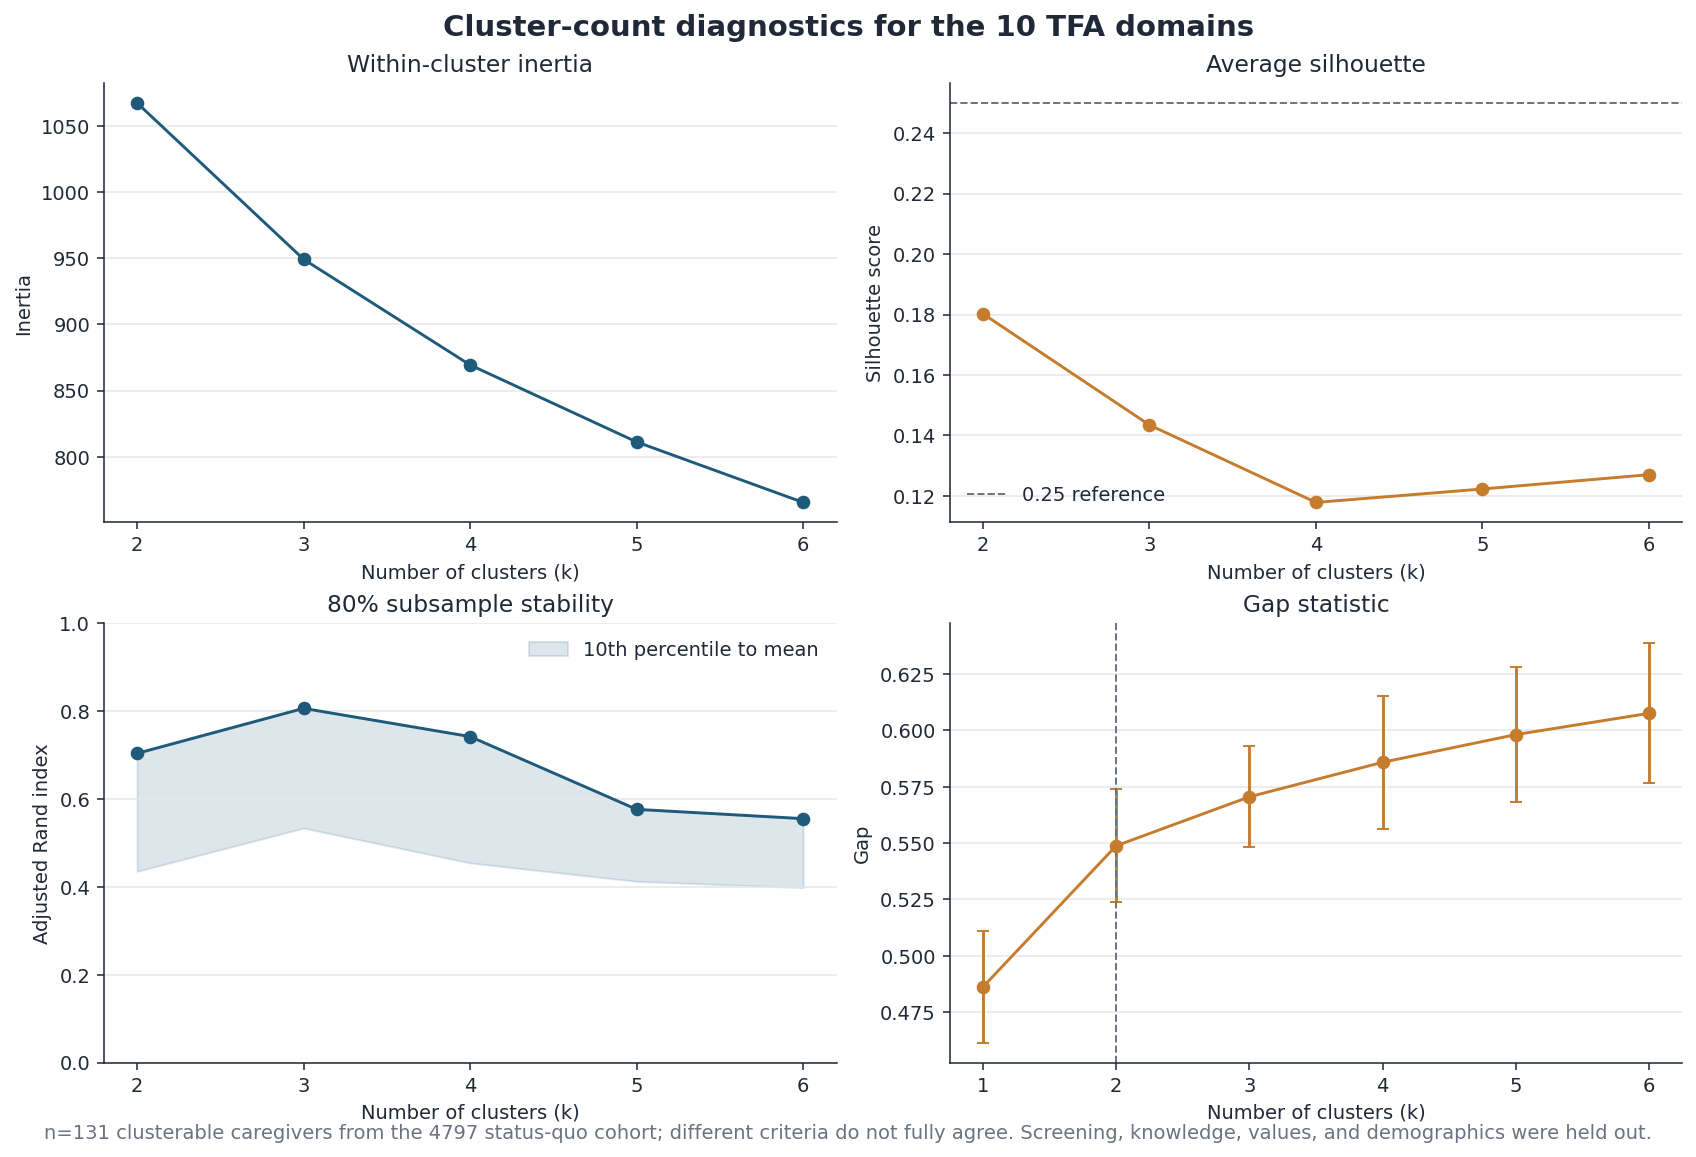

**Selection:** K=2 is retained because it has the strongest separation metrics and adequate cluster sizes. The gap statistic favors K=2, so K=2 is a parsimonious exploratory view rather than a definitive taxonomy.

In [6]:
candidate_models = {}
diagnostics_rows = []
stability_rng = np.random.default_rng(SEED)

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=100)
    labels = model.fit_predict(X_cluster)
    candidate_models[k] = model

    stability_scores = []
    sample_size = int(np.floor(0.80 * len(X_cluster)))
    for repeat in range(N_STABILITY_REPEATS):
        sampled_index = np.sort(
            stability_rng.choice(len(X_cluster), size=sample_size, replace=False)
        )
        sampled_labels = KMeans(
            n_clusters=k,
            random_state=SEED + repeat + 1,
            n_init=20,
        ).fit_predict(X_cluster[sampled_index])
        stability_scores.append(
            adjusted_rand_score(labels[sampled_index], sampled_labels)
        )

    sizes = np.bincount(labels, minlength=k)
    diagnostics_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
        "calinski_harabasz": calinski_harabasz_score(X_cluster, labels),
        "davies_bouldin": davies_bouldin_score(X_cluster, labels),
        "mean_subsample_ARI": np.mean(stability_scores),
        "p10_subsample_ARI": np.quantile(stability_scores, 0.10),
        "smallest_cluster_n": sizes.min(),
        "smallest_cluster_pct": sizes.min() / len(labels) * 100,
    })
diagnostics_df = pd.DataFrame(diagnostics_rows)

# Gap statistic includes k=1 so the analysis does not assume clusters must exist.
gap_rng = np.random.default_rng(SEED)
feature_min = X_cluster.min(axis=0)
feature_max = X_cluster.max(axis=0)
gap_rows = []
for k in range(1, 7):
    observed_inertia = KMeans(
        n_clusters=k, random_state=SEED, n_init=100
    ).fit(X_cluster).inertia_
    reference_log_inertia = []
    for repeat in range(N_GAP_REFERENCES):
        reference = gap_rng.uniform(
            feature_min, feature_max, size=X_cluster.shape
        )
        ref_inertia = KMeans(
            n_clusters=k,
            random_state=SEED + repeat + 1000,
            n_init=20,
        ).fit(reference).inertia_
        reference_log_inertia.append(np.log(ref_inertia))
    gap_rows.append({
        "k": k,
        "gap": np.mean(reference_log_inertia) - np.log(observed_inertia),
        "gap_se": np.std(reference_log_inertia, ddof=1)
        * np.sqrt(1 + 1 / N_GAP_REFERENCES),
    })
gap_df = pd.DataFrame(gap_rows)
gap_candidates = []
for index in range(len(gap_df) - 1):
    current = gap_df.iloc[index]
    following = gap_df.iloc[index + 1]
    if current["gap"] >= following["gap"] - following["gap_se"]:
        gap_candidates.append(int(current["k"]))
gap_1se_k = min(gap_candidates) if gap_candidates else int(gap_df.loc[gap_df["gap"].idxmax(), "k"])

SELECTED_K = 2
best_rows = pd.DataFrame({
    "criterion": [
        "Highest silhouette",
        "Highest Calinski–Harabasz",
        "Lowest Davies–Bouldin",
        "Highest mean subsample stability",
        "Gap statistic 1-SE choice",
    ],
    "preferred_k": [
        int(diagnostics_df.loc[diagnostics_df["silhouette"].idxmax(), "k"]),
        int(diagnostics_df.loc[diagnostics_df["calinski_harabasz"].idxmax(), "k"]),
        int(diagnostics_df.loc[diagnostics_df["davies_bouldin"].idxmin(), "k"]),
        int(diagnostics_df.loc[diagnostics_df["mean_subsample_ARI"].idxmax(), "k"]),
        gap_1se_k,
    ],
})
display(diagnostics_df.round(3))
display(best_rows)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes[0, 0].plot(diagnostics_df["k"], diagnostics_df["inertia"], marker="o", color=COLORS["Higher acceptability"])
axes[0, 0].set(title="Within-cluster inertia", xlabel="Number of clusters (k)", ylabel="Inertia")
axes[0, 1].plot(diagnostics_df["k"], diagnostics_df["silhouette"], marker="o", color=COLORS["Conditional acceptability"])
axes[0, 1].axhline(0.25, color=COLORS["neutral"], linestyle="--", linewidth=1, label="0.25 reference")
axes[0, 1].set(title="Average silhouette", xlabel="Number of clusters (k)", ylabel="Silhouette score")
axes[0, 1].legend(frameon=False)
axes[1, 0].plot(diagnostics_df["k"], diagnostics_df["mean_subsample_ARI"], marker="o", color=COLORS["Higher acceptability"])
axes[1, 0].fill_between(
    diagnostics_df["k"],
    diagnostics_df["p10_subsample_ARI"],
    diagnostics_df["mean_subsample_ARI"],
    color=COLORS["Higher acceptability"],
    alpha=0.15,
    label="10th percentile to mean",
)
axes[1, 0].set(title="80% subsample stability", xlabel="Number of clusters (k)", ylabel="Adjusted Rand index", ylim=(0, 1))
axes[1, 0].legend(frameon=False)
axes[1, 1].errorbar(
    gap_df["k"], gap_df["gap"], yerr=gap_df["gap_se"],
    marker="o", color=COLORS["Conditional acceptability"], capsize=3,
)
axes[1, 1].axvline(gap_1se_k, color=COLORS["neutral"], linestyle="--", linewidth=1)
axes[1, 1].set(title="Gap statistic", xlabel="Number of clusters (k)", ylabel="Gap")
for axis in axes.flat:
    axis.set_xticks(range(1, 7) if axis is axes[1, 1] else range(2, 7))
    axis.grid(axis="y", color=COLORS["grid"], linewidth=0.8)
fig.suptitle("Cluster-count diagnostics for the 10 TFA domains", fontsize=15, fontweight="bold")
fig.text(0.5, -0.01, "n=131 clusterable caregivers from the 4797 status-quo cohort; different criteria do not fully agree. Screening, knowledge, values, and demographics were held out.", ha="center", color=COLORS["neutral"])
for suffix in ("png", "pdf"):
    fig.savefig(OUTPUT_DIR / f"figure_1_cluster_count_diagnostics.{suffix}", bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Selection:** K=2 is retained because it has the strongest separation metrics and adequate cluster sizes. "
    f"The gap statistic favors K={gap_1se_k}, so K=2 is a parsimonious exploratory view rather than a definitive taxonomy."
))

### 7. Fit, name, and inspect the primary two-profile solution

,cluster,n,mean_input_acceptability,mean_silhouette,negative_silhouette_n,pct,negative_silhouette_pct
0,Higher acceptability,84,78.7,0.2,0,64.1,0.0
1,Conditional acceptability,47,59.2,0.1,12,35.9,25.5


cluster,cluster_domain,Higher acceptability,Conditional acceptability,higher_n_observed,conditional_n_observed,difference_points
0,Positive affect / clinical trust,73.6,47.7,82,47,25.9
1,Blood-test openness,70.7,44.9,79,46,25.7
2,Ethical / moral support,87.7,62.3,84,47,25.3
3,Low distress,82.9,60.1,82,47,22.8
4,Perceived screening utility,83.7,64.5,84,47,19.2
5,Accuracy tolerance,44.6,26.6,84,47,18.0
6,Equipment-intensive openness,47.4,29.9,84,46,17.5
7,Feasibility across pathways,73.1,55.8,84,47,17.3
8,Low-burden modality openness,91.1,74.5,83,46,16.6
9,Low aversive affect,97.6,93.4,83,47,4.2


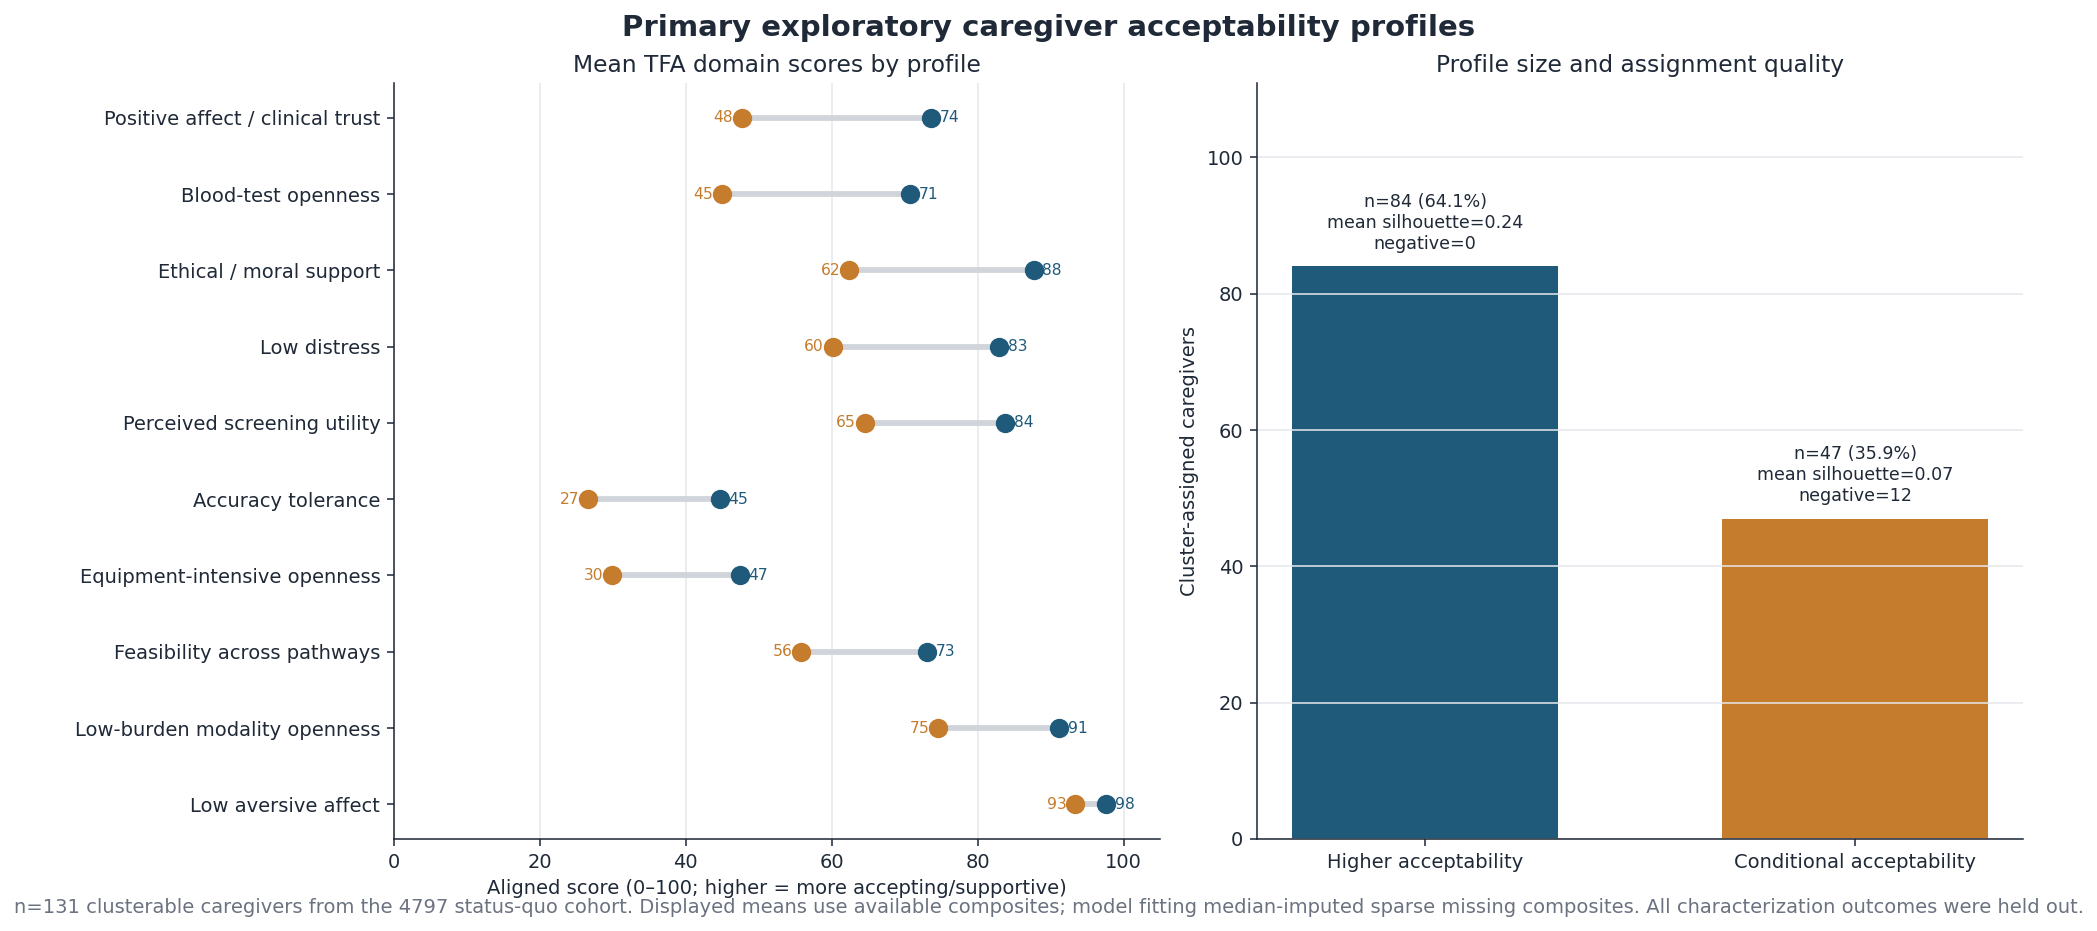

In [7]:
primary_model = candidate_models[SELECTED_K]
raw_cluster = primary_model.labels_
case_silhouette = silhouette_samples(X_cluster, raw_cluster)

# Naming uses only aligned acceptability/feasibility inputs, excluding accuracy tolerance.
input_acceptability_by_raw_cluster = (
    cluster_model_df.drop(columns=["Accuracy tolerance"])
    .assign(raw_cluster=raw_cluster)
    .groupby("raw_cluster")
    .mean()
    .mean(axis=1)
)
higher_acceptability_raw = int(input_acceptability_by_raw_cluster.idxmax())
cluster_labels = np.where(
    raw_cluster == higher_acceptability_raw,
    "Higher acceptability",
    "Conditional acceptability",
)
cluster_assignment = pd.Series(pd.NA, index=analysis_df.index, dtype="string")
cluster_assignment.loc[cluster_eligible_mask] = cluster_labels
analysis_df["cluster"] = pd.Categorical(
    cluster_assignment, categories=CLUSTER_ORDER, ordered=True
)
analysis_df["case_silhouette"] = np.nan
analysis_df.loc[cluster_eligible_mask, "case_silhouette"] = case_silhouette
analysis_df["overall_input_acceptability"] = np.nan
analysis_df.loc[cluster_eligible_mask, "overall_input_acceptability"] = (
    cluster_model_df.drop(columns=["Accuracy tolerance"]).mean(axis=1)
)

cluster_size_df = (
    analysis_df.groupby("cluster", observed=True)
    .agg(
        n=("record_id", "size"),
        mean_input_acceptability=("overall_input_acceptability", "mean"),
        mean_silhouette=("case_silhouette", "mean"),
        negative_silhouette_n=("case_silhouette", lambda s: int((s < 0).sum())),
    )
    .reindex(CLUSTER_ORDER)
    .reset_index()
)
cluster_size_df["pct"] = cluster_size_df["n"] / cluster_eligible_mask.sum() * 100
cluster_size_df["negative_silhouette_pct"] = (
    cluster_size_df["negative_silhouette_n"] / cluster_size_df["n"] * 100
)
display(cluster_size_df.round(1))

cluster_profile_df = (
    cluster_model_df.assign(cluster=cluster_labels)
    .groupby("cluster", observed=True)
    .mean()
    .reindex(CLUSTER_ORDER)
)
cluster_profile_n_df = (
    cluster_model_df.assign(cluster=cluster_labels)
    .groupby("cluster", observed=True)
    .count()
    .reindex(CLUSTER_ORDER)
)
profile_difference = (
    cluster_profile_df.loc["Higher acceptability"]
    - cluster_profile_df.loc["Conditional acceptability"]
).sort_values()
profile_table = (
    cluster_profile_df.T
    .assign(
        higher_n_observed=cluster_profile_n_df.loc["Higher acceptability"],
        conditional_n_observed=cluster_profile_n_df.loc["Conditional acceptability"],
        difference_points=profile_difference,
    )
    .sort_values("difference_points", ascending=False)
    .reset_index(names="cluster_domain")
)
display(profile_table.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.4), constrained_layout=True)
ordered_domains = profile_table["cluster_domain"].tolist()[::-1]
y = np.arange(len(ordered_domains))
higher = cluster_profile_df.loc["Higher acceptability", ordered_domains].to_numpy()
conditional = cluster_profile_df.loc["Conditional acceptability", ordered_domains].to_numpy()
axes[0].hlines(y, conditional, higher, color=COLORS["light_neutral"], linewidth=3)
axes[0].scatter(higher, y, s=80, color=COLORS["Higher acceptability"], label="Higher acceptability", zorder=3)
axes[0].scatter(conditional, y, s=80, color=COLORS["Conditional acceptability"], label="Conditional acceptability", zorder=3)
for x_value, y_value in zip(higher, y):
    axes[0].text(x_value + 1.2, y_value, f"{x_value:.0f}", va="center", fontsize=8, color=COLORS["Higher acceptability"])
for x_value, y_value in zip(conditional, y):
    axes[0].text(x_value - 1.2, y_value, f"{x_value:.0f}", va="center", ha="right", fontsize=8, color=COLORS["Conditional acceptability"])
axes[0].set(
    title="Mean TFA domain scores by profile",
    xlabel="Aligned score (0–100; higher = more accepting/supportive)",
    yticks=y,
    yticklabels=ordered_domains,
    xlim=(0, 105),
)
axes[0].grid(axis="x", color=COLORS["grid"], linewidth=0.8)

size_plot = cluster_size_df.set_index("cluster").reindex(CLUSTER_ORDER)
bars = axes[1].bar(
    CLUSTER_ORDER,
    size_plot["n"],
    color=[COLORS[name] for name in CLUSTER_ORDER],
    width=0.62,
)
for bar, cluster_name in zip(bars, CLUSTER_ORDER):
    row = size_plot.loc[cluster_name]
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'n={int(row["n"])} ({row["pct"]:.1f}%)\nmean silhouette={row["mean_silhouette"]:.2f}\nnegative={int(row["negative_silhouette_n"])}',
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[1].set(
    title="Profile size and assignment quality",
    ylabel="Cluster-assigned caregivers",
    ylim=(0, size_plot["n"].max() * 1.32),
)
axes[1].grid(axis="y", color=COLORS["grid"], linewidth=0.8)

fig.suptitle("Primary exploratory caregiver acceptability profiles", fontsize=15, fontweight="bold")
fig.text(0.5, -0.01, "n=131 clusterable caregivers from the 4797 status-quo cohort. Displayed means use available composites; model fitting median-imputed sparse missing composites. All characterization outcomes were held out.", ha="center", color=COLORS["neutral"])
for suffix in ("png", "pdf"):
    fig.savefig(OUTPUT_DIR / f"figure_2_primary_cluster_profiles.{suffix}", bbox_inches="tight")
plt.show()

## Held-out characterization outcomes

The following four sections answer the attached brief directly. Each measure uses its own valid denominator, and no held-out field influenced the clustering solution.

### 8. Screen vs Not: documented primary outcome

,stage,n,note
0,Selected analytic cohort,135,Cohort supplied in cleaned_autism_study_data.csv
1,Cluster-assigned (≥8/10 input domains),131,Primary clustering cohort
2,Cluster-assigned with valid screening outcome,127,Primary held-out screening comparison
3,Excluded from clustering but screening-valid,4,0 answered Definitely yes


,cluster,cluster_total_n,valid_n,missing_n,no_probably_not_unsure_n,no_probably_not_unsure_pct,probably_n,probably_pct,definitely_yes_n,definitely_yes_pct,wilson_low_pct,wilson_high_pct,probably_or_definitely_yes_n,probably_or_definitely_yes_pct
0,Higher acceptability,84,80,4,8,10.0,16,20.0,56,70.0,59.2,78.9,72,90.0
1,Conditional acceptability,47,47,0,19,40.4,15,31.9,13,27.7,16.9,41.8,28,59.6


,comparison,estimate
0,Strict outcome rate difference,42.3 percentage points
1,Strict outcome odds ratio,6.10
2,Fisher exact p-value,6.618e-06


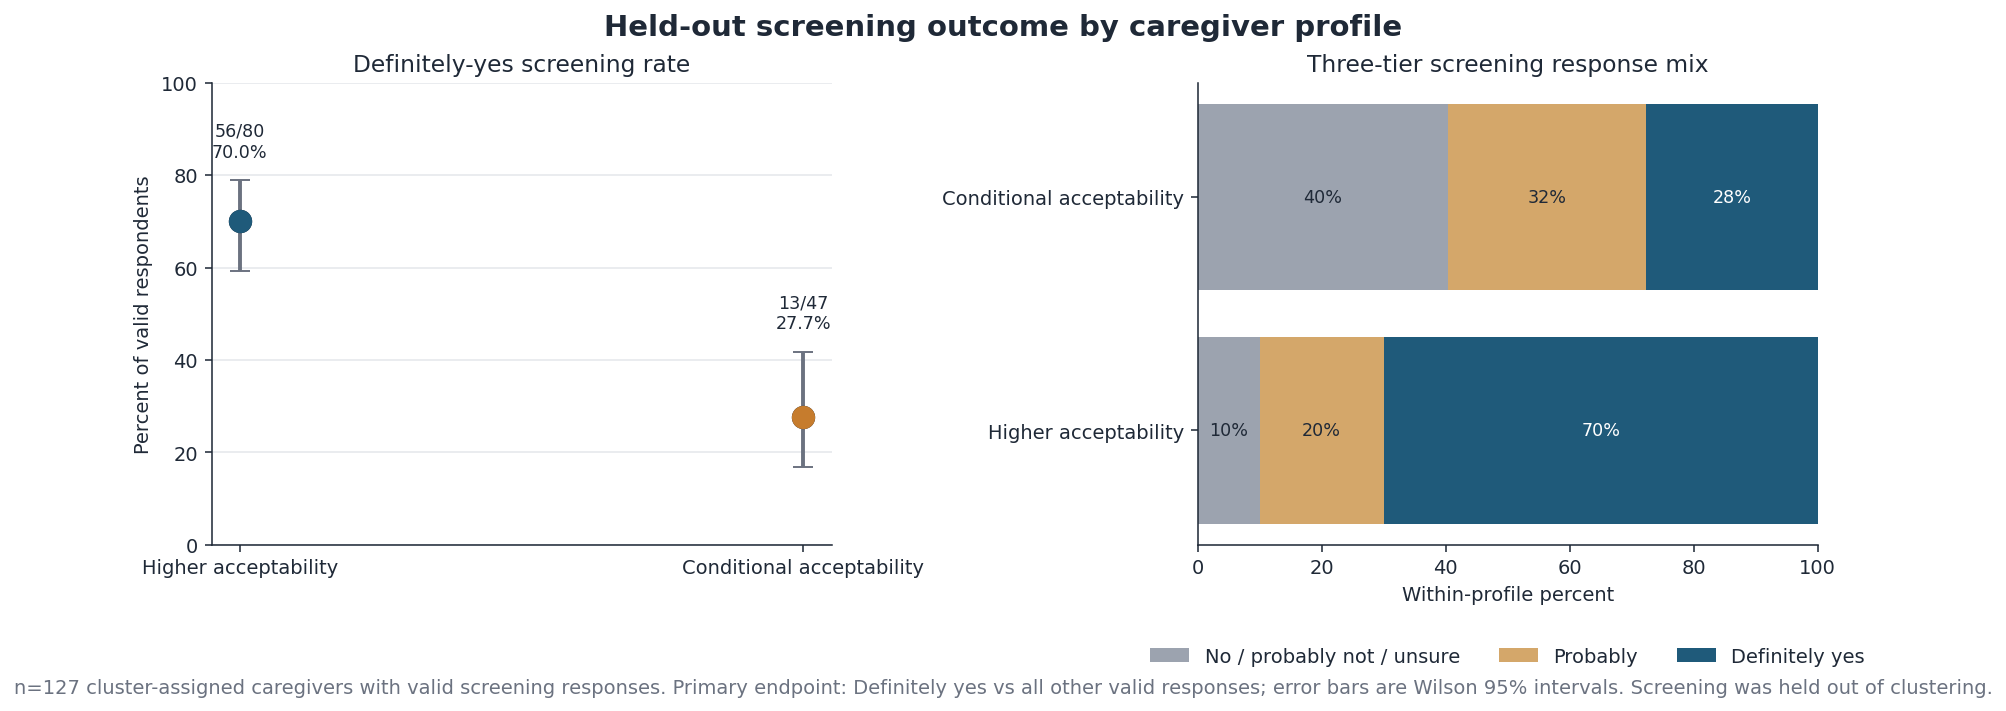

In [8]:
SCREEN_LABELS = {
    0: "Definitely no",
    1: "Probably not",
    2: "Unsure",
    3: "Probably",
    4: "Definitely yes",
}

analysis_df["screen_response"] = analysis_df["tfa_free_screen"].map(SCREEN_LABELS)
analysis_df["screen_definitely_yes"] = pd.Series(pd.NA, index=analysis_df.index, dtype="boolean")
screen_valid_mask = analysis_df["tfa_free_screen"].notna()
analysis_df.loc[screen_valid_mask, "screen_definitely_yes"] = (
    analysis_df.loc[screen_valid_mask, "tfa_free_screen"].eq(4)
).to_numpy()
analysis_df["screen_broad_yes"] = pd.Series(pd.NA, index=analysis_df.index, dtype="boolean")
analysis_df.loc[screen_valid_mask, "screen_broad_yes"] = (
    analysis_df.loc[screen_valid_mask, "tfa_free_screen"].isin([3, 4])
).to_numpy()

def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return np.nan, np.nan
    p = successes / total
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    half = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return center - half, center + half

screening_rows = []
for cluster_name in CLUSTER_ORDER:
    group = analysis_df.loc[analysis_df["cluster"].astype(str).eq(cluster_name)]
    valid = group.dropna(subset=["screen_definitely_yes"])
    strict_yes = int(valid["screen_definitely_yes"].sum())
    broad_yes = int(valid["screen_broad_yes"].sum())
    n_valid = len(valid)
    no_probably_not_unsure_n = int(valid["tfa_free_screen"].isin([0, 1, 2]).sum())
    probably_n = int(valid["tfa_free_screen"].eq(3).sum())
    ci_low, ci_high = wilson_interval(strict_yes, n_valid)
    screening_rows.append({
        "cluster": cluster_name,
        "cluster_total_n": len(group),
        "valid_n": n_valid,
        "missing_n": int(group["tfa_free_screen"].isna().sum()),
        "no_probably_not_unsure_n": no_probably_not_unsure_n,
        "no_probably_not_unsure_pct": no_probably_not_unsure_n / n_valid * 100,
        "probably_n": probably_n,
        "probably_pct": probably_n / n_valid * 100,
        "definitely_yes_n": strict_yes,
        "definitely_yes_pct": strict_yes / n_valid * 100,
        "wilson_low_pct": ci_low * 100,
        "wilson_high_pct": ci_high * 100,
        "probably_or_definitely_yes_n": broad_yes,
        "probably_or_definitely_yes_pct": broad_yes / n_valid * 100,
    })
screening_summary_df = pd.DataFrame(screening_rows)

strict_crosstab = pd.crosstab(
    analysis_df.loc[screen_valid_mask, "cluster"],
    analysis_df.loc[screen_valid_mask, "screen_definitely_yes"],
).reindex(index=CLUSTER_ORDER, columns=[True, False], fill_value=0)
fisher_result = stats.fisher_exact(strict_crosstab.to_numpy())
high_row = screening_summary_df.set_index("cluster").loc["Higher acceptability"]
conditional_row = screening_summary_df.set_index("cluster").loc["Conditional acceptability"]
screen_rate_difference_pp = (
    high_row["definitely_yes_pct"] - conditional_row["definitely_yes_pct"]
)

# Privacy-conscious three-tier distribution for visualization.
analysis_df["screen_tier"] = analysis_df["tfa_free_screen"].map({
    0: "No / probably not / unsure",
    1: "No / probably not / unsure",
    2: "No / probably not / unsure",
    3: "Probably",
    4: "Definitely yes",
})
tier_order = ["No / probably not / unsure", "Probably", "Definitely yes"]
tier_counts = (
    pd.crosstab(analysis_df["cluster"], analysis_df["screen_tier"])
    .reindex(index=CLUSTER_ORDER, columns=tier_order, fill_value=0)
)
tier_pct = tier_counts.div(tier_counts.sum(axis=1), axis=0) * 100

assigned_mask = analysis_df["cluster"].notna()
assigned_screen_valid_mask = assigned_mask & screen_valid_mask
excluded_screen_valid_mask = (~assigned_mask) & screen_valid_mask
cohort_flow_df = pd.DataFrame([
    {
        "stage": "Selected analytic cohort",
        "n": len(analysis_df),
        "note": "Cohort supplied in cleaned_autism_study_data.csv",
    },
    {
        "stage": "Cluster-assigned (≥8/10 input domains)",
        "n": int(assigned_mask.sum()),
        "note": "Primary clustering cohort",
    },
    {
        "stage": "Cluster-assigned with valid screening outcome",
        "n": int(assigned_screen_valid_mask.sum()),
        "note": "Primary held-out screening comparison",
    },
    {
        "stage": "Excluded from clustering but screening-valid",
        "n": int(excluded_screen_valid_mask.sum()),
        "note": (
            f'{int(analysis_df.loc[excluded_screen_valid_mask, "screen_definitely_yes"].sum())} '
            "answered Definitely yes"
        ),
    },
])
display(cohort_flow_df)
display(screening_summary_df.round(1))
display(pd.DataFrame({
    "comparison": ["Strict outcome rate difference", "Strict outcome odds ratio", "Fisher exact p-value"],
    "estimate": [f"{screen_rate_difference_pp:.1f} percentage points", f"{fisher_result.statistic:.2f}", f"{fisher_result.pvalue:.4g}"],
}))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
x = np.arange(len(CLUSTER_ORDER))
rates = screening_summary_df.set_index("cluster").reindex(CLUSTER_ORDER)["definitely_yes_pct"].to_numpy()
lows = screening_summary_df.set_index("cluster").reindex(CLUSTER_ORDER)["wilson_low_pct"].to_numpy()
highs = screening_summary_df.set_index("cluster").reindex(CLUSTER_ORDER)["wilson_high_pct"].to_numpy()
axes[0].errorbar(
    x, rates, yerr=[rates - lows, highs - rates],
    fmt="o", markersize=11, capsize=5, linewidth=2,
    color=COLORS["ink"], ecolor=COLORS["neutral"],
)
for index, cluster_name in enumerate(CLUSTER_ORDER):
    row = screening_summary_df.set_index("cluster").loc[cluster_name]
    axes[0].scatter(index, row["definitely_yes_pct"], s=120, color=COLORS[cluster_name], zorder=3)
    axes[0].text(index, row["wilson_high_pct"] + 5, f'{int(row["definitely_yes_n"])}/{int(row["valid_n"])}\n{row["definitely_yes_pct"]:.1f}%', ha="center", fontsize=9)
axes[0].set(
    title="Definitely-yes screening rate",
    ylabel="Percent of valid respondents",
    xticks=x,
    xticklabels=CLUSTER_ORDER,
    ylim=(0, 100),
)
axes[0].grid(axis="y", color=COLORS["grid"], linewidth=0.8)

stack_colors = ["#9CA3AF", "#D4A76A", COLORS["Higher acceptability"]]
left = np.zeros(len(CLUSTER_ORDER))
for tier, color in zip(tier_order, stack_colors):
    values = tier_pct[tier].to_numpy()
    axes[1].barh(CLUSTER_ORDER, values, left=left, color=color, label=tier)
    for idx, value in enumerate(values):
        if value >= 8:
            axes[1].text(left[idx] + value / 2, idx, f"{value:.0f}%", ha="center", va="center", fontsize=9, color="white" if tier == "Definitely yes" else COLORS["ink"])
    left += values
axes[1].set(title="Three-tier screening response mix", xlabel="Within-profile percent", xlim=(0, 100))
axes[1].legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=3)

fig.suptitle("Held-out screening outcome by caregiver profile", fontsize=15, fontweight="bold")
fig.text(0.5, -0.02, "n=127 cluster-assigned caregivers with valid screening responses. Primary endpoint: Definitely yes vs all other valid responses; error bars are Wilson 95% intervals. Screening was held out of clustering.", ha="center", color=COLORS["neutral"])
for suffix in ("png", "pdf"):
    fig.savefig(OUTPUT_DIR / f"figure_3_screening_outcome.{suffix}", bbox_inches="tight")
plt.show()

### 9. Autism Knowledge: verified score first, unresolved item as sensitivity

,measure,cluster,n,mean,sd,median,q1,q3,mean_pct_of_possible_range,mann_whitney_p
0,Verified objective knowledge,Higher acceptability,77,3.90,1.57,4.0,3.00,5.0,55.66,0.10
1,Verified objective knowledge,Conditional acceptability,46,3.41,1.72,4.0,2.00,4.0,48.76,0.10
2,8-item sensitivity: Before 1 year correct,Higher acceptability,77,4.17,1.63,5.0,3.00,5.0,52.11,0.06
3,8-item sensitivity: Before 1 year correct,Conditional acceptability,46,3.61,1.73,4.0,2.25,5.0,45.11,0.06
4,8-item sensitivity: 1–2 years correct,Higher acceptability,77,4.32,1.64,5.0,3.00,5.0,54.06,0.23
5,8-item sensitivity: 1–2 years correct,Conditional acceptability,46,3.96,1.80,4.0,3.00,5.0,49.46,0.23
6,Self-rated knowledge,Higher acceptability,84,3.49,0.88,3.0,3.00,4.0,62.20,0.75
7,Self-rated knowledge,Conditional acceptability,47,3.51,0.75,4.0,3.00,4.0,62.77,0.75


,item,variable,cluster,valid_n,correct_n,correct_pct,ci_low_pct,ci_high_pct
0,Genetics,tfa_genetics,Higher acceptability,80,24,30.0,21.1,40.8
1,Genetics,tfa_genetics,Conditional acceptability,47,10,21.3,12.0,34.9
2,Vaccines,tfa_vaccines,Higher acceptability,82,61,74.4,64.0,82.6
3,Vaccines,tfa_vaccines,Conditional acceptability,47,34,72.3,58.2,83.1
4,Tylenol,tfa_tylenol,Higher acceptability,82,64,78.0,67.9,85.6
5,Tylenol,tfa_tylenol,Conditional acceptability,47,35,74.5,60.5,84.7
6,Medication,tfa_medications,Higher acceptability,81,40,49.4,38.8,60.0
7,Medication,tfa_medications,Conditional acceptability,47,25,53.2,39.2,66.7
8,Why diagnoses increased,tfa_rate,Higher acceptability,81,55,67.9,57.1,77.1
9,Why diagnoses increased,tfa_rate,Conditional acceptability,47,26,55.3,41.2,68.6


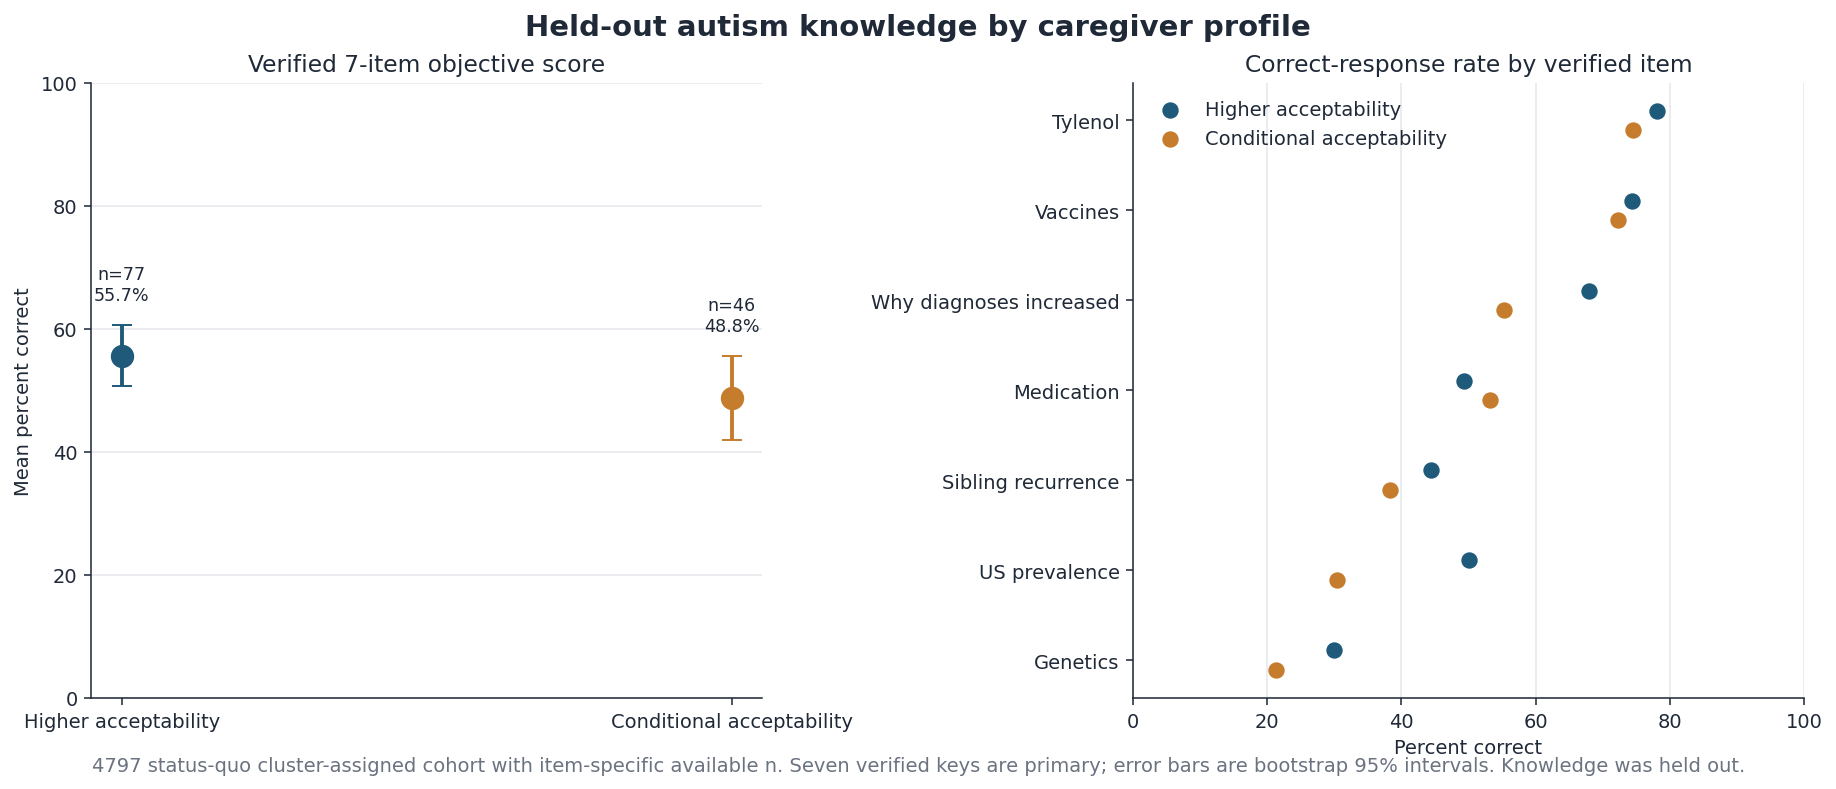

In [9]:
VERIFIED_KNOWLEDGE_KEY = {
    "tfa_genetics": 1,
    "tfa_vaccines": 4,
    "tfa_tylenol": 4,
    "tfa_medications": 1,
    "tfa_rate": 1,
    "tfa_autistic_us": 2,
    "tfa_mult_kids_odds": 3,
}
KNOWLEDGE_LABELS = {
    "tfa_genetics": "Genetics",
    "tfa_vaccines": "Vaccines",
    "tfa_tylenol": "Tylenol",
    "tfa_medications": "Medication",
    "tfa_rate": "Why diagnoses increased",
    "tfa_autistic_us": "US prevalence",
    "tfa_mult_kids_odds": "Sibling recurrence",
}

knowledge_correct = pd.DataFrame(index=analysis_df.index)
for variable, correct_code in VERIFIED_KNOWLEDGE_KEY.items():
    knowledge_correct[variable] = np.where(
        analysis_df[variable].isna(),
        np.nan,
        analysis_df[variable].eq(correct_code).astype(float),
    )

complete_verified = knowledge_correct.notna().all(axis=1)
analysis_df["knowledge_verified_7"] = (
    knowledge_correct.sum(axis=1).where(complete_verified)
)
analysis_df["self_rated_knowledge_1_5"] = 6 - analysis_df["fif_knowledge"]

def eight_item_score(behavior_correct_code):
    behavior_correct = np.where(
        analysis_df["tfa_behavior_age"].isna(),
        np.nan,
        analysis_df["tfa_behavior_age"].eq(behavior_correct_code).astype(float),
    )
    frame = knowledge_correct.assign(tfa_behavior_age=behavior_correct)
    return frame.sum(axis=1).where(frame.notna().all(axis=1))

analysis_df["knowledge_8_before_1y"] = eight_item_score(2)
analysis_df["knowledge_8_age_1_2y"] = eight_item_score(3)

def mean_ci_bootstrap(series, repeats=2000):
    values = pd.Series(series).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    local_rng = np.random.default_rng(SEED + len(values))
    means = np.empty(repeats)
    for repeat in range(repeats):
        means[repeat] = local_rng.choice(values, size=len(values), replace=True).mean()
    return values.mean(), np.quantile(means, 0.025), np.quantile(means, 0.975)

knowledge_rows = []
for score_name, display_name, minimum, maximum in [
    ("knowledge_verified_7", "Verified objective knowledge", 0, 7),
    ("knowledge_8_before_1y", "8-item sensitivity: Before 1 year correct", 0, 8),
    ("knowledge_8_age_1_2y", "8-item sensitivity: 1–2 years correct", 0, 8),
    ("self_rated_knowledge_1_5", "Self-rated knowledge", 1, 5),
]:
    groups = []
    for cluster_name in CLUSTER_ORDER:
        values = analysis_df.loc[
            analysis_df["cluster"].astype(str).eq(cluster_name), score_name
        ].dropna()
        groups.append(values)
        knowledge_rows.append({
            "measure": display_name,
            "cluster": cluster_name,
            "n": len(values),
            "mean": values.mean(),
            "sd": values.std(ddof=1),
            "median": values.median(),
            "q1": values.quantile(0.25),
            "q3": values.quantile(0.75),
            "mean_pct_of_possible_range": (
                (values.mean() - minimum) / (maximum - minimum) * 100
            ),
        })
    test = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    for row in knowledge_rows[-2:]:
        row["mann_whitney_p"] = test.pvalue
knowledge_summary_df = pd.DataFrame(knowledge_rows)
display(knowledge_summary_df.round(2))

item_rows = []
for variable in VERIFIED_KNOWLEDGE_KEY:
    for cluster_name in CLUSTER_ORDER:
        values = knowledge_correct.loc[
            analysis_df["cluster"].astype(str).eq(cluster_name), variable
        ].dropna()
        low, high = wilson_interval(int(values.sum()), len(values))
        item_rows.append({
            "item": KNOWLEDGE_LABELS[variable],
            "variable": variable,
            "cluster": cluster_name,
            "valid_n": len(values),
            "correct_n": int(values.sum()),
            "correct_pct": values.mean() * 100,
            "ci_low_pct": low * 100,
            "ci_high_pct": high * 100,
        })
knowledge_item_df = pd.DataFrame(item_rows)
display(knowledge_item_df.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), constrained_layout=True)
score_plot = []
for cluster_name in CLUSTER_ORDER:
    values = analysis_df.loc[
        analysis_df["cluster"].astype(str).eq(cluster_name), "knowledge_verified_7"
    ].dropna()
    mean_value, low, high = mean_ci_bootstrap(values / 7 * 100)
    score_plot.append((cluster_name, mean_value, low, high, len(values)))
for index, (cluster_name, mean_value, low, high, n_value) in enumerate(score_plot):
    axes[0].errorbar(
        index, mean_value, yerr=[[mean_value - low], [high - mean_value]],
        fmt="o", markersize=11, capsize=5, linewidth=2,
        color=COLORS[cluster_name],
    )
    axes[0].text(index, high + 4, f"n={n_value}\n{mean_value:.1f}%", ha="center", fontsize=9)
axes[0].set(
    title="Verified 7-item objective score",
    ylabel="Mean percent correct",
    xticks=range(len(CLUSTER_ORDER)),
    xticklabels=CLUSTER_ORDER,
    ylim=(0, 100),
)
axes[0].grid(axis="y", color=COLORS["grid"], linewidth=0.8)

item_order = (
    knowledge_item_df.groupby("item")["correct_pct"].mean().sort_values().index.tolist()
)
y = np.arange(len(item_order))
for cluster_name, offset in zip(CLUSTER_ORDER, [0.11, -0.11]):
    subset = (
        knowledge_item_df.loc[knowledge_item_df["cluster"].eq(cluster_name)]
        .set_index("item")
        .reindex(item_order)
    )
    axes[1].scatter(
        subset["correct_pct"], y + offset,
        s=55, color=COLORS[cluster_name], label=cluster_name,
    )
axes[1].set(
    title="Correct-response rate by verified item",
    xlabel="Percent correct",
    yticks=y,
    yticklabels=item_order,
    xlim=(0, 100),
)
axes[1].grid(axis="x", color=COLORS["grid"], linewidth=0.8)
axes[1].legend(frameon=False)

fig.suptitle("Held-out autism knowledge by caregiver profile", fontsize=15, fontweight="bold")
fig.text(0.5, -0.01, "4797 status-quo cluster-assigned cohort with item-specific available n. Seven verified keys are primary; error bars are bootstrap 95% intervals. Knowledge was held out.", ha="center", color=COLORS["neutral"])
for suffix in ("png", "pdf"):
    fig.savefig(OUTPUT_DIR / f"figure_4_autism_knowledge.{suffix}", bbox_inches="tight")
plt.show()

### 10. Values: all ten scores shown separately

,value,higher_n,higher_mean,higher_sd,conditional_n,conditional_mean,conditional_sd,cohens_d,mann_whitney_p,fdr_p
0,Self-direction,84,5.321,0.838,47,4.872,1.076,0.483,0.013,0.129
1,Stimulation,84,3.607,1.261,47,3.170,1.185,0.354,0.059,0.293
2,Hedonism,84,4.262,1.173,47,3.915,1.332,0.282,0.131,0.437
3,Universalism,84,5.405,0.778,47,5.149,1.251,0.263,0.625,0.932
4,Power,84,3.310,1.423,47,3.043,1.398,0.189,0.324,0.810
5,Benevolence,84,5.536,0.630,47,5.404,0.948,0.173,0.925,0.932
6,Security,84,4.607,1.130,47,4.468,1.300,0.117,0.697,0.932
7,Conformity,84,4.798,1.170,47,4.851,1.142,-0.046,0.818,0.932
8,Tradition,84,3.643,1.912,47,3.681,1.771,-0.020,0.930,0.932
9,Achievement,84,3.869,1.438,47,3.894,1.463,-0.017,0.932,0.932


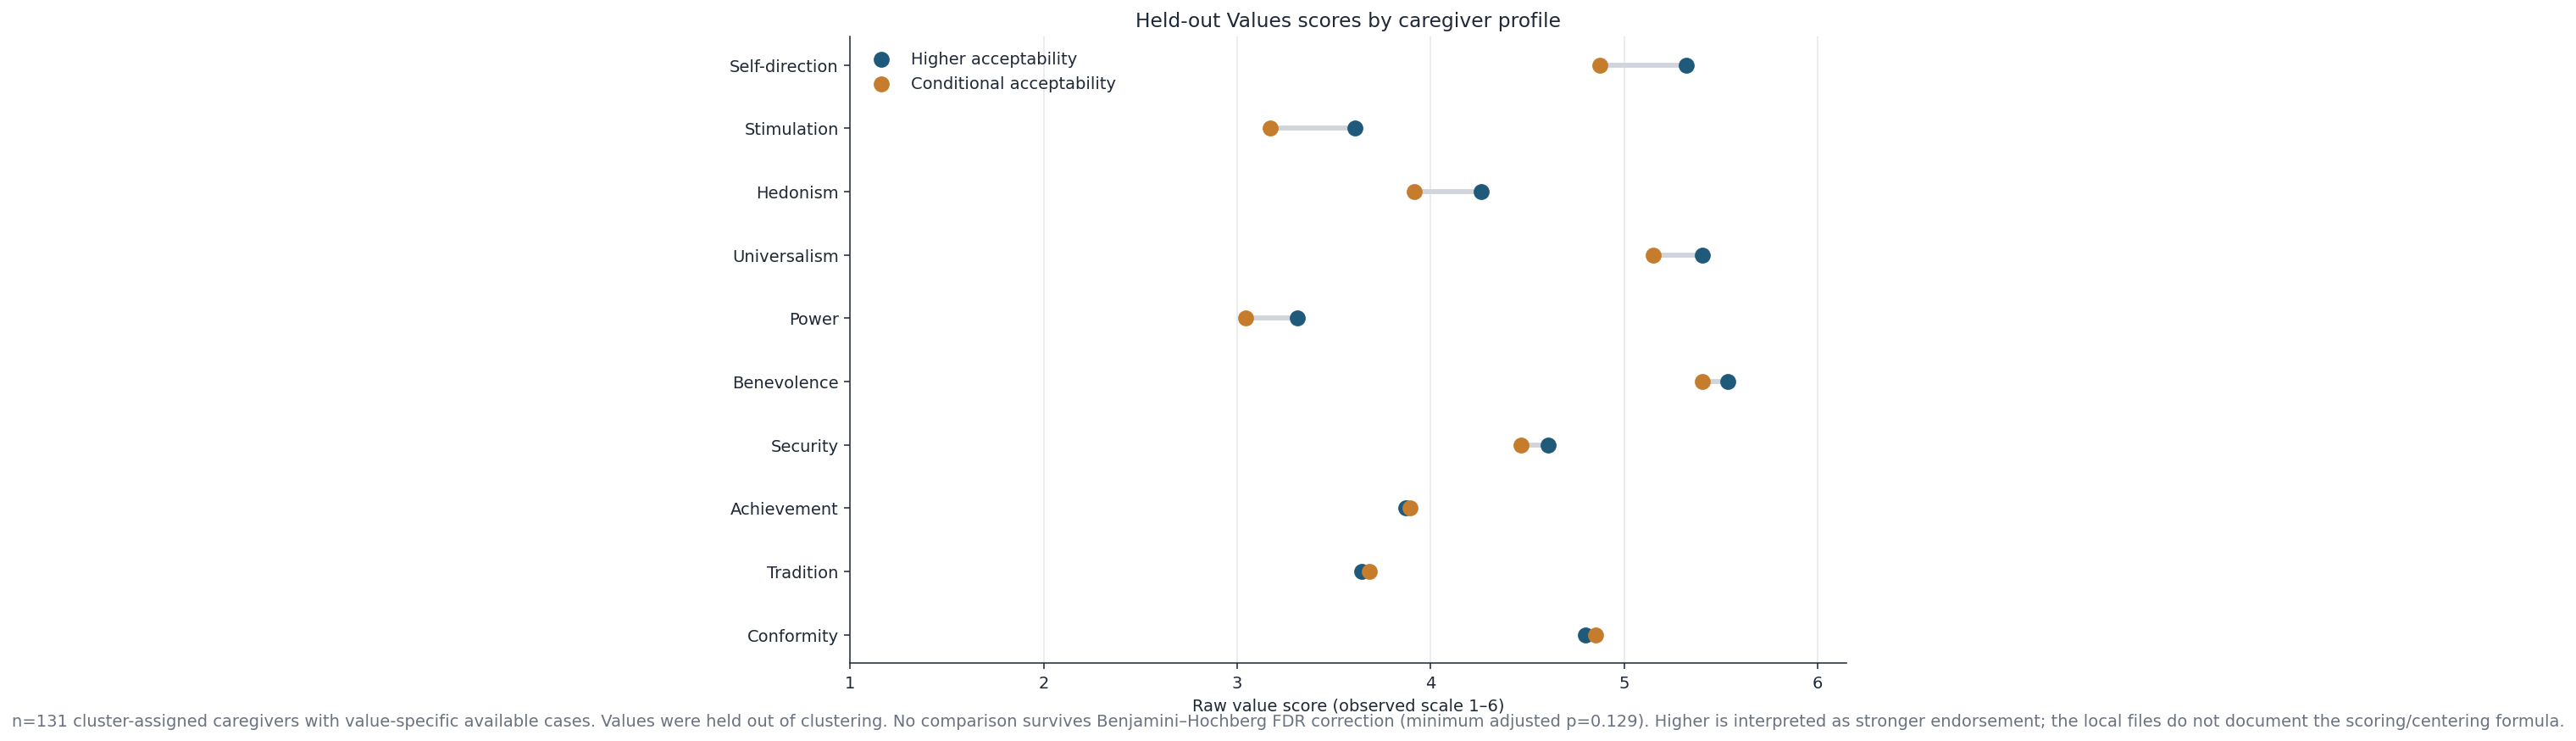

In [10]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = ranked * len(p) / np.arange(1, len(p) + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted

def pooled_standardized_difference(high_values, conditional_values):
    high_values = pd.Series(high_values).dropna().astype(float)
    conditional_values = pd.Series(conditional_values).dropna().astype(float)
    pooled_sd = np.sqrt(
        ((len(high_values) - 1) * high_values.var(ddof=1)
        + (len(conditional_values) - 1) * conditional_values.var(ddof=1))
        / (len(high_values) + len(conditional_values) - 2)
    )
    return (high_values.mean() - conditional_values.mean()) / pooled_sd

value_display_names = {
    "conformity_val": "Conformity",
    "tradition_val": "Tradition",
    "benevolence_val": "Benevolence",
    "universalism_val": "Universalism",
    "self_direction_val": "Self-direction",
    "stimulation_val": "Stimulation",
    "hedonism_val": "Hedonism",
    "achievement_val": "Achievement",
    "power_val": "Power",
    "security_val": "Security",
}
value_rows = []
value_p_values = []
for variable in value_vars:
    high_values = analysis_df.loc[
        analysis_df["cluster"].astype(str).eq("Higher acceptability"), variable
    ].dropna()
    conditional_values = analysis_df.loc[
        analysis_df["cluster"].astype(str).eq("Conditional acceptability"), variable
    ].dropna()
    p_value = stats.mannwhitneyu(
        high_values, conditional_values, alternative="two-sided"
    ).pvalue
    value_p_values.append(p_value)
    value_rows.append({
        "value": value_display_names[variable],
        "higher_n": len(high_values),
        "higher_mean": high_values.mean(),
        "higher_sd": high_values.std(ddof=1),
        "conditional_n": len(conditional_values),
        "conditional_mean": conditional_values.mean(),
        "conditional_sd": conditional_values.std(ddof=1),
        "cohens_d": pooled_standardized_difference(
            high_values, conditional_values
        ),
        "mann_whitney_p": p_value,
    })
values_summary_df = pd.DataFrame(value_rows)
values_summary_df["fdr_p"] = benjamini_hochberg(value_p_values)
values_summary_df = values_summary_df.sort_values(
    "cohens_d", key=np.abs, ascending=False
).reset_index(drop=True)
display(values_summary_df.round(3))

fig, ax = plt.subplots(figsize=(9.5, 6), constrained_layout=True)
chart_df = values_summary_df.sort_values("cohens_d")
y = np.arange(len(chart_df))
ax.hlines(
    y, chart_df["conditional_mean"], chart_df["higher_mean"],
    color=COLORS["light_neutral"], linewidth=3,
)
ax.scatter(
    chart_df["higher_mean"], y, s=75,
    color=COLORS["Higher acceptability"], label="Higher acceptability", zorder=3,
)
ax.scatter(
    chart_df["conditional_mean"], y, s=75,
    color=COLORS["Conditional acceptability"], label="Conditional acceptability", zorder=3,
)
ax.set(
    title="Held-out Values scores by caregiver profile",
    xlabel="Raw value score (observed scale 1–6)",
    yticks=y,
    yticklabels=chart_df["value"],
    xlim=(1, 6.15),
)
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8)
ax.legend(frameon=False)
fig.text(0.5, -0.01, f"n=131 cluster-assigned caregivers with value-specific available cases. Values were held out of clustering. No comparison survives Benjamini–Hochberg FDR correction (minimum adjusted p={values_summary_df['fdr_p'].min():.3f}). Higher is interpreted as stronger endorsement; the local files do not document the scoring/centering formula.", ha="center", color=COLORS["neutral"])
for suffix in ("png", "pdf"):
    fig.savefig(OUTPUT_DIR / f"figure_5_values_characterization.{suffix}", bbox_inches="tight")
plt.show()

### 11. Demographics and family context: aggregate, privacy-conscious profile

,measure,type,effect_type,higher,conditional,effect,raw_p,disclosure_safe,fdr_p
0,Caregiver age at 2025-09-29,continuous,Cohen's d,"38.0 [33.0, 42.0] (n=79)","36.0 [33.0, 40.0] (n=43)",0.190,0.247,NaN,0.781
1,Household size,continuous,Cohen's d,"4.0 [3.0, 5.0] (n=79)","4.0 [3.2, 4.8] (n=46)",0.086,0.560,NaN,0.781
2,Number of children,continuous,Cohen's d,"2.0 [2.0, 3.0] (n=84)","2.0 [2.0, 3.0] (n=47)",-0.025,0.946,NaN,0.946
3,Bachelor's degree or higher,binary,Cohen's h,54/80 (68%),34/47 (72%),-0.106,0.568,True,0.781
4,Currently employed,binary,Cohen's h,53/80 (66%),30/47 (64%),0.051,0.782,True,0.860
5,Rural area,binary,Cohen's h,18/80 (22%),8/47 (17%),0.138,0.504,True,0.781
6,Very easy healthcare access,binary,Cohen's h,60/80 (75%),32/46 (70%),0.122,0.508,True,0.781
7,Household with ≥1 autistic child,binary,Cohen's h,35/84 (42%),24/47 (51%),-0.189,0.300,True,0.781
8,Works with autistic people,binary,Cohen's h,28/84 (33%),17/47 (36%),-0.060,0.743,True,0.860
9,Any child with special needs/disabilities,binary,Cohen's h,39/84 (46%),25/47 (53%),-0.135,0.458,True,0.781


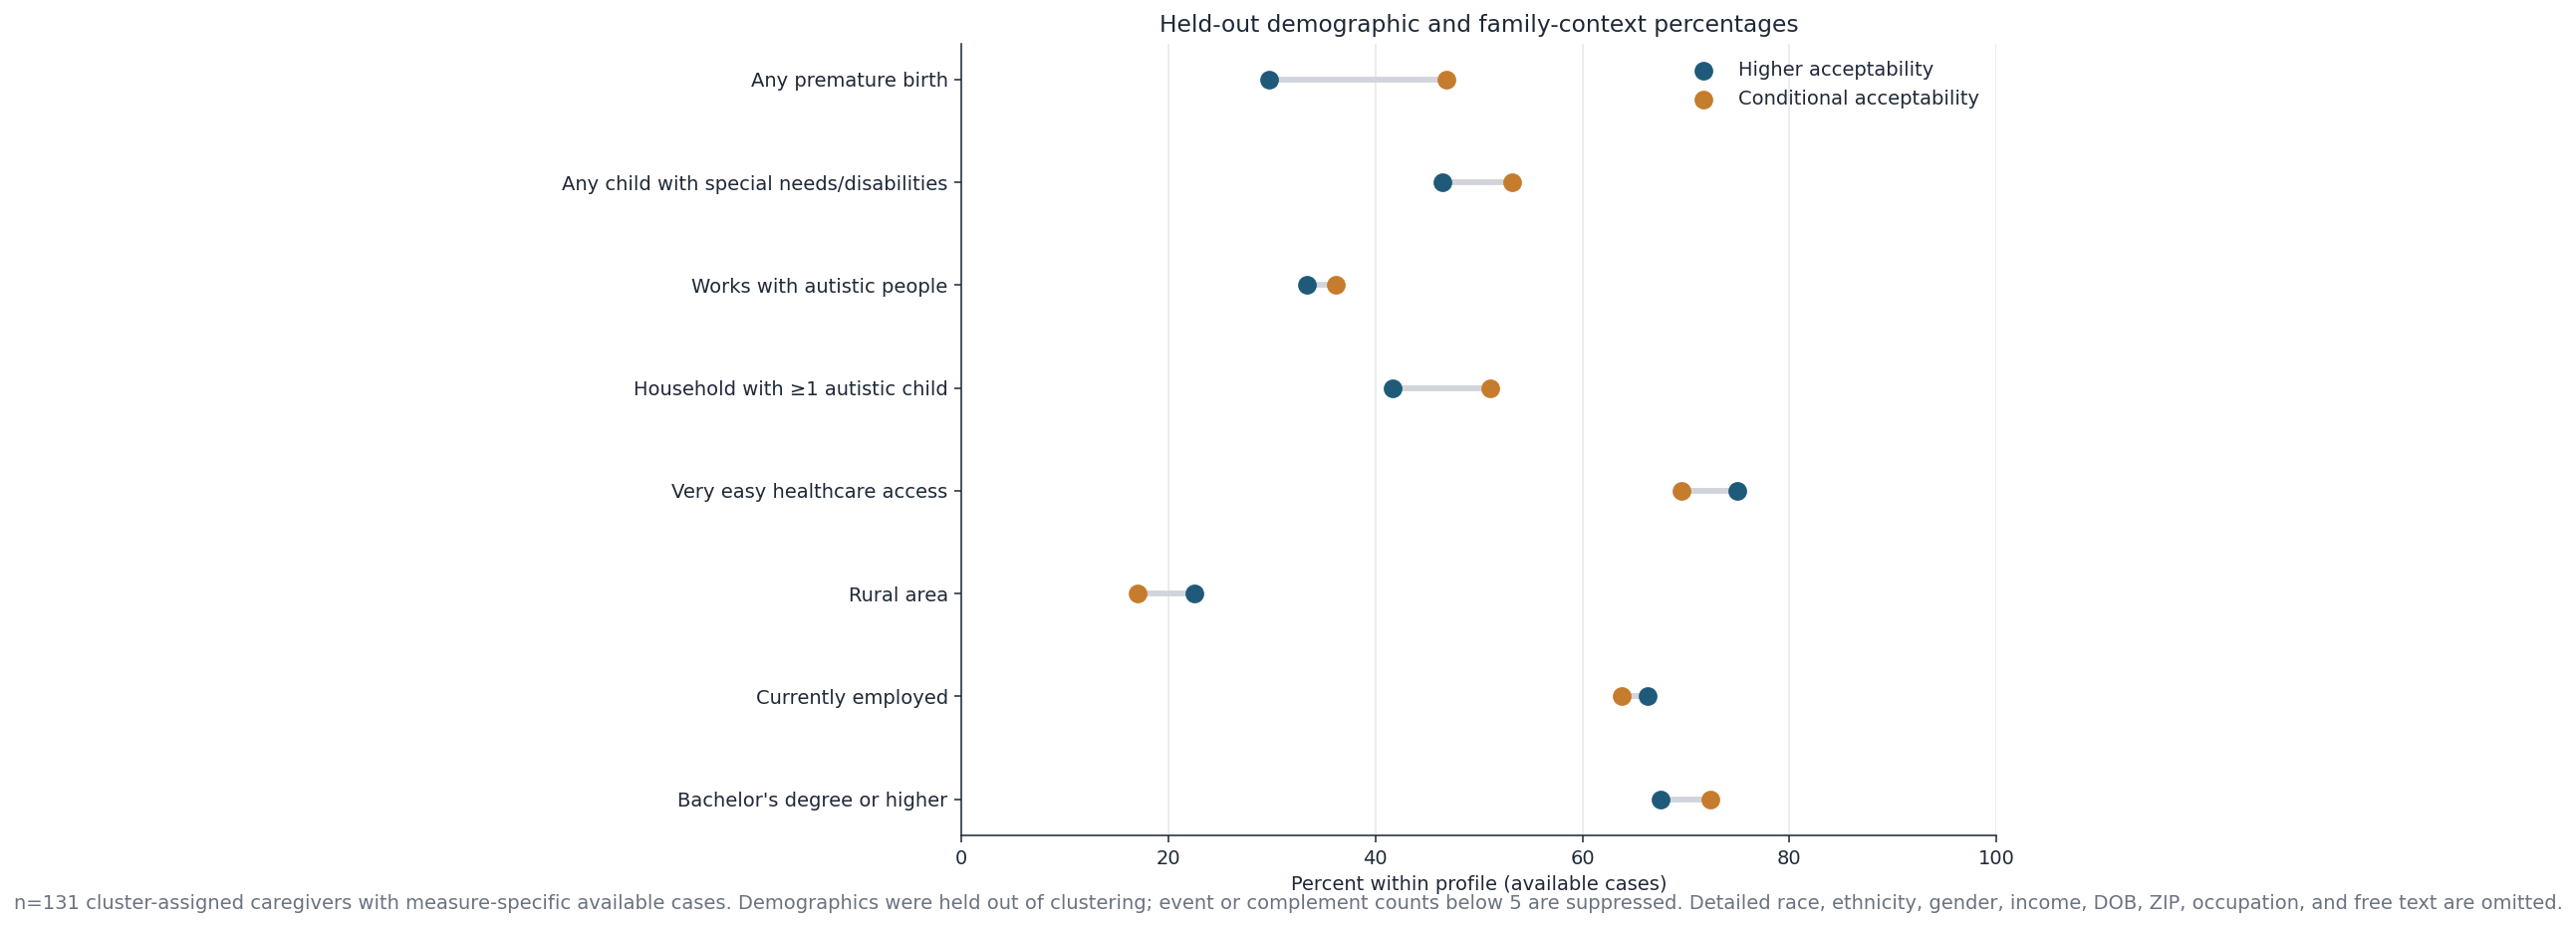

In [11]:
demographics = pd.DataFrame(index=analysis_df.index)
demographics["Caregiver age at 2025-09-29"] = analysis_df["age_check_demo"].where(
    analysis_df["age_check_demo"].between(18, 100)
)
demographics["Household size"] = analysis_df["demo_num_home"].where(
    analysis_df["demo_num_home"].between(1, 20)
)
demographics["Number of children"] = analysis_df["fif_num_children"].where(
    analysis_df["fif_num_children"].between(0, 20)
)
demographics["Bachelor's degree or higher"] = (
    analysis_df["demo_cg1education"].ge(7)
    .where(analysis_df["demo_cg1education"].notna())
    .astype("boolean")
)
demographics["Currently employed"] = (
    analysis_df["demo_cg1employment"].eq(1)
    .where(analysis_df["demo_cg1employment"].notna())
    .astype("boolean")
)
demographics["Rural area"] = (
    analysis_df["demo_area"].eq(1)
    .where(analysis_df["demo_area"].notna())
    .astype("boolean")
)
demographics["Very easy healthcare access"] = (
    analysis_df["demo_hcare_access"].eq(1)
    .where(analysis_df["demo_hcare_access"].notna())
    .astype("boolean")
)
demographics["Household with ≥1 autistic child"] = (
    analysis_df["fif_num_autistic"].gt(0)
    .where(analysis_df["fif_num_autistic"].notna())
    .astype("boolean")
)
demographics["Works with autistic people"] = (
    analysis_df["fif_work_autistic"].eq(1)
    .where(analysis_df["fif_work_autistic"].notna())
    .astype("boolean")
)
demographics["Any child with special needs/disabilities"] = (
    analysis_df["fif_child_needs"].eq(1)
    .where(analysis_df["fif_child_needs"].notna())
    .astype("boolean")
)
demographics["Any premature birth"] = (
    analysis_df["fif_premature"].isin([1, 2])
    .where(analysis_df["fif_premature"].notna())
    .astype("boolean")
)

continuous_demographics = [
    "Caregiver age at 2025-09-29", "Household size", "Number of children"
]
binary_demographics = [
    column for column in demographics.columns
    if column not in continuous_demographics
]

demographic_rows = []
for measure in continuous_demographics:
    groups = {}
    for cluster_name in CLUSTER_ORDER:
        groups[cluster_name] = demographics.loc[
            analysis_df["cluster"].astype(str).eq(cluster_name), measure
        ].dropna().astype(float)
    test = stats.mannwhitneyu(
        groups["Higher acceptability"],
        groups["Conditional acceptability"],
        alternative="two-sided",
    )
    demographic_rows.append({
        "measure": measure,
        "type": "continuous",
        "effect_type": "Cohen's d",
        "higher": f'{groups["Higher acceptability"].median():.1f} [{groups["Higher acceptability"].quantile(.25):.1f}, {groups["Higher acceptability"].quantile(.75):.1f}] (n={len(groups["Higher acceptability"])})',
        "conditional": f'{groups["Conditional acceptability"].median():.1f} [{groups["Conditional acceptability"].quantile(.25):.1f}, {groups["Conditional acceptability"].quantile(.75):.1f}] (n={len(groups["Conditional acceptability"])})',
        "effect": pooled_standardized_difference(
            groups["Higher acceptability"], groups["Conditional acceptability"]
        ),
        "raw_p": test.pvalue,
    })

def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

binary_plot_rows = []
for measure in binary_demographics:
    counts = {}
    for cluster_name in CLUSTER_ORDER:
        values = demographics.loc[
            analysis_df["cluster"].astype(str).eq(cluster_name), measure
        ].dropna().astype(bool)
        counts[cluster_name] = (int(values.sum()), len(values), values.mean())
        binary_plot_rows.append({
            "measure": measure,
            "cluster": cluster_name,
            "yes_n": int(values.sum()),
            "valid_n": len(values),
            "yes_pct": values.mean() * 100,
        })
    contingency = np.array([
        [counts["Higher acceptability"][0], counts["Higher acceptability"][1] - counts["Higher acceptability"][0]],
        [counts["Conditional acceptability"][0], counts["Conditional acceptability"][1] - counts["Conditional acceptability"][0]],
    ])
    disclosure_safe = bool((contingency >= 5).all())
    if not disclosure_safe:
        p_value = np.nan
    elif (contingency < 10).any():
        p_value = stats.fisher_exact(contingency).pvalue
    else:
        p_value = stats.chi2_contingency(contingency, correction=False).pvalue
    high_n, high_total, high_p = counts["Higher acceptability"]
    cond_n, cond_total, cond_p = counts["Conditional acceptability"]
    demographic_rows.append({
        "measure": measure,
        "type": "binary",
        "effect_type": "Cohen's h",
        "higher": f"{high_n}/{high_total} ({high_p:.0%})" if disclosure_safe else "Suppressed (<5)",
        "conditional": f"{cond_n}/{cond_total} ({cond_p:.0%})" if disclosure_safe else "Suppressed (<5)",
        "effect": cohens_h(high_p, cond_p) if disclosure_safe else np.nan,
        "raw_p": p_value,
        "disclosure_safe": disclosure_safe,
    })

demographics_summary_df = pd.DataFrame(demographic_rows)
demographics_summary_df["fdr_p"] = np.nan
testable_mask = demographics_summary_df["raw_p"].notna()
demographics_summary_df.loc[testable_mask, "fdr_p"] = benjamini_hochberg(
    demographics_summary_df.loc[testable_mask, "raw_p"]
)
display(demographics_summary_df.round({"effect": 3, "raw_p": 3, "fdr_p": 3}))

binary_plot_df = pd.DataFrame(binary_plot_rows)
requested_plot_measures = [
    "Bachelor's degree or higher",
    "Currently employed",
    "Rural area",
    "Very easy healthcare access",
    "Household with ≥1 autistic child",
    "Works with autistic people",
    "Any child with special needs/disabilities",
    "Any premature birth",
]
safe_measures = demographics_summary_df.loc[
    demographics_summary_df["disclosure_safe"].astype("boolean").fillna(False),
    "measure",
].tolist()
plotted_measures = [
    measure for measure in requested_plot_measures if measure in safe_measures
]
fig, ax = plt.subplots(figsize=(10.5, 6.4), constrained_layout=True)
y = np.arange(len(plotted_measures))
high = (
    binary_plot_df.loc[binary_plot_df["cluster"].eq("Higher acceptability")]
    .set_index("measure").reindex(plotted_measures)["yes_pct"]
)
conditional = (
    binary_plot_df.loc[binary_plot_df["cluster"].eq("Conditional acceptability")]
    .set_index("measure").reindex(plotted_measures)["yes_pct"]
)
ax.hlines(y, conditional, high, color=COLORS["light_neutral"], linewidth=3)
ax.scatter(high, y, s=75, color=COLORS["Higher acceptability"], label="Higher acceptability", zorder=3)
ax.scatter(conditional, y, s=75, color=COLORS["Conditional acceptability"], label="Conditional acceptability", zorder=3)
ax.set(
    title="Held-out demographic and family-context percentages",
    xlabel="Percent within profile (available cases)",
    yticks=y,
    yticklabels=plotted_measures,
    xlim=(0, 100),
)
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8)
ax.legend(frameon=False)
fig.text(0.5, -0.01, "n=131 cluster-assigned caregivers with measure-specific available cases. Demographics were held out of clustering; event or complement counts below 5 are suppressed. Detailed race, ethnicity, gender, income, DOB, ZIP, occupation, and free text are omitted.", ha="center", color=COLORS["neutral"])
for suffix in ("png", "pdf"):
    fig.savefig(OUTPUT_DIR / f"figure_6_demographic_characterization.{suffix}", bbox_inches="tight")
plt.show()

### 12. Integrated decision table

In [12]:
profile_lookup = cluster_profile_df
knowledge_lookup = (
    knowledge_summary_df.loc[
        knowledge_summary_df["measure"].eq("Verified objective knowledge")
    ].set_index("cluster")
)
screen_lookup = screening_summary_df.set_index("cluster")
cluster_lookup = cluster_size_df.set_index("cluster")

decision_rows = []
for cluster_name in CLUSTER_ORDER:
    defining = ", ".join(profile_table.head(3)["cluster_domain"].tolist())
    if cluster_name == "Higher acceptability":
        action = "Maintain a low-burden pathway and make enrollment/action steps immediate."
    else:
        action = "Reduce visit burden; reinforce trust, choice, accuracy transparency, and ethical safeguards."
    decision_rows.append({
        "profile": cluster_name,
        "n_pct": f'{int(cluster_lookup.loc[cluster_name, "n"])} ({cluster_lookup.loc[cluster_name, "pct"]:.1f}%)',
        "mean_TFA_acceptability_0_100": cluster_lookup.loc[cluster_name, "mean_input_acceptability"],
        "definitely_yes_screen": f'{int(screen_lookup.loc[cluster_name, "definitely_yes_n"])}/{int(screen_lookup.loc[cluster_name, "valid_n"])} ({screen_lookup.loc[cluster_name, "definitely_yes_pct"]:.1f}%)',
        "verified_knowledge_0_7": f'{knowledge_lookup.loc[cluster_name, "mean"]:.2f} (n={int(knowledge_lookup.loc[cluster_name, "n"])})',
        "defining_TFA_dimensions": defining,
        "decision_use": action,
    })
decision_table_df = pd.DataFrame(decision_rows)
display(decision_table_df.round(1))

display(Markdown(
    f'''
    **What is actionable**

    - The strict screening difference is **{screen_rate_difference_pp:.1f} percentage points**.
    - Both groups remain relatively open to low-burden modalities; the largest gaps are in affect/trust, procedure openness, feasibility, and ethical support.
    - Knowledge, Values, and displayed demographics do not supply multiplicity-robust explanations for the profiles.

    **What is not justified**

    - Do not treat the profiles as diagnoses, permanent types, or causal drivers.
    - Do not target people based on sensitive demographics.
    - Do not claim an eight-item knowledge difference until the behavior-age answer key is confirmed.
    '''
))

,profile,n_pct,mean_TFA_acceptability_0_100,definitely_yes_screen,verified_knowledge_0_7,defining_TFA_dimensions,decision_use
0,Higher acceptability,84 (64.1%),78.7,56/80 (70.0%),3.90 (n=77),"Positive affect / clinical trust, Blood-test openness, Ethical / moral support",Maintain a low-burden pathway and make enrollment/action steps immediate.
1,Conditional acceptability,47 (35.9%),59.2,13/47 (27.7%),3.41 (n=46),"Positive affect / clinical trust, Blood-test openness, Ethical / moral support","Reduce visit burden; reinforce trust, choice, accuracy transparency, and ethical safeg..."



    **What is actionable**

    - The strict screening difference is **42.3 percentage points**.
    - Both groups remain relatively open to low-burden modalities; the largest gaps are in affect/trust, procedure openness, feasibility, and ethical support.
    - Knowledge, Values, and displayed demographics do not supply multiplicity-robust explanations for the profiles.

    **What is not justified**

    - Do not treat the profiles as diagnoses, permanent types, or causal drivers.
    - Do not target people based on sensitive demographics.
    - Do not claim an eight-item knowledge difference until the behavior-age answer key is confirmed.
    

### 13. Robustness and sensitivity checks

In [13]:
sensitivity_rows = []

complete_domain_mask = cluster_model_df.notna().all(axis=1)
complete_X = StandardScaler().fit_transform(
    cluster_model_df.loc[complete_domain_mask]
)
complete_labels = KMeans(
    n_clusters=2, random_state=SEED, n_init=100
).fit_predict(complete_X)
sensitivity_rows.append({
    "check": "Complete-domain cases only",
    "n": int(complete_domain_mask.sum()),
    "cluster_sizes": "/".join(map(str, sorted(np.bincount(complete_labels), reverse=True))),
    "agreement_ARI_vs_primary": adjusted_rand_score(
        raw_cluster[complete_domain_mask.to_numpy()], complete_labels
    ),
    "silhouette": silhouette_score(complete_X, complete_labels),
    "interpretation": "Tests composite-level median imputation",
})

no_ethics = cluster_model_df.drop(columns=["Ethical / moral support"])
no_ethics_X = StandardScaler().fit_transform(
    SimpleImputer(strategy="median").fit_transform(no_ethics)
)
no_ethics_labels = KMeans(
    n_clusters=2, random_state=SEED, n_init=100
).fit_predict(no_ethics_X)
no_ethics_profile = pd.DataFrame({
    "raw_label": no_ethics_labels,
    "acceptability": no_ethics.drop(columns=["Accuracy tolerance"]).mean(axis=1),
})
no_ethics_higher_label = int(
    no_ethics_profile.groupby("raw_label")["acceptability"].mean().idxmax()
)
no_ethics_named_labels = np.where(
    no_ethics_labels == no_ethics_higher_label,
    "Higher acceptability",
    "Conditional acceptability",
)
no_ethics_screen_df = pd.DataFrame({
    "cluster": no_ethics_named_labels,
    "screen_definitely_yes": analysis_df.loc[
        cluster_eligible_mask, "screen_definitely_yes"
    ].to_numpy(),
}).dropna(subset=["screen_definitely_yes"])
no_ethics_screen_rows = {}
for cluster_name in CLUSTER_ORDER:
    values = no_ethics_screen_df.loc[
        no_ethics_screen_df["cluster"].eq(cluster_name),
        "screen_definitely_yes",
    ].astype(bool)
    no_ethics_screen_rows[cluster_name] = {
        "yes_n": int(values.sum()),
        "valid_n": len(values),
        "pct": values.mean() * 100,
    }
no_ethics_screen_crosstab = pd.crosstab(
    no_ethics_screen_df["cluster"],
    no_ethics_screen_df["screen_definitely_yes"].astype(bool),
).reindex(index=CLUSTER_ORDER, columns=[True, False], fill_value=0)
no_ethics_screen_fisher = stats.fisher_exact(
    no_ethics_screen_crosstab.to_numpy()
)
no_ethics_screen_difference_pp = (
    no_ethics_screen_rows["Higher acceptability"]["pct"]
    - no_ethics_screen_rows["Conditional acceptability"]["pct"]
)
sensitivity_rows.append({
    "check": "Exclude ethical/moral support",
    "n": len(no_ethics_X),
    "cluster_sizes": "/".join(map(str, sorted(np.bincount(no_ethics_labels), reverse=True))),
    "agreement_ARI_vs_primary": adjusted_rand_score(
        raw_cluster, no_ethics_labels
    ),
    "silhouette": silhouette_score(no_ethics_X, no_ethics_labels),
    "strict_screen_rates": (
        f'{no_ethics_screen_rows["Higher acceptability"]["yes_n"]}/'
        f'{no_ethics_screen_rows["Higher acceptability"]["valid_n"]} '
        f'({no_ethics_screen_rows["Higher acceptability"]["pct"]:.1f}%) vs '
        f'{no_ethics_screen_rows["Conditional acceptability"]["yes_n"]}/'
        f'{no_ethics_screen_rows["Conditional acceptability"]["valid_n"]} '
        f'({no_ethics_screen_rows["Conditional acceptability"]["pct"]:.1f}%)'
    ),
    "strict_screen_difference_pp": no_ethics_screen_difference_pp,
    "strict_screen_fisher_p": no_ethics_screen_fisher.pvalue,
    "interpretation": "Tests whether the screening association persists without the ethics domain",
})

winsor_low = np.quantile(cluster_imputed, 0.05, axis=0)
winsor_high = np.quantile(cluster_imputed, 0.95, axis=0)
winsorized_imputed = np.clip(cluster_imputed, winsor_low, winsor_high)
winsor_X = StandardScaler().fit_transform(winsorized_imputed)
winsor_labels = KMeans(
    n_clusters=2, random_state=SEED, n_init=100
).fit_predict(winsor_X)
sensitivity_rows.append({
    "check": "5th–95th percentile winsorization",
    "n": len(winsor_X),
    "cluster_sizes": "/".join(map(str, sorted(np.bincount(winsor_labels), reverse=True))),
    "agreement_ARI_vs_primary": adjusted_rand_score(
        raw_cluster, winsor_labels
    ),
    "silhouette": silhouette_score(winsor_X, winsor_labels),
    "interpretation": "Tests influence of marginal outliers before standard-deviation scaling",
})

ward_labels = AgglomerativeClustering(
    n_clusters=2, linkage="ward"
).fit_predict(X_cluster)
sensitivity_rows.append({
    "check": "Ward hierarchical clustering",
    "n": len(X_cluster),
    "cluster_sizes": "/".join(map(str, sorted(np.bincount(ward_labels), reverse=True))),
    "agreement_ARI_vs_primary": adjusted_rand_score(
        raw_cluster, ward_labels
    ),
    "silhouette": silhouette_score(X_cluster, ward_labels),
    "interpretation": "Tests method dependence",
})

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(3))

validation_assessment_df = pd.DataFrame([
    ["Methodology", "Share with caveats", "Held-out outcome roles and target definition are correct; clusters remain exploratory."],
    ["Data quality", "Share with caveats", "Cohort selection and one knowledge key are undocumented locally."],
    ["Cluster validity", "Share with caveats", "Modest silhouette and material method sensitivity indicate a gradient more than fixed types."],
    ["Outcome comparisons", "Ready for exploratory use", "Exact denominators, effect sizes/tests, and multiplicity handling are visible."],
    ["Privacy", "Ready to share internally", "Only de-identified aggregate outputs are exported."],
], columns=["component", "assessment", "reason"])
display(validation_assessment_df)

,check,n,cluster_sizes,agreement_ARI_vs_primary,silhouette,interpretation,strict_screen_rates,strict_screen_difference_pp,strict_screen_fisher_p
0,Complete-domain cases only,120,62/58,0.585,0.153,Tests composite-level median imputation,NaN,NaN,NaN
1,Exclude ethical/moral support,131,80/51,0.614,0.172,Tests whether the screening association persists without the ethics domain,49/78 (62.8%) vs 20/49 (40.8%),22.004,0.018
2,5th–95th percentile winsorization,131,75/56,0.690,0.165,Tests influence of marginal outliers before standard-deviation scaling,NaN,NaN,NaN
3,Ward hierarchical clustering,131,88/43,0.822,0.182,Tests method dependence,NaN,NaN,NaN


,component,assessment,reason
0,Methodology,Share with caveats,Held-out outcome roles and target definition are correct; clusters remain exploratory.
1,Data quality,Share with caveats,Cohort selection and one knowledge key are undocumented locally.
2,Cluster validity,Share with caveats,Modest silhouette and material method sensitivity indicate a gradient more than fixed ...
3,Outcome comparisons,Ready for exploratory use,"Exact denominators, effect sizes/tests, and multiplicity handling are visible."
4,Privacy,Ready to share internally,Only de-identified aggregate outputs are exported.


### 14. Export aggregate decision-ready tables

In [14]:
export_tables = {
    "table_1_file_inventory.csv": inventory_df,
    "table_2_data_quality_summary.csv": quality_summary_df,
    "table_3_cluster_diagnostics.csv": diagnostics_df,
    "table_4_cluster_defining_profiles.csv": profile_table,
    "table_5_screening_outcome.csv": screening_summary_df,
    "table_5b_cohort_flow.csv": cohort_flow_df,
    "table_6_knowledge_summary.csv": knowledge_summary_df,
    "table_6b_knowledge_item_results.csv": knowledge_item_df,
    "table_7_values_summary.csv": values_summary_df,
    "table_8_demographics_summary.csv": demographics_summary_df,
    "table_9_decision_summary.csv": decision_table_df,
    "table_10_sensitivity_checks.csv": sensitivity_df,
}
export_manifest_rows = []
for filename, frame in export_tables.items():
    target = OUTPUT_DIR / filename
    frame.to_csv(target, index=False)
    export_manifest_rows.append({
        "file": filename,
        "rows": len(frame),
        "columns": len(frame.columns),
        "sha256_12": sha256(target)[:12],
    })

figure_files = sorted(
    path for path in OUTPUT_DIR.iterdir()
    if path.suffix.lower() in {".png", ".pdf"}
)
for path in figure_files:
    export_manifest_rows.append({
        "file": path.name,
        "rows": np.nan,
        "columns": np.nan,
        "sha256_12": sha256(path)[:12],
    })
export_manifest_df = pd.DataFrame(export_manifest_rows)
export_manifest_df.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)
display(export_manifest_df)
display(Markdown("Aggregate outputs saved to `Caregiver Outputs/`. No record-level assignments or direct identifiers are exported."))

,file,rows,columns,sha256_12
0,table_1_file_inventory.csv,4.0,6.0,d5f074b24d1e
1,table_2_data_quality_summary.csv,6.0,3.0,3b0a2f35fee8
2,table_3_cluster_diagnostics.csv,5.0,9.0,1517ae00862e
3,table_4_cluster_defining_profiles.csv,10.0,6.0,38f501979b04
4,table_5_screening_outcome.csv,2.0,14.0,76afa5fe3b9c
5,table_5b_cohort_flow.csv,4.0,3.0,327b7c8e8dff
6,table_6_knowledge_summary.csv,8.0,10.0,f64798a22deb
7,table_6b_knowledge_item_results.csv,14.0,8.0,697ddc0af93c
8,table_7_values_summary.csv,10.0,10.0,df50d1822882
9,table_8_demographics_summary.csv,11.0,9.0,4877fedc670d


Aggregate outputs saved to `Caregiver Outputs/`. No record-level assignments or direct identifiers are exported.

## Upgrade results

### 15. Trust-screen implementation and API provenance

The following cell runs the full upgrade from the verified cache. It exports only
aggregate tables and figures; `record_flags.parquet` remains git-ignored. The
status-quo regression checks are hard failures, so downstream outputs cannot be
created if the original result changes unexpectedly.

In [15]:
upgrade = run_upgrade(PROJECT_DIR)
display(upgrade["bundle"].cache_inventory)
display(upgrade["data_quality"])
display(upgrade["regression_checks"])

,source_project,project_id,content,rows,columns,cache_file,sha256_12,origin
0,clean_4797,4797,record,177,385,4797_record_2026-07-30.parquet,64691fef186e,verified cache
1,clean_4797,4797,metadata,324,18,4797_metadata_2026-07-30.parquet,1d1a00bf2da7,verified cache
2,clean_4797,4797,instrument,5,2,4797_instrument_2026-07-30.parquet,616418199505,verified cache
3,dirty_4581,4581,record,1779,369,4581_record_2026-07-30.parquet,4beb80c8907d,verified cache
4,dirty_4581,4581,metadata,315,18,4581_metadata_2026-07-30.parquet,1102f7ac63b6,verified cache
5,dirty_4581,4581,instrument,5,2,4581_instrument_2026-07-30.parquet,616418199505,verified cache


,check,evidence,status,risk
0,Expected project row counts,4797=177; 4581=1779,Pass,Critical check; pipeline halts on cohort drift.
1,Namespaced UID uniqueness,"1,956/1,956 unique",Pass,Prevents 174 overlapping numeric record IDs from corrupting joins.
2,Metadata field inventory,"both=311, 4797-only=13, 4581-only=4",Pass,Pooled models use only shared behavioral/TFA fields.
3,Verified-human timing reference,n=131,Pass,R1–R4 thresholds are anchored to completed 4797 caregivers.
4,Email anti-fraud component,not returned under current API permissions,Caveat,R10 uses knee and age gates; it does not infer missing email evidence.
5,Tier coverage,"1,956/1,956 assigned",Pass,All records are represented in sensitivity definitions.
6,Prior supervised LightGBM artifact,Not present in the scoped project files,Caveat,"Concordance uses rules, three novelty detectors, and PU/source classifier."
7,PU/contamination identifiability,SHAP=computed; source drift remains inseparable from fraud,Caveat,"Model scores are human-envelope distance, not bot probabilities."


,metric,expected,observed,tolerance,passed
0,selected_n,135.0000,135.000000,0.0000,True
1,clusterable_n,131.0000,131.000000,0.0000,True
2,screen_valid_n,127.0000,127.000000,0.0000,True
3,higher_n,84.0000,84.000000,0.0000,True
4,conditional_n,47.0000,47.000000,0.0000,True
5,silhouette_k2,0.1800,0.180263,0.0020,True
6,mean_subsample_ari,0.7040,0.703625,0.0100,True
7,higher_screen_yes_n,56.0000,56.000000,0.0000,True
8,higher_screen_valid_n,80.0000,80.000000,0.0000,True
9,conditional_screen_yes_n,13.0000,13.000000,0.0000,True


### 16. Deterministic rules before models

R1–R10 are named, thresholded, and independently evaluated in the 131 completed
4797 caregivers. R10 is diagnostic only; the explicit tier definition uses
R1/R2/R5/R8/R9 for confirmed-invalid and R3/R4/R6/R7 for graded suspicion.

,rule,definition,threshold,justification
0,R1,Total time below verified-human floor,11.57,minutes; 4797 completed-human minimum
1,R2,TFA time below verified-human floor,7.85,minutes; 4797 completed-human minimum
2,R3,Any instrument below clean 1st percentile,"{""feat_time_demo"": 1.1, ""feat_time_fif"": 0.786, ""feat_time_tfa"": 8.568, ""feat_time_val...",computed on 131 completed 4797 records
3,R4,Within-block response SD at/below clean 1st percentile,"{""feat_sd_likert_4"": 0.777678586912093, ""feat_sd_likert_5"": 0.8163783945398196, ""feat_...","separate 1–4, 1–5, 1–6, and 1–7 blocks"
4,R5,Exact ordered Likert fingerprint duplicate,0.8,minimum answered fraction before hashing
5,R6,At least 3 submissions in clean-derived short window,60.0,seconds; bounded clean 1st-percentile inter-arrival
6,R7,Near-duplicate open text,0.9,TF-IDF cosine similarity
7,R8,Logical family-information inconsistency,logical,autistic-child follow-ups or impossible age-band count
8,R9,Impossible demographic combination,logical,"age, ZIP, and first-birth plausibility"
9,R10,"4797 instrument-native anti-fraud gate (validation-only, not tier-defining)",logical,knee/age/email; email available=False


,rule,verified_human_n,flagged_n,false_positive_pct
0,R1,131,0,0.000000
1,R2,131,0,0.000000
2,R3,131,6,4.580153
3,R4,131,5,3.816794
4,R5,131,0,0.000000
5,R6,131,3,2.290076
6,R7,131,0,0.000000
7,R8,131,0,0.000000
8,R9,131,2,1.526718
9,R10,131,10,7.633588


,source_project,tier,tier_label,n,pct_within_project
0,clean_4797,1,Confirmed invalid,2,1.129944
1,clean_4797,2,High suspicion,3,1.694915
2,clean_4797,3,Uncertain,19,10.734463
3,clean_4797,4,Pass,153,86.440678
4,dirty_4581,1,Confirmed invalid,457,25.688589
5,dirty_4581,2,High suspicion,586,32.939854
6,dirty_4581,3,Uncertain,665,37.380551
7,dirty_4581,4,Pass,71,3.991006


,rule,all_n,clean_4797_n,dirty_4581_n
0,R1,283,0,283
1,R2,447,0,447
2,R3,846,7,839
3,R4,589,12,577
4,R5,0,0,0
5,R6,1682,6,1676
6,R7,17,0,17
7,R8,9,0,9
8,R9,2,2,0
9,R10,13,13,0


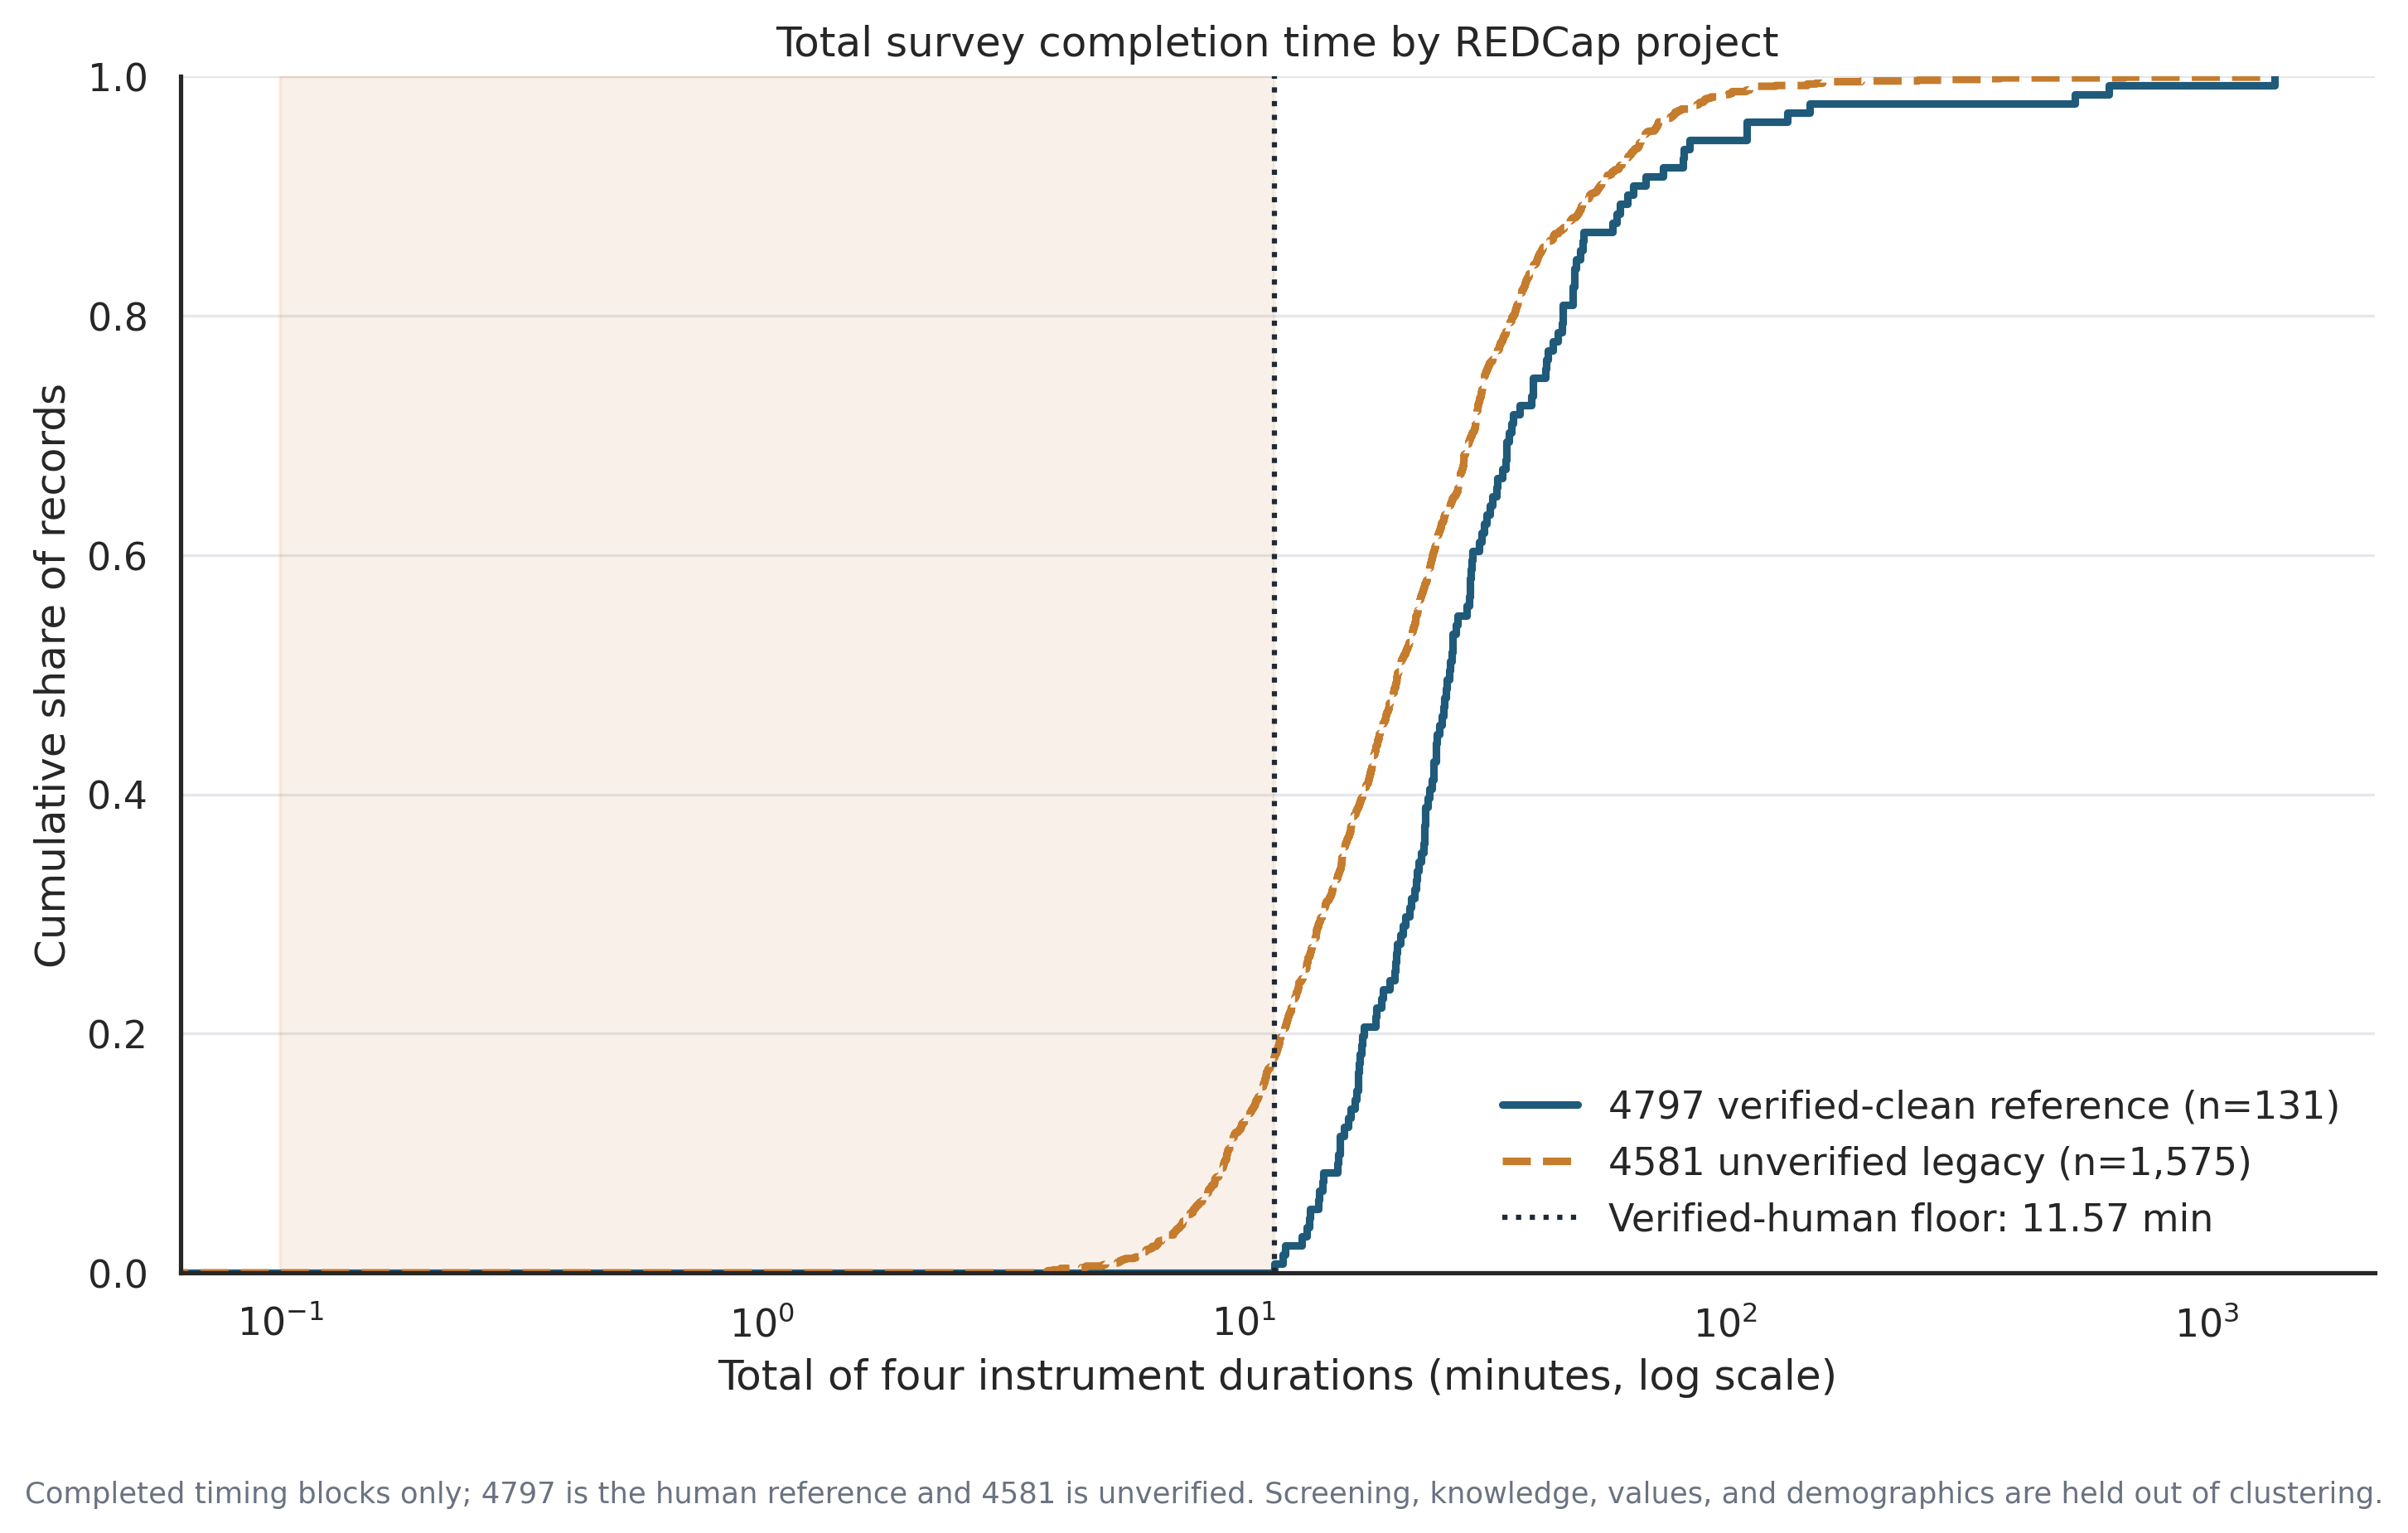

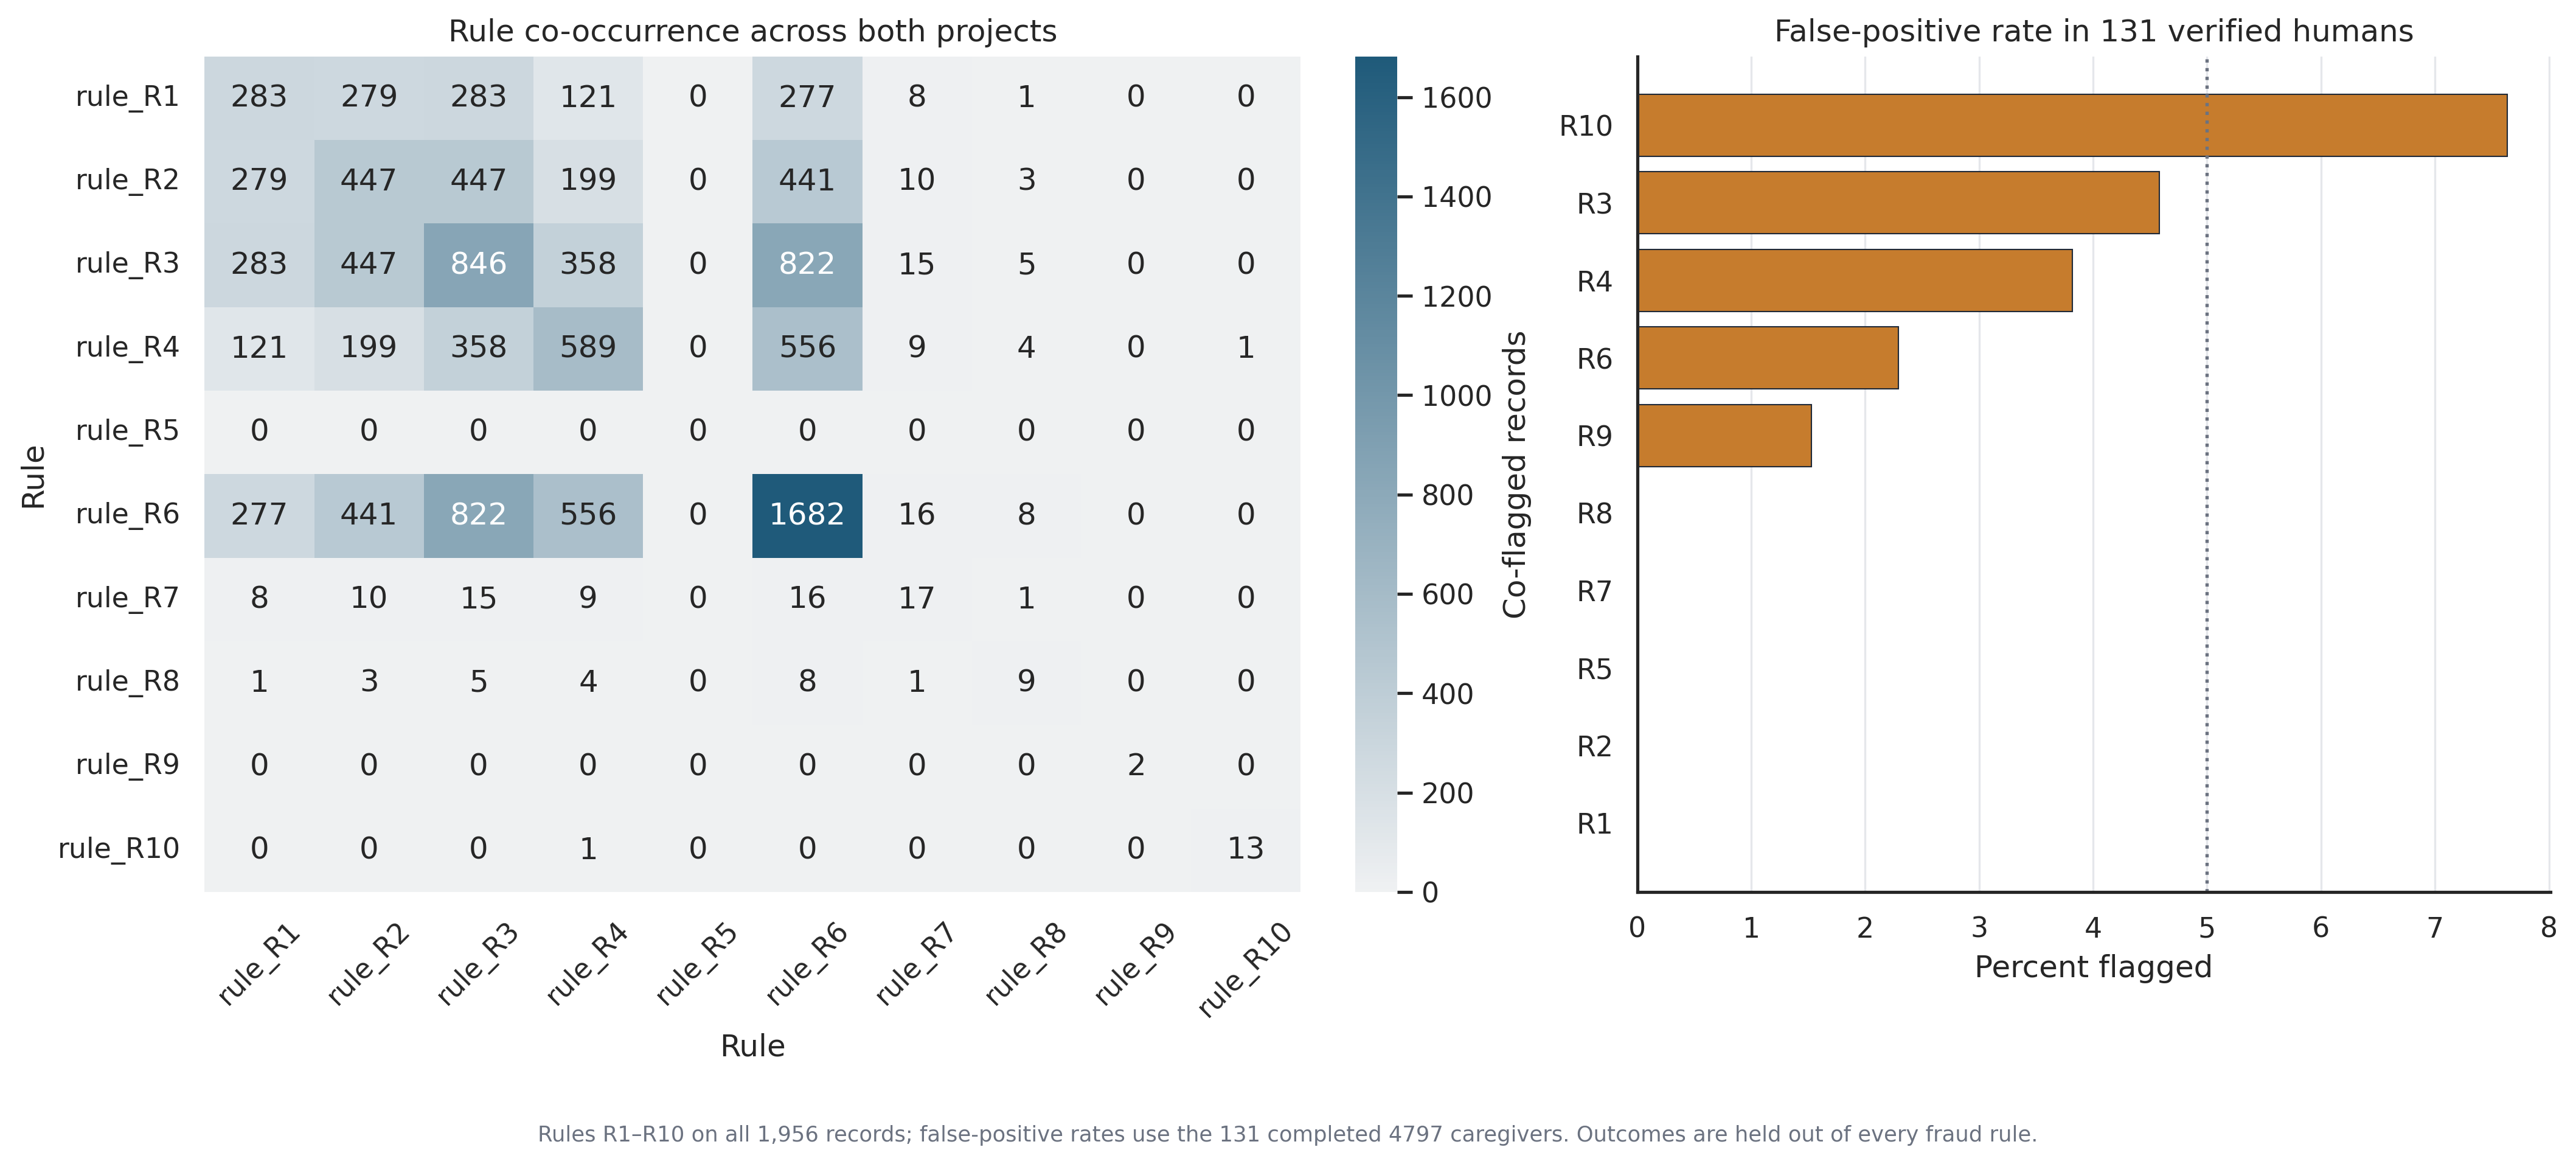

In [16]:
display(upgrade["rule_definitions"])
display(upgrade["false_positive"])
display(upgrade["tier_counts"])
display(upgrade["rule_counts"])
display(Image(filename=OUTPUT_DIR / "figure_7_timing_ecdf.png", width=950))
display(Image(filename=OUTPUT_DIR / "figure_9_rule_cooccurrence.png", width=1100))

### 17. Human-envelope distance and the identifiability limit

Isolation Forest, novelty-mode Local Outlier Factor, and robust Mahalanobis
distance are fit only on clean Tier-4 records. A gradient-boosted
positive-unlabeled/source classifier supplies a fourth, independent score.
Agreement—not nominal model accuracy—is the reportable validation quantity.

The Elkan–Noto-style fraction is retained only as a sensitivity estimate. The
clean and legacy projects differ in instrument and recruitment period, so the
data do not identify how much classifier separation is fraud versus legitimate
cohort drift.

,quantity,estimate,interval_low,interval_high,interpretation
0,Elkan–Noto-style nonhuman share in 4581,0.944134,0.938881,0.950205,Model-implied separation fraction only; recruitment-period and instrument drift violat...
1,Source-classifier AUC: 4797 versus 4581,0.980355,NaN,NaN,Separation includes legitimate cohort and instrument drift.
2,Negative-control AUC: random 4797 half A versus half B,0.524692,NaN,NaN,Should remain near 0.5; detects pipeline-induced separation.
3,Elkan–Noto labeling propensity c,0.622122,NaN,NaN,Mean out-of-fold labeled-positive score among clean Tier-4 records.


,method_a,method_b,cohen_kappa,overlap_n,jaccard_overlap
0,rule_high_suspicion_or_invalid,isolation,0.162425,313,0.268670
1,rule_high_suspicion_or_invalid,lof,0.028749,91,0.082803
2,rule_high_suspicion_or_invalid,mahalanobis,-0.021736,9,0.008357
3,rule_high_suspicion_or_invalid,pu_classifier,0.293336,1001,0.603012
4,isolation,lof,0.289592,105,0.224839
5,isolation,mahalanobis,0.091498,29,0.066059
6,isolation,pu_classifier,0.068082,400,0.243457
7,lof,mahalanobis,0.209090,21,0.132075
8,lof,pu_classifier,0.013021,127,0.078010
9,mahalanobis,pu_classifier,-0.009238,24,0.014751


,feature,permutation_auc_decrease,permutation_sd,mean_abs_shap
0,feat_open_text_n_filled,0.203884,0.012308,1.227325
1,feat_open_text_mean_len,0.031870,0.002442,0.441164
2,feat_time_val,0.028726,0.003263,0.794516
3,feat_time_demo,0.012811,0.001877,0.391358
4,feat_time_cv,0.003240,0.000816,0.160078
5,feat_n_missing_tfa,0.002474,0.000389,0.155467
6,feat_straightline_maxrun,0.001855,0.000724,0.132756
7,feat_sd_likert_7,0.001767,0.000384,0.172343
8,feat_time_fif,0.001395,0.000296,0.078467
9,feat_open_text_max_sim,0.001132,0.000399,0.066620


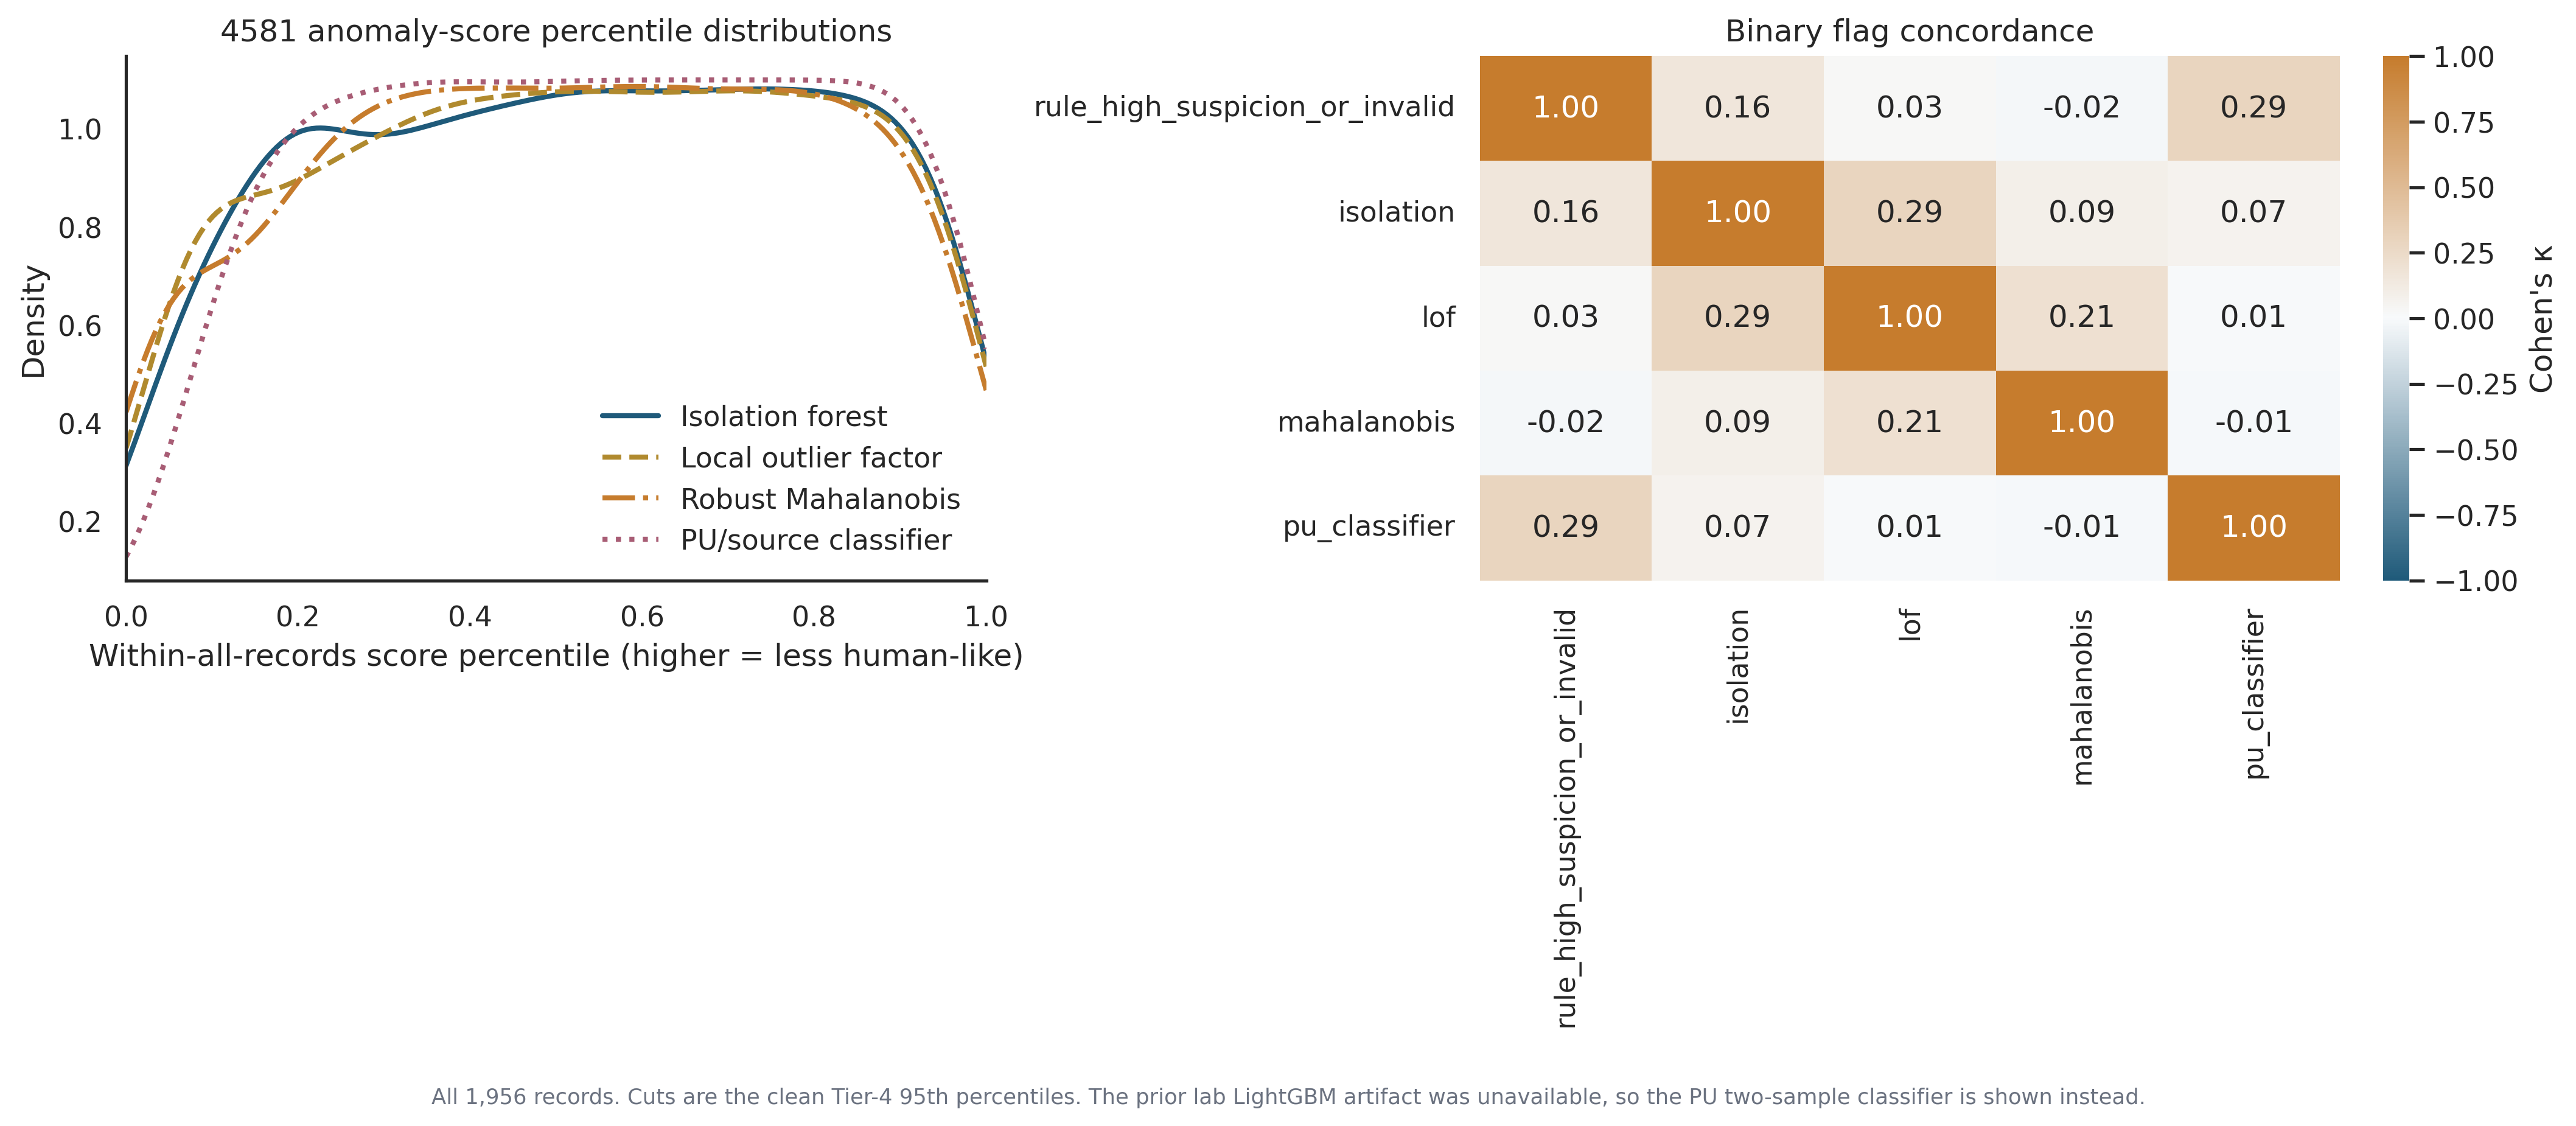

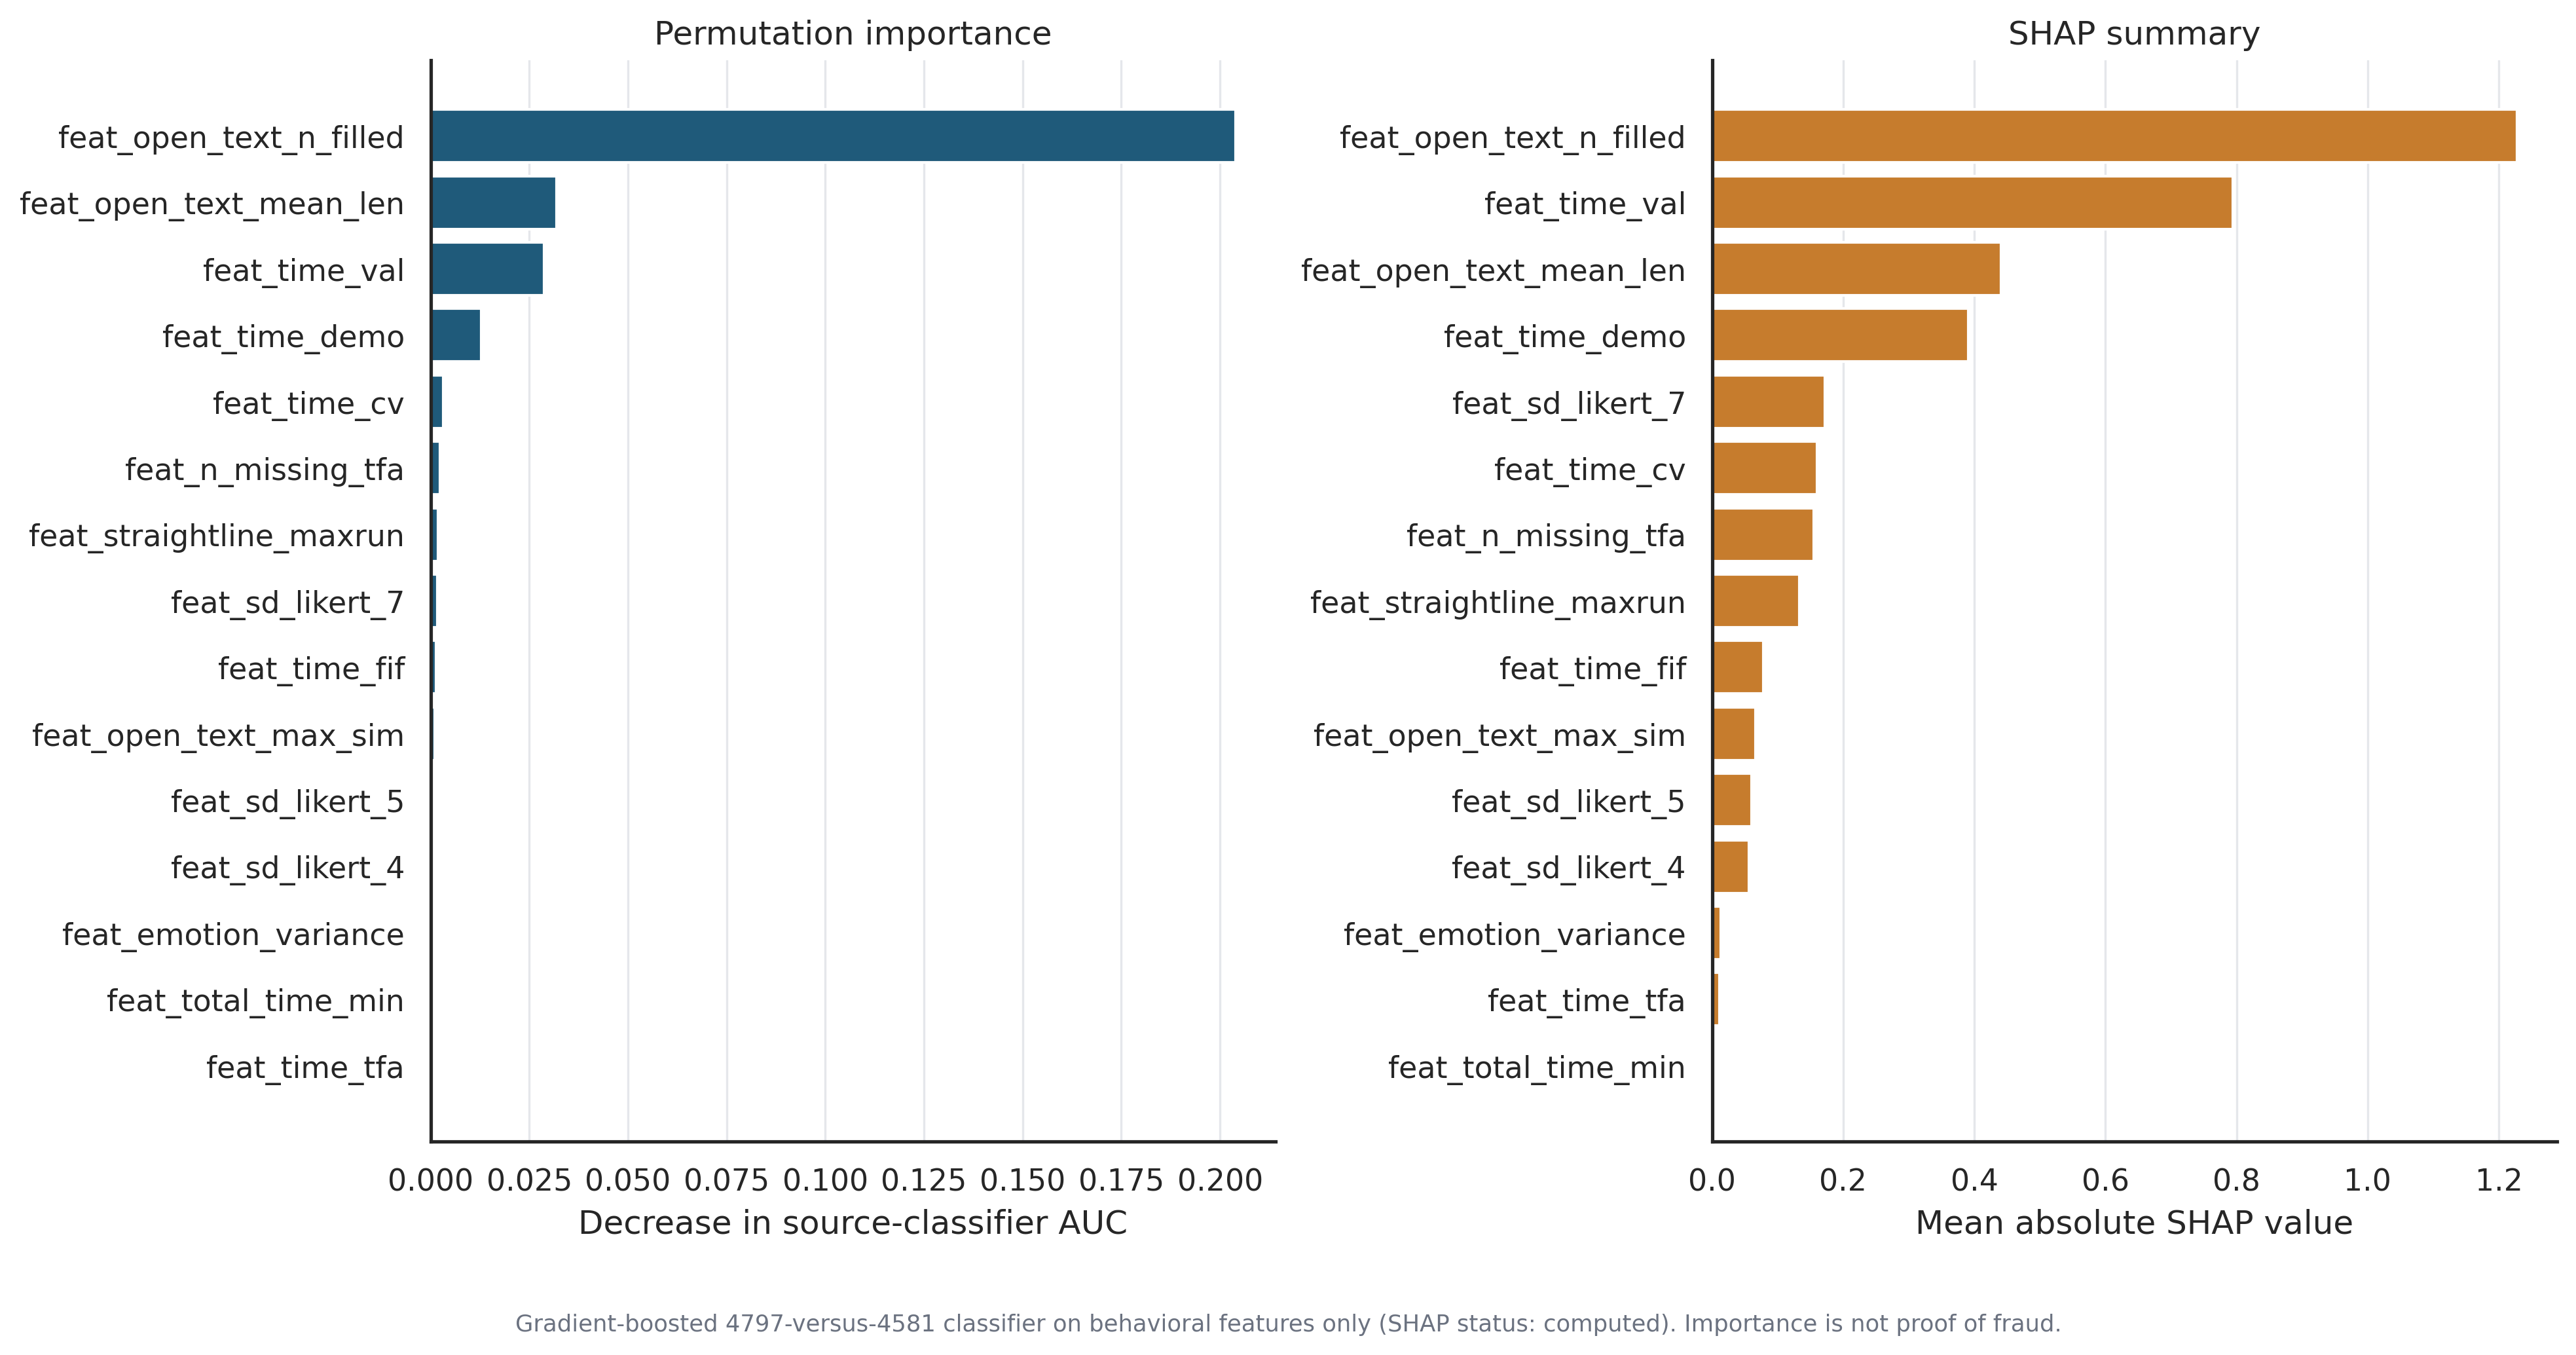

In [17]:
display(upgrade["contamination_summary"])
display(upgrade["detector_agreement"])
display(upgrade["detector_importance"].head(15))
display(Image(filename=OUTPUT_DIR / "figure_11_detector_scores_and_agreement.png", width=1100))
display(Image(filename=OUTPUT_DIR / "figure_11b_pu_feature_importance.png", width=1100))

### 18. The deliverable: conclusion sensitivity across trust definitions

Definitions 1–3 are the primary robustness test. Definition 4 is a pooled,
shared-item sensitivity only. Definition 5 is a lower-quality independent
replication attempt. The odds ratios use Firth penalization with
profile-likelihood confidence intervals.

,definition,input_n,clusterable_n,silhouette_k2,higher_n,conditional_n,screen_gap_pp,screen_gap_ci_low_pp,screen_gap_ci_high_pp,ari_vs_status_quo,cluster_firth_or,cluster_firth_ci_low,cluster_firth_ci_high
0,1. 4797 Tier 4 only,120,117,0.162,67,50,44.679,18.869,64.741,0.684,7.389,3.176,18.527
1,2. 4797 Tiers 3+4,132,128,0.181,84,44,48.523,23.547,67.171,0.969,11.089,4.509,30.790
2,3. 4797 status quo,135,131,0.180,84,47,42.340,17.473,61.999,1.000,8.091,3.466,20.796
3,4. 4797 Tiers 3+4 + 4581 Tier 4,203,177,0.238,138,39,45.688,22.484,62.372,0.524,8.270,3.565,21.568
4,5. 4581 Tier 4 replication,71,49,0.248,39,10,52.162,5.685,74.149,NaN,9.743,1.961,96.769


,definition,family,measure,higher_n,conditional_n,higher_estimate,conditional_estimate,effect,raw_p,fdr_p
0,1. 4797 Tier 4 only,knowledge,knowledge_binary_verified_7,63,47,3.825,3.617,0.127,0.423,0.423
1,1. 4797 Tier 4 only,knowledge,knowledge_graded_documented_5,64,48,17.078,16.812,0.094,0.281,0.423
2,1. 4797 Tier 4 only,values,conformity_val,67,50,4.896,4.840,0.052,0.777,0.861
3,1. 4797 Tier 4 only,values,tradition_val,67,50,3.687,3.560,0.068,0.638,0.861
4,1. 4797 Tier 4 only,values,benevolence_val,67,50,5.522,5.480,0.060,0.861,0.861
...,...,...,...,...,...,...,...,...,...,...
70,5. 4581 Tier 4 replication,values,power_val,39,10,3.385,3.300,0.062,0.859,0.954
71,5. 4581 Tier 4 replication,values,security_val,39,10,5.051,4.000,0.902,0.041,0.413
72,5. 4581 Tier 4 replication,demographics,caregiver_age,0,0,NaN,NaN,NaN,NaN,NaN
73,5. 4581 Tier 4 replication,demographics,household_size,36,10,4.000,4.000,0.153,1.000,1.000


,excluded_no_records_added_to_higher,excluded_no_records_added_to_conditional,screen_gap_pp
0,0,4,44.51
1,1,3,43.14
2,2,2,41.76
3,3,1,40.39
4,4,0,39.01


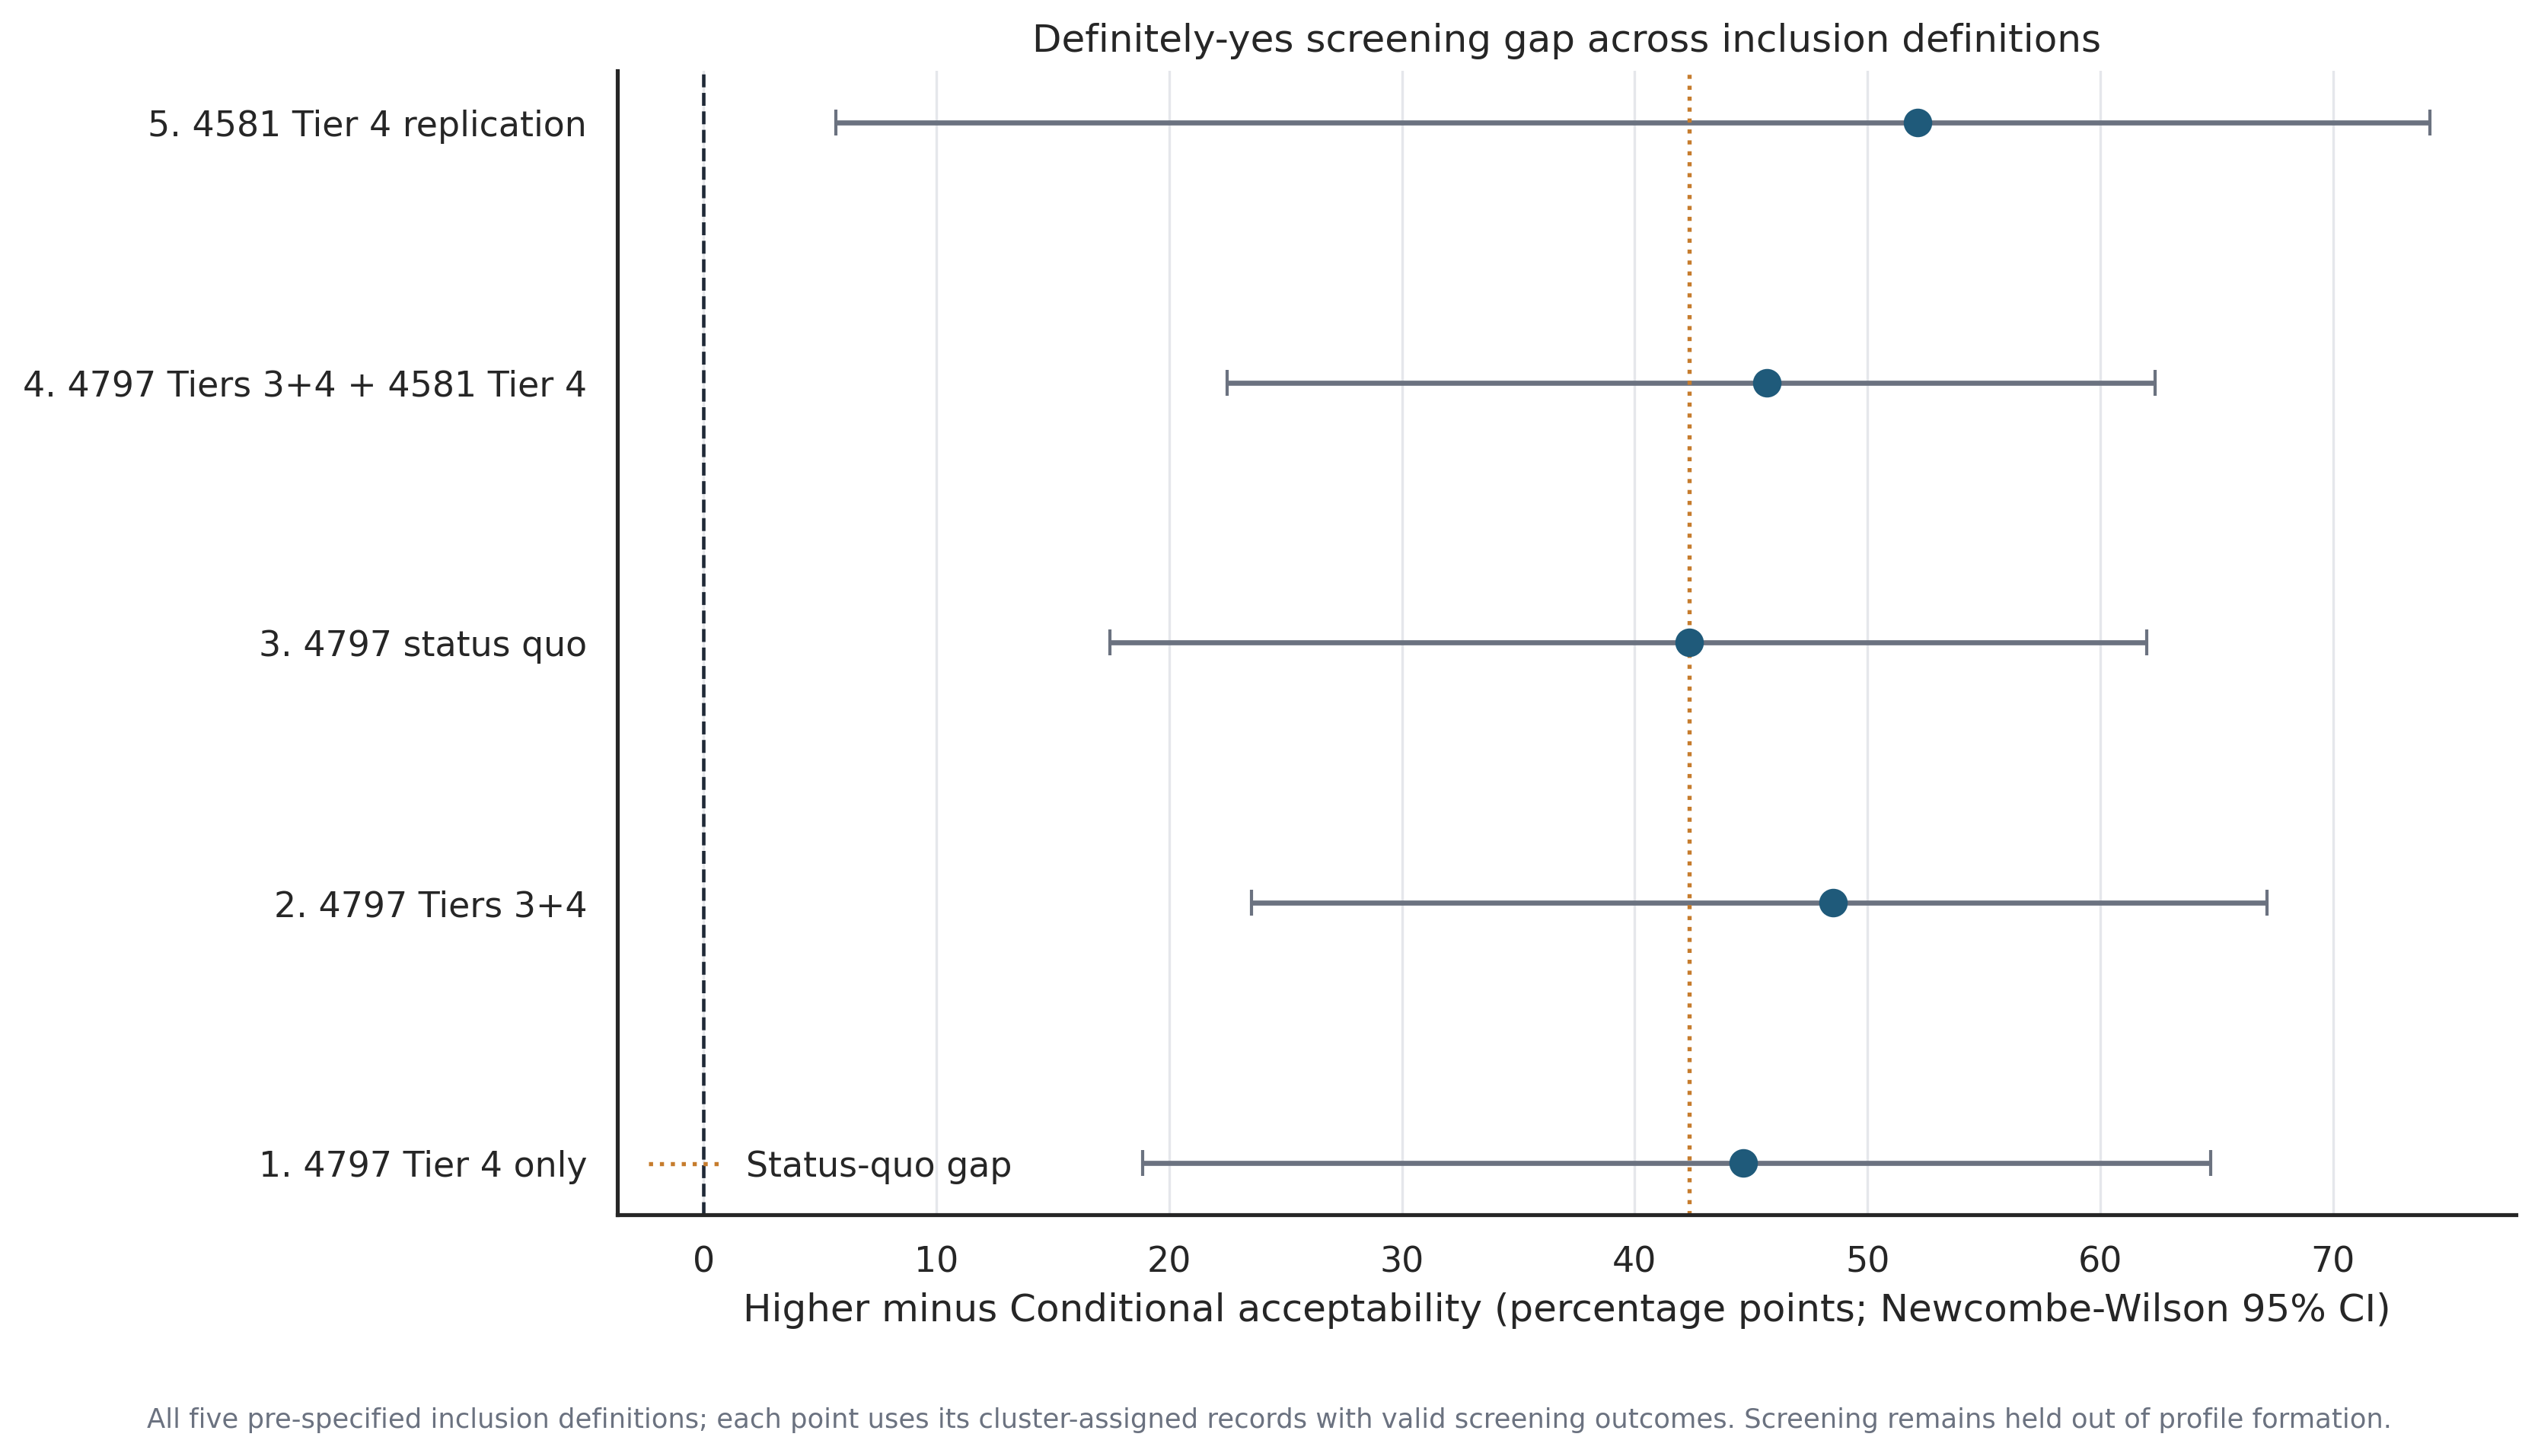

In [18]:
display(upgrade["sensitivity"].round(3))
display(upgrade["characterization"].round(3))
display(upgrade["tipping"].round(2))
display(Image(filename=OUTPUT_DIR / "figure_20_tier_sensitivity.png", width=1050))

### 19. Probabilistic profiles, consensus, and hardened inference

K-means stays primary for continuity. Gaussian mixtures, a parametric bootstrap
likelihood-ratio test, classification entropy, BCH-corrected distal outcomes,
and a 1,000-repeat consensus matrix are convergent or divergent evidence—not a
replacement label. BIC preferring k=3 is a substantive warning against treating
the two profiles as fixed natural types.

,k,covariance_type,aic,bic,converged,entropy_separation,mean_max_posterior,p10_max_posterior
0,3,diagonal,1519.609,1697.872,True,0.997,0.999,1.000
1,5,diagonal,1729.057,2028.077,True,0.927,0.956,0.859
2,4,diagonal,1792.774,2031.415,True,0.998,1.000,1.000
3,6,diagonal,1741.224,2100.624,True,0.937,0.957,0.886
4,3,full,1611.646,2178.060,True,1.000,1.000,1.000
5,6,full,1048.408,2184.111,True,1.000,1.000,1.000
6,5,full,1325.572,2271.512,True,1.000,1.000,1.000
7,2,diagonal,2211.790,2329.673,True,0.999,1.000,1.000
8,4,full,1721.842,2478.019,True,0.999,1.000,1.000
9,2,full,2129.892,2506.542,True,1.000,1.000,1.000


,comparison,covariance_type,observed_lr,bootstrap_repeats,bootstrap_p,best_overall_bic_k,best_overall_bic_covariance
0,GMM k=2 versus k=1,diagonal,1587.8286,100,0.0099,3,diagonal


,profile,modal_n,mean_max_posterior,p10_max_posterior,below_0_70_n,below_0_70_pct
0,Higher acceptability,110,1.0,1.0,0,0.0
1,Conditional acceptability,21,1.0,1.0,0,0.0
2,Overall,131,1.0,1.0,0,0.0


,profile,valid_n_unweighted,bch_weight_sum,bch_definitely_yes_pct,modal_definitely_yes_pct
0,Higher acceptability,127,108.00,58.33,58.33
1,Conditional acceptability,127,18.93,31.45,31.58


,definition,model,term,n,mle_or,mle_ci_low,mle_ci_high,mle_p,mle_converged,firth_or,firth_profile_ci_low,firth_profile_ci_high,firth_converged
0,1. 4797 Tier 4 only,additive,higher_acceptability,113,7.932100e+00,3.2324,19.4651,0.0000,True,7.3894,3.1762,18.5268,True
1,1. 4797 Tier 4 only,additive,asd_child_at_home,113,3.682200e+00,1.5033,9.0192,0.0043,True,3.5071,1.4985,8.7464,True
2,1. 4797 Tier 4 only,interaction,higher_acceptability,113,6.461500e+00,1.9472,21.4422,0.0023,True,5.9360,1.9534,20.4883,False
3,1. 4797 Tier 4 only,interaction,asd_child_at_home,113,2.907700e+00,0.7975,10.6017,0.1059,True,2.7508,0.8067,10.1819,False
4,1. 4797 Tier 4 only,interaction,cluster_x_asd,113,1.564800e+00,0.2573,9.5157,0.6269,True,1.5162,0.2660,8.9363,False
5,2. 4797 Tiers 3+4,additive,higher_acceptability,124,1.219930e+01,4.5714,32.5555,0.0000,True,11.0894,4.5092,30.7895,True
6,2. 4797 Tiers 3+4,additive,asd_child_at_home,124,4.481900e+00,1.7641,11.3868,0.0016,True,4.2081,1.7692,11.0666,True
7,2. 4797 Tiers 3+4,interaction,higher_acceptability,124,8.666700e+00,2.2384,33.5561,0.0018,True,7.5714,2.3158,31.8469,True
8,2. 4797 Tiers 3+4,interaction,asd_child_at_home,124,2.955600e+00,0.6513,13.4120,0.1602,True,2.6959,0.6749,12.7079,True
9,2. 4797 Tiers 3+4,interaction,cluster_x_asd,124,1.916200e+00,0.2784,13.1910,0.5088,True,1.9107,0.2910,12.1500,True


,smaller_profile_n,larger_profile_n,two_sided_alpha,power,pooled_reference_rate,approx_min_detectable_difference_pp,observed_difference_pp,interpretation
0,47,80,0.05,0.8,0.543,25.648,42.34,"A non-significant difference smaller than this threshold would be imprecise evidence, ..."


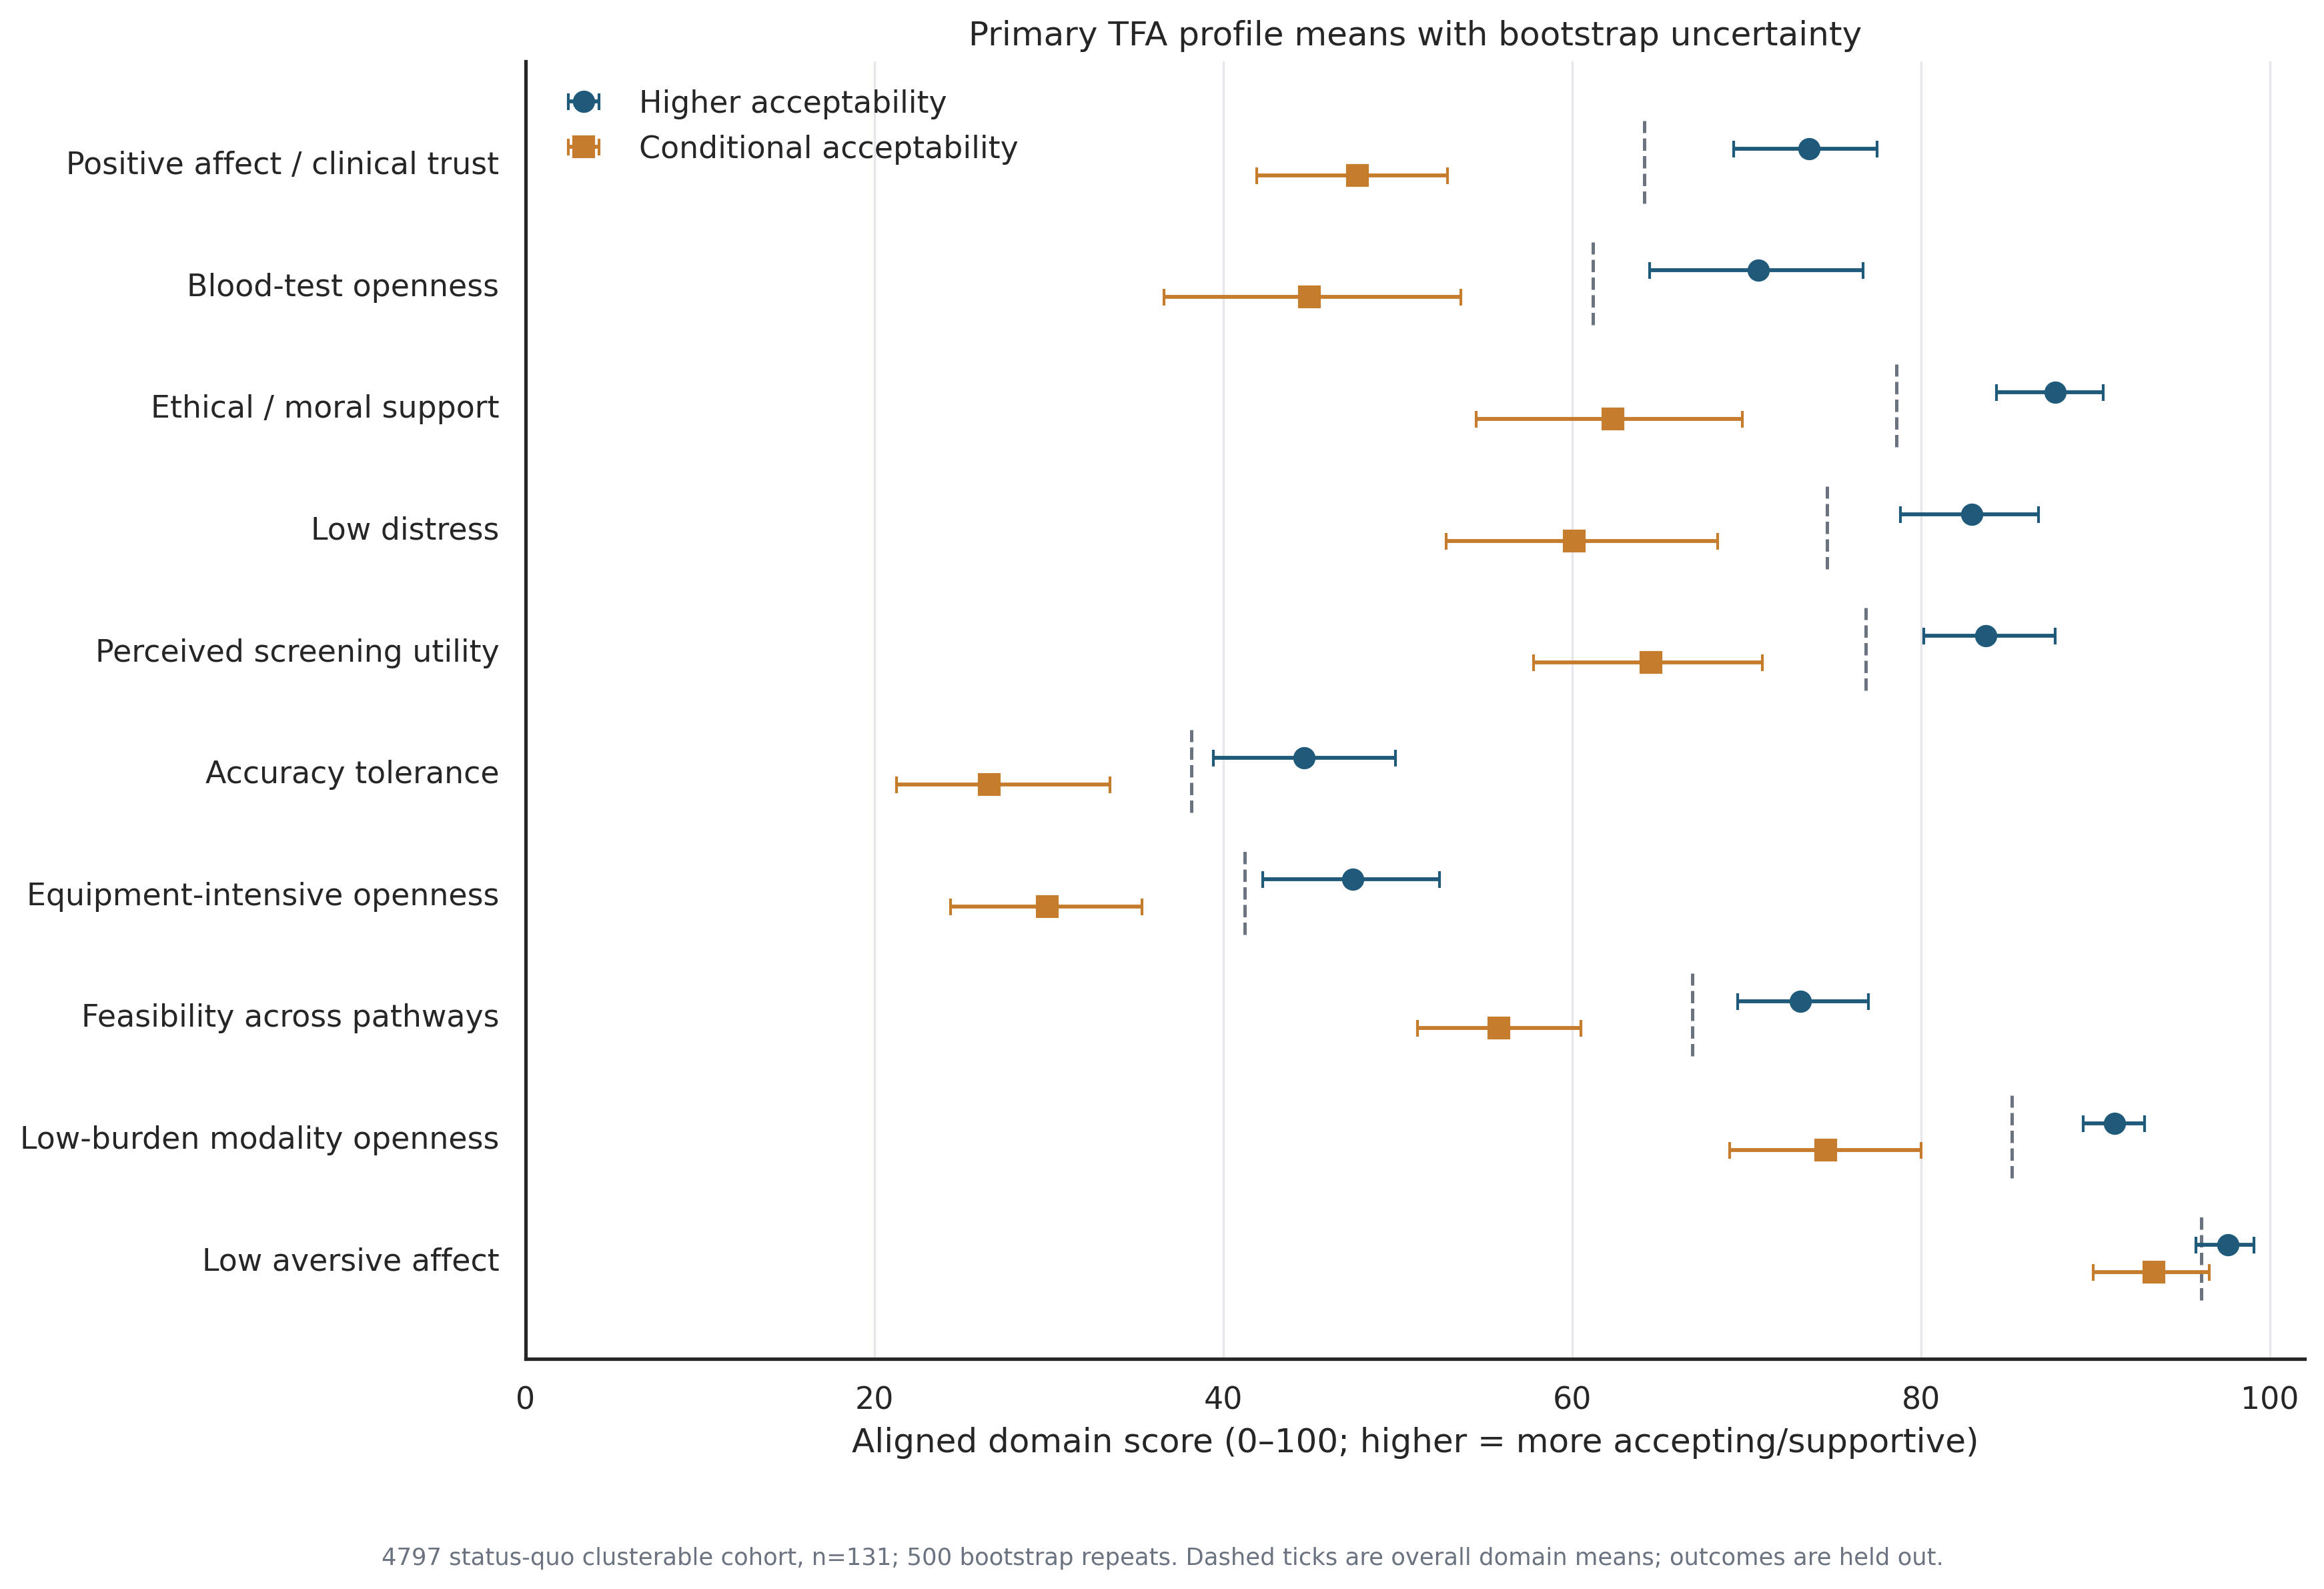

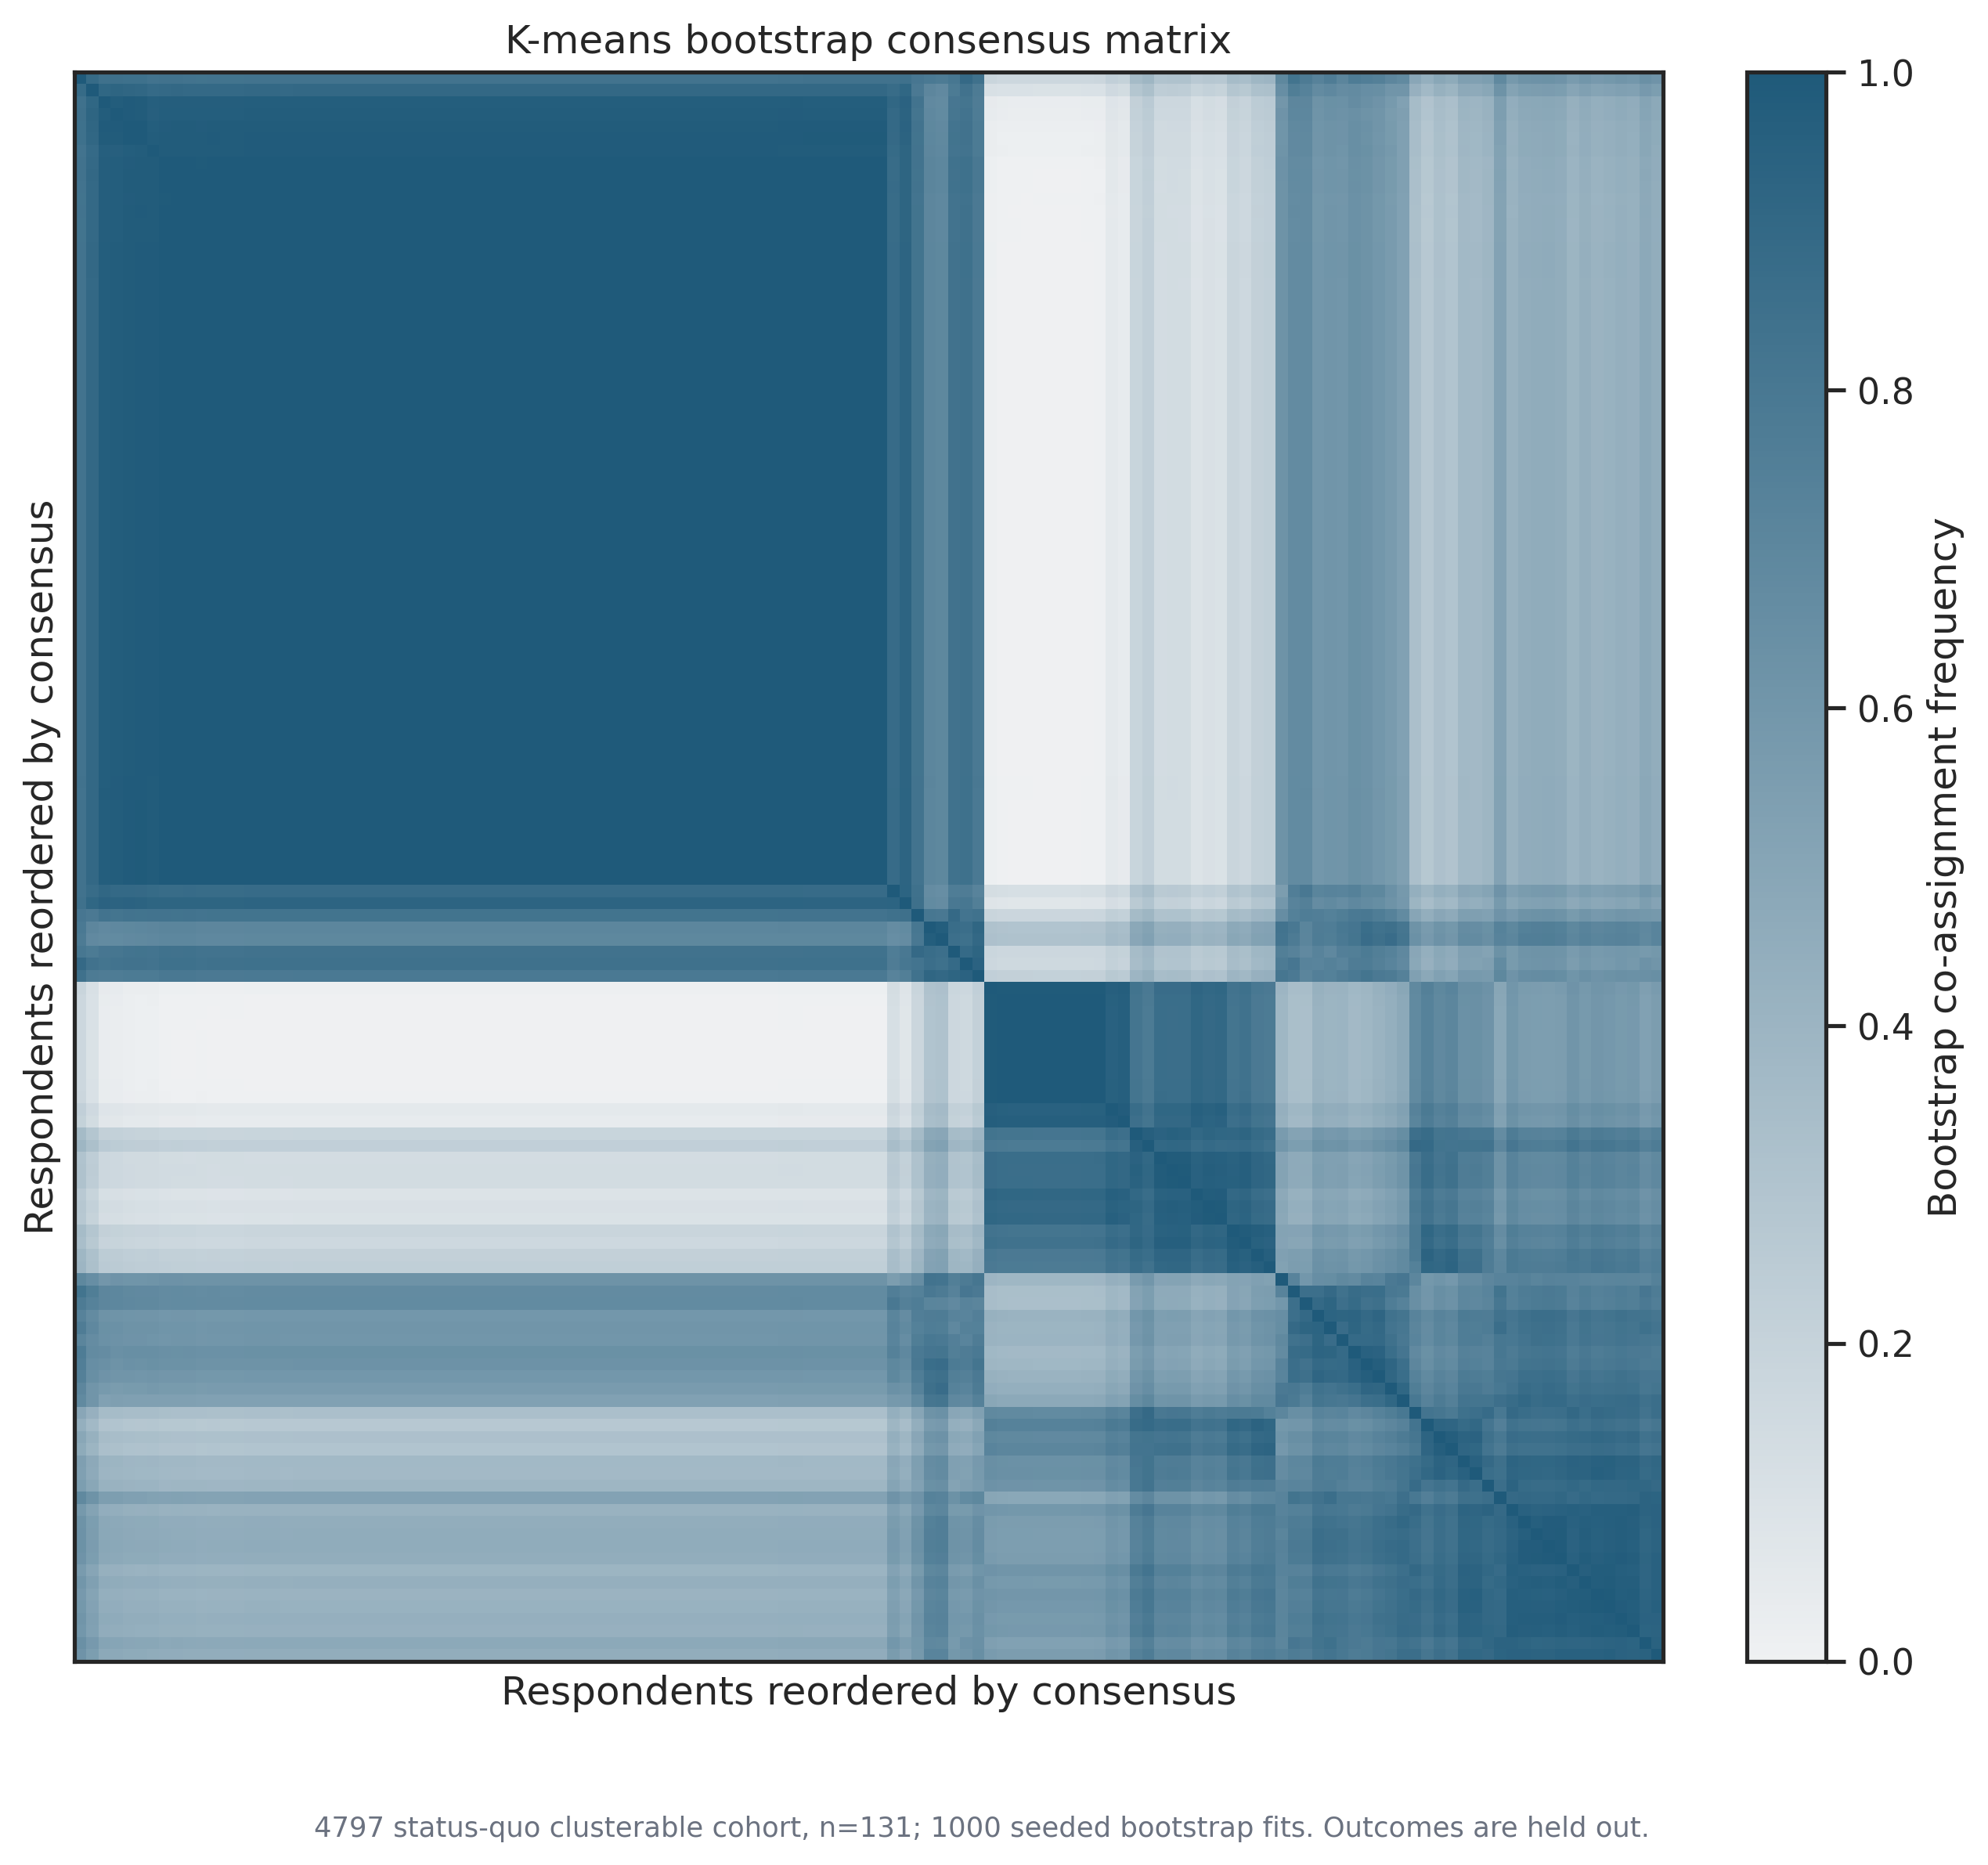

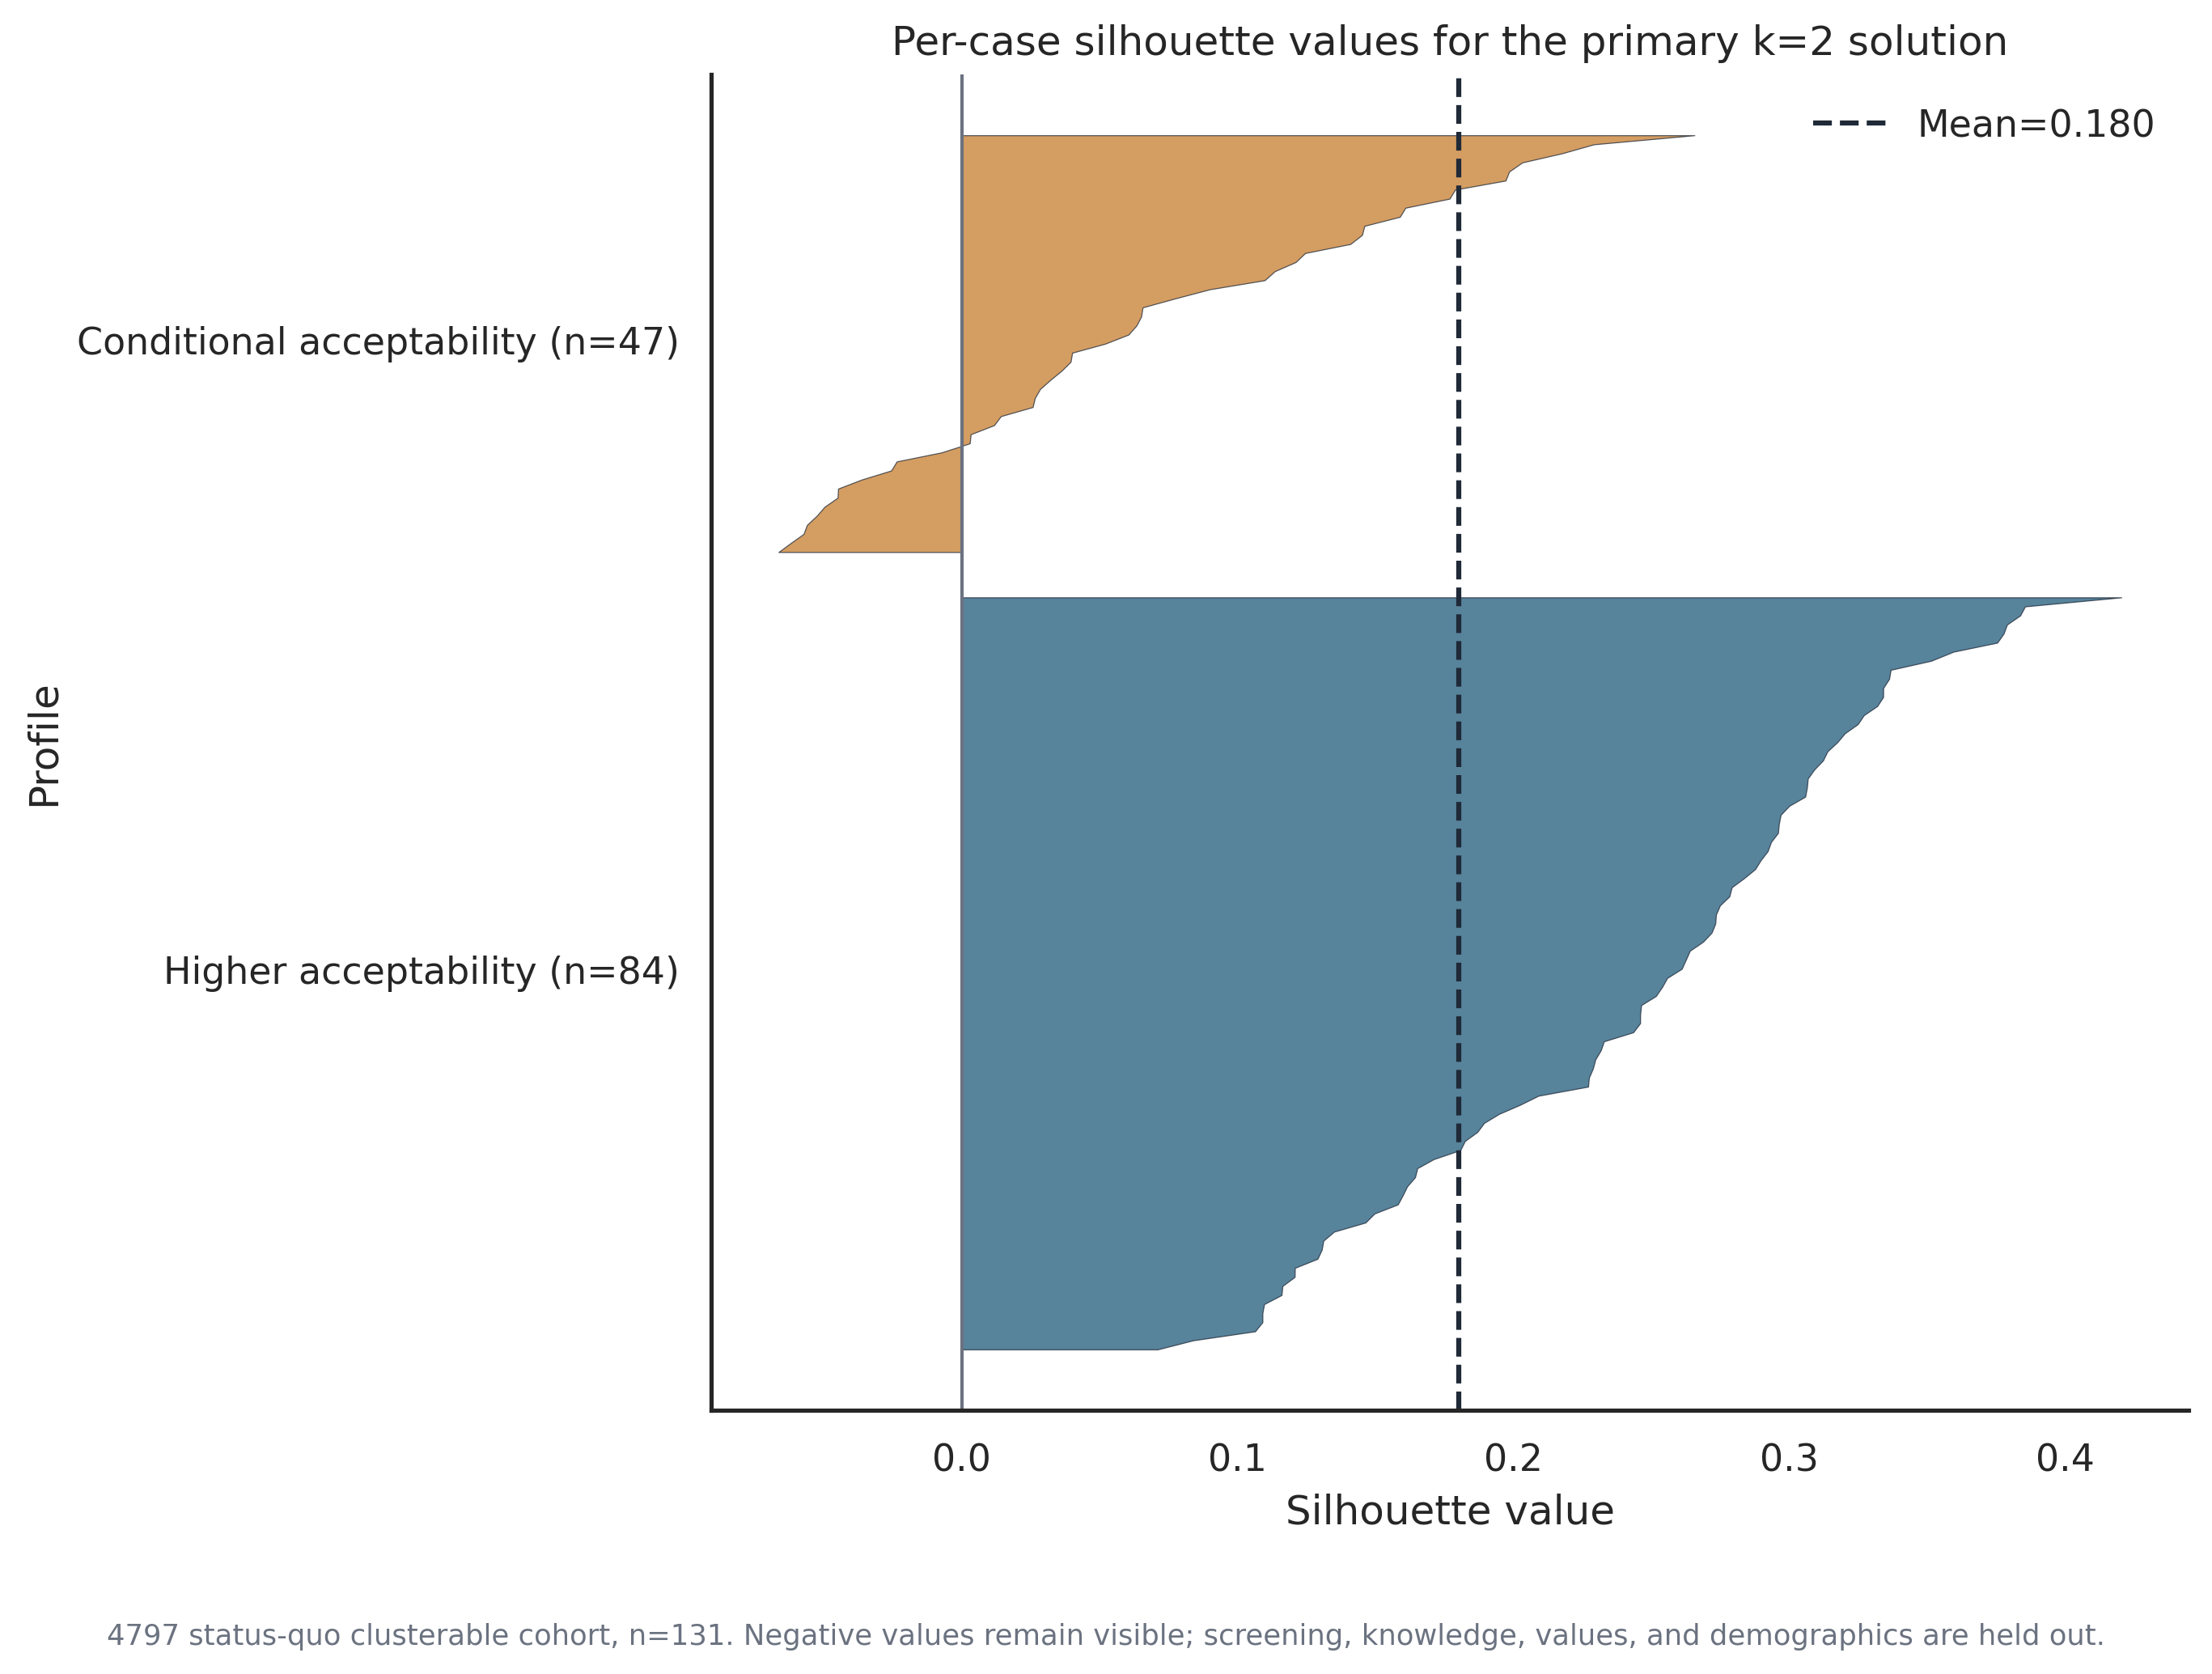

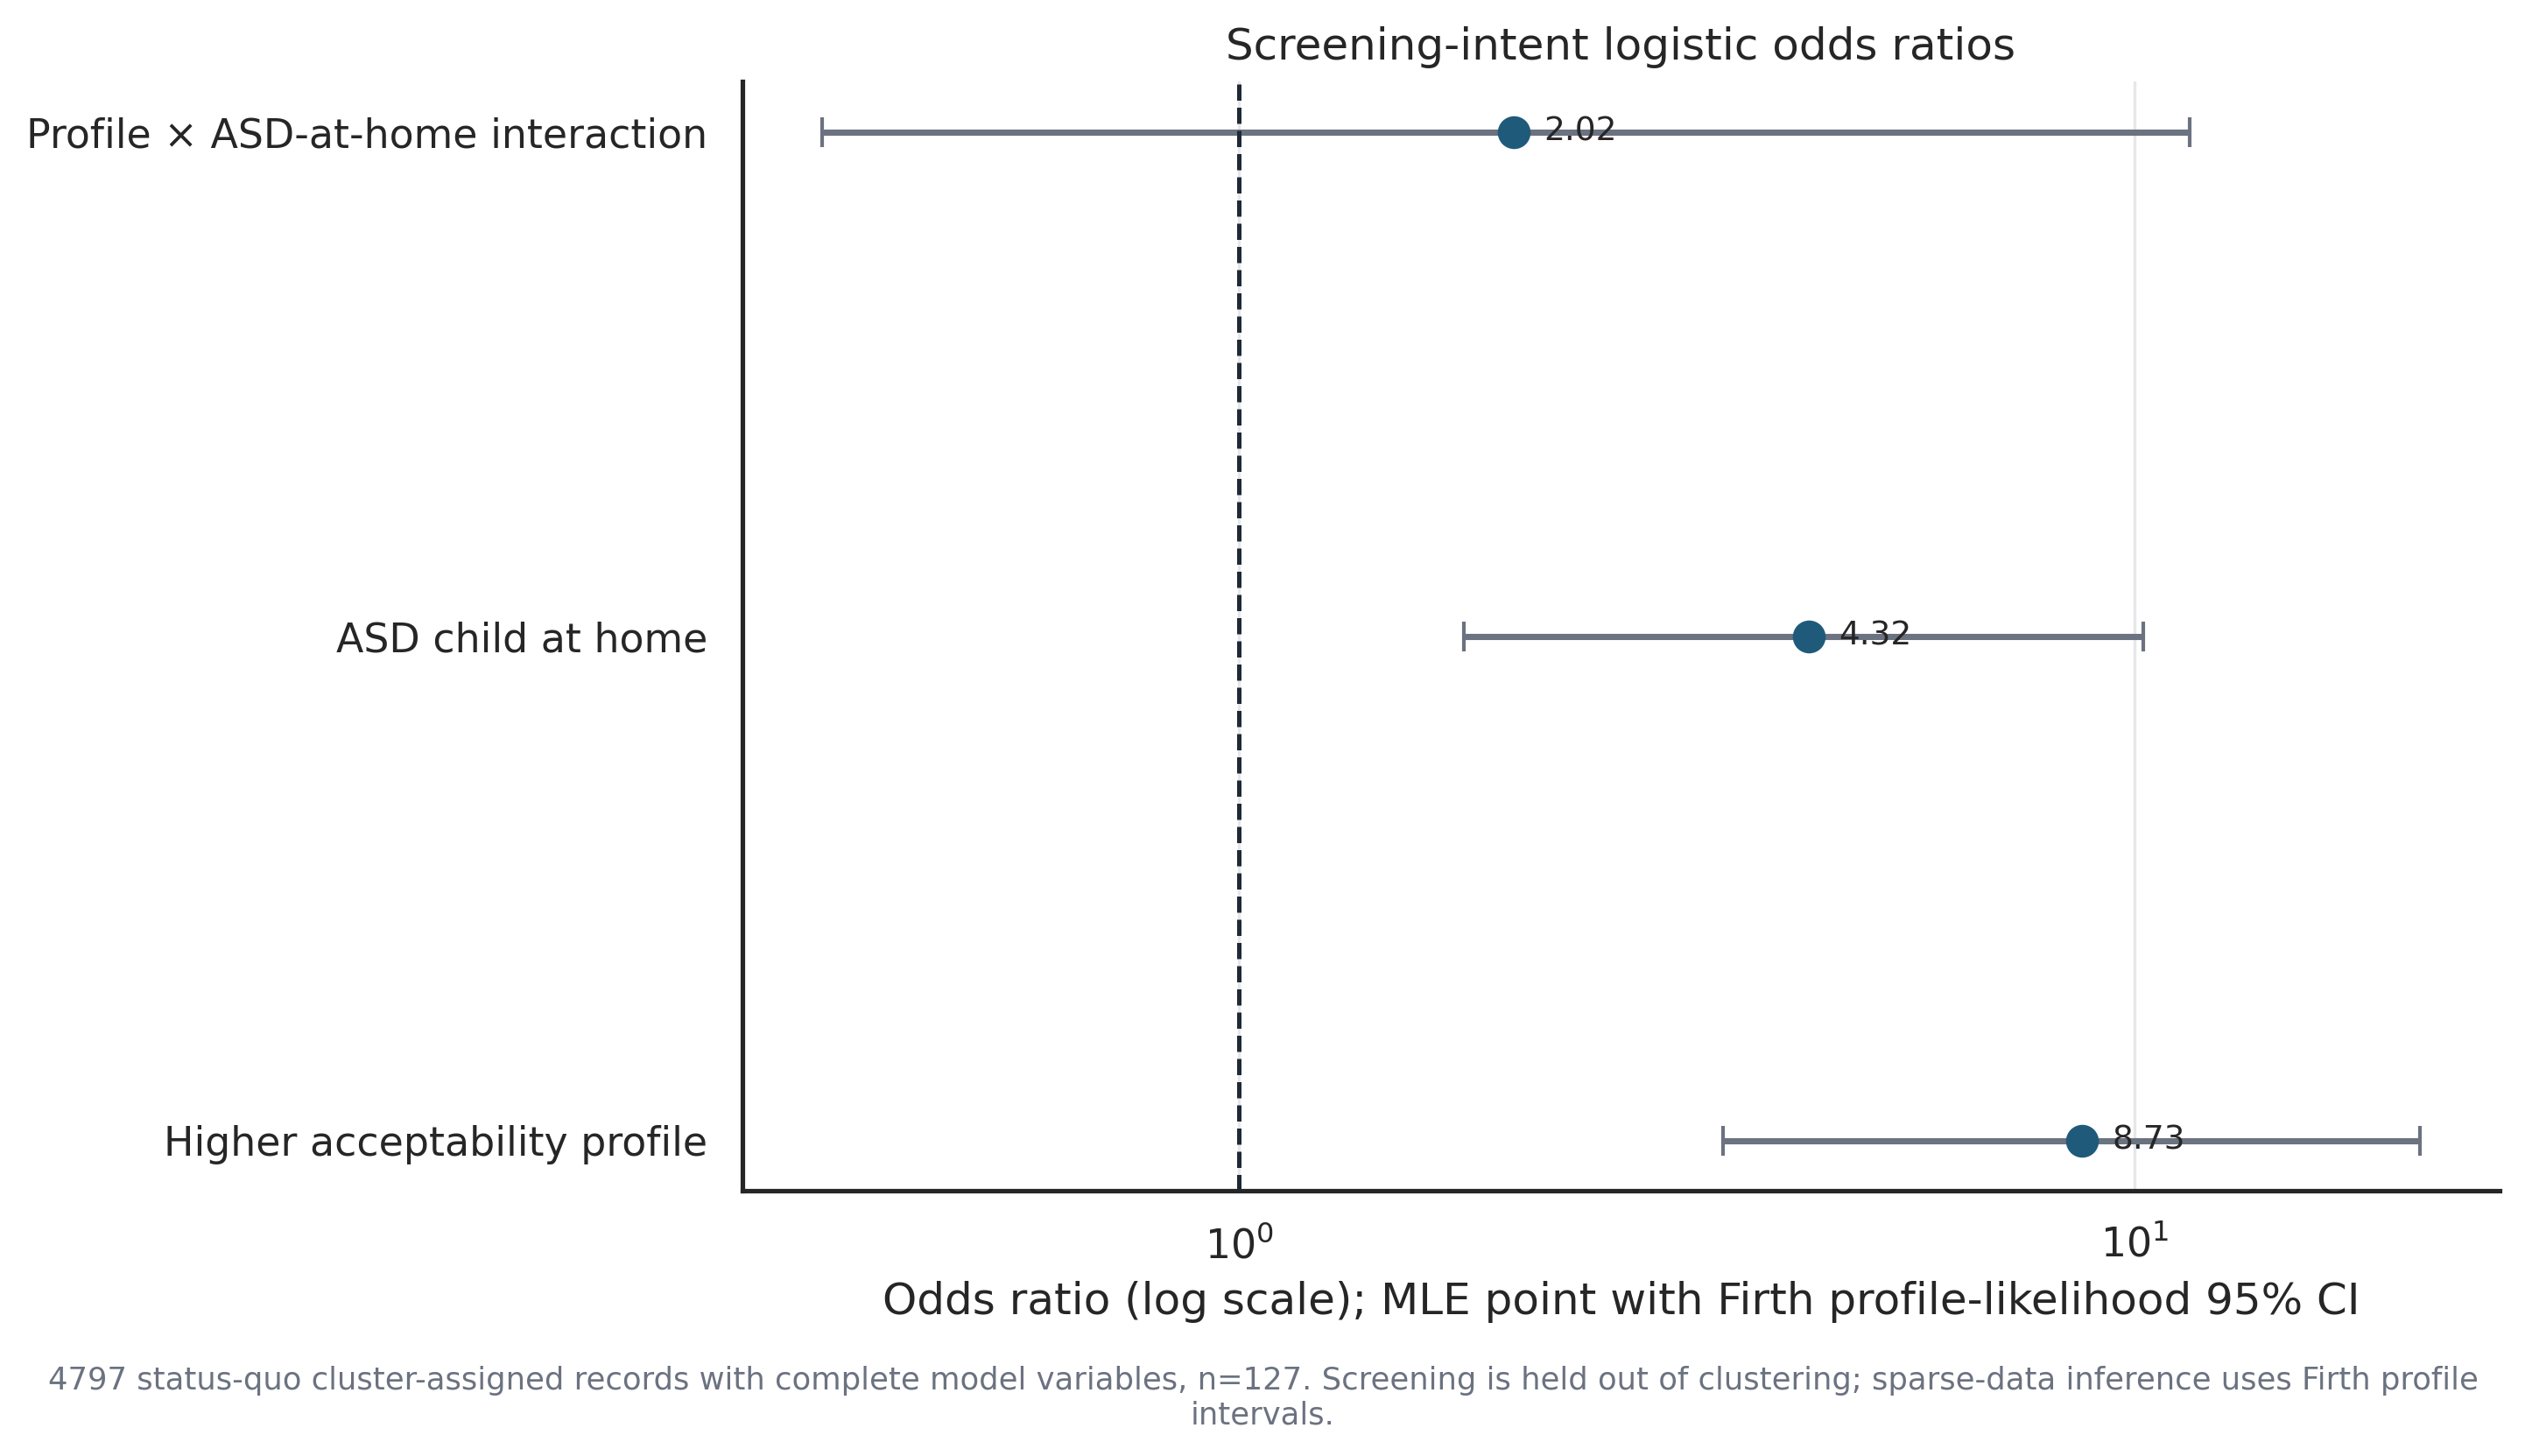

In [19]:
display(upgrade["gmm_grid"].head(12).round(3))
display(upgrade["blrt"].round(4))
display(upgrade["latent_quality"].round(3))
display(upgrade["bch_table"].round(2))
display(upgrade["logistic_table"].round(4))
display(upgrade["precision"].round(3))
display(Image(filename=OUTPUT_DIR / "figure_2_primary_cluster_profiles.png", width=1050))
display(Image(filename=OUTPUT_DIR / "figure_15_consensus_matrix.png", width=850))
display(Image(filename=OUTPUT_DIR / "figure_16_case_silhouette.png", width=900))
display(Image(filename=OUTPUT_DIR / "figure_18_logistic_forest.png", width=950))

## Takeaways

The two-profile screening association is robust to the pre-specified trust
screen inside the verified-clean 4797 cohort. The strict Tier-4 estimate is
similar to the status quo and remains large and statistically compatible with
a meaningful association. The four cluster-excluded, screening-valid records
cannot erase the result under any allocation in the tipping-point analysis.

The profiles are best described as an exploratory acceptability gradient.
Silhouette remains modest, individual negative-silhouette cases are visible,
and the BIC-optimal Gaussian mixture has three components. These facts argue
against diagnostic or permanent “caregiver type” language.

Project 4581 should not be pooled into the primary manuscript estimate. Its tiny
Tier-4 replication is directionally consistent, but the wide interval and
instrument mismatch make it supportive at most. The model-implied 94.4%
separation fraction must not be quoted as a bot rate.

### Limitations and next steps

- Residual fraud can remain after deterministic screening; conversely, some
  flagged records may be genuine caregivers.
- A 131-person human reference envelope may not generalize to other recruitment
  periods or populations.
- Project-level instrument and recruitment differences confound every
  4797-versus-4581 classifier.
- The prior LightGBM model and its 142 labeled cases were unavailable in the
  scoped project; recover them and document how the 111 “alleged bot” labels were
  assigned before supervised reuse.
- Confirm the original 135-record selection rule and the first-chosen knowledge
  scoring method with the research team.
- Rotate both REDCap tokens because they previously appeared in plaintext, then
  update only the git-ignored repository `.env`.

### Validation assessment

**Share with caveats.** The primary association and exact regression targets are
reproduced, trust-tier sensitivity is stable, and outputs are privacy-scoped.
The latent taxonomy and the 4581 contamination fraction remain uncertain, so
manuscript language must preserve those caveats.